In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Data_Functions import Get_Data, Explore_Data, Get_Class_Distribution, Get_MI_Matrices, Extract_PassengerId_Info
from Visualization_Functions import Plot_Distributions, Plot_Nulls_Heatmap, Plot_Num_Distributions, Plot_Stats, Gridplot_Hists, Plot_MI_Heatmap, Plot_MI, PairGrid_kde
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from scipy import stats
# import importlib

In [2]:
filename = 'Data/train.csv'
df = Get_Data(filename)
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [3]:
Explore_Data(df)

shape:
 (8693, 14) 

column names:
 Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 1

In [4]:
null_rows = len(df[df.isnull().any(axis = 1)])
null_rows, null_rows*100/len(df)

(2087, 24.007822385827676)

## Initial Observations:
* Target feature is <b>Transported</b> with binary values
* All features have a comparable number of missing values (about 2% each)
* 24% of the entries have at least one missing value. That's a lot of data to lose if we are to simply delete all rows with null values
* Categorical features are: PassengerId, HomePlanet, CryoSleep, Cabin, Destination, VIP, Name
* Numerical features are: Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck

In [5]:
target = 'Transported'
df_classes, Class_Distribution, Class_Distribution_Norm = Get_Class_Distribution(df, target)
Class_Distribution_Norm

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

In [6]:
df_null = df[df.isnull().any(axis = 1)].copy()
df_null_classes, df_null_Class_Distribution, df_null_Class_Distribution_Norm = Get_Class_Distribution(df_null, target)
df_null_Class_Distribution_Norm

Transported
True     0.503594
False    0.496406
Name: proportion, dtype: float64

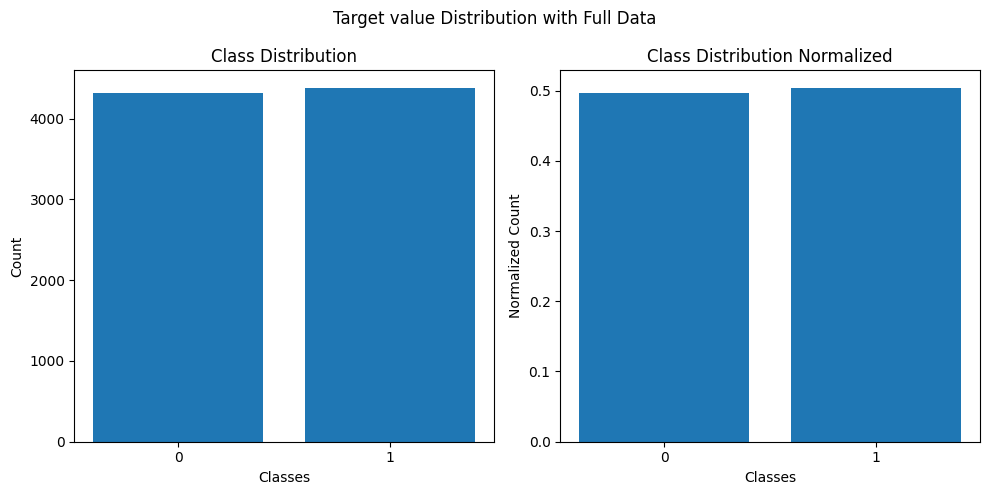

In [7]:
Plot_Distributions(Class_Distribution, Class_Distribution_Norm, 'Target value Distribution with Full Data')

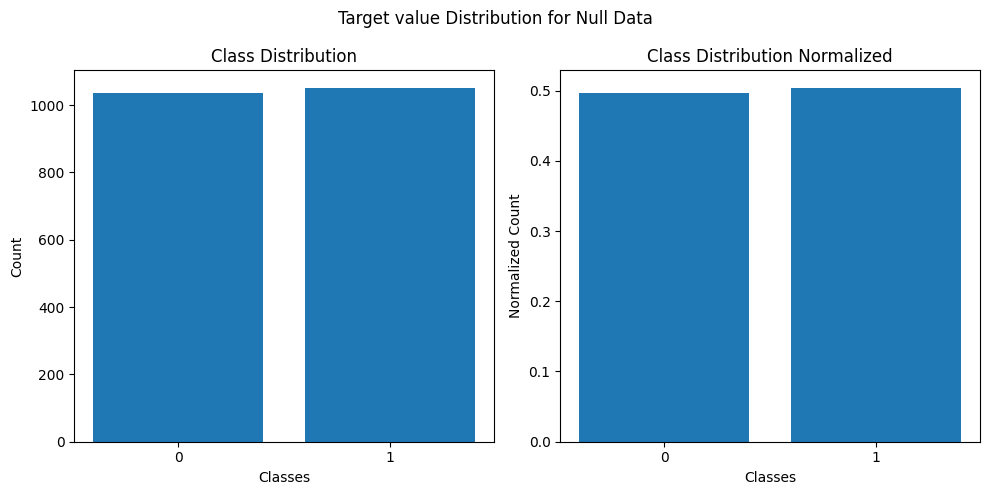

In [8]:
Plot_Distributions(df_null_Class_Distribution, df_null_Class_Distribution_Norm, 'Target value Distribution for Null Data')

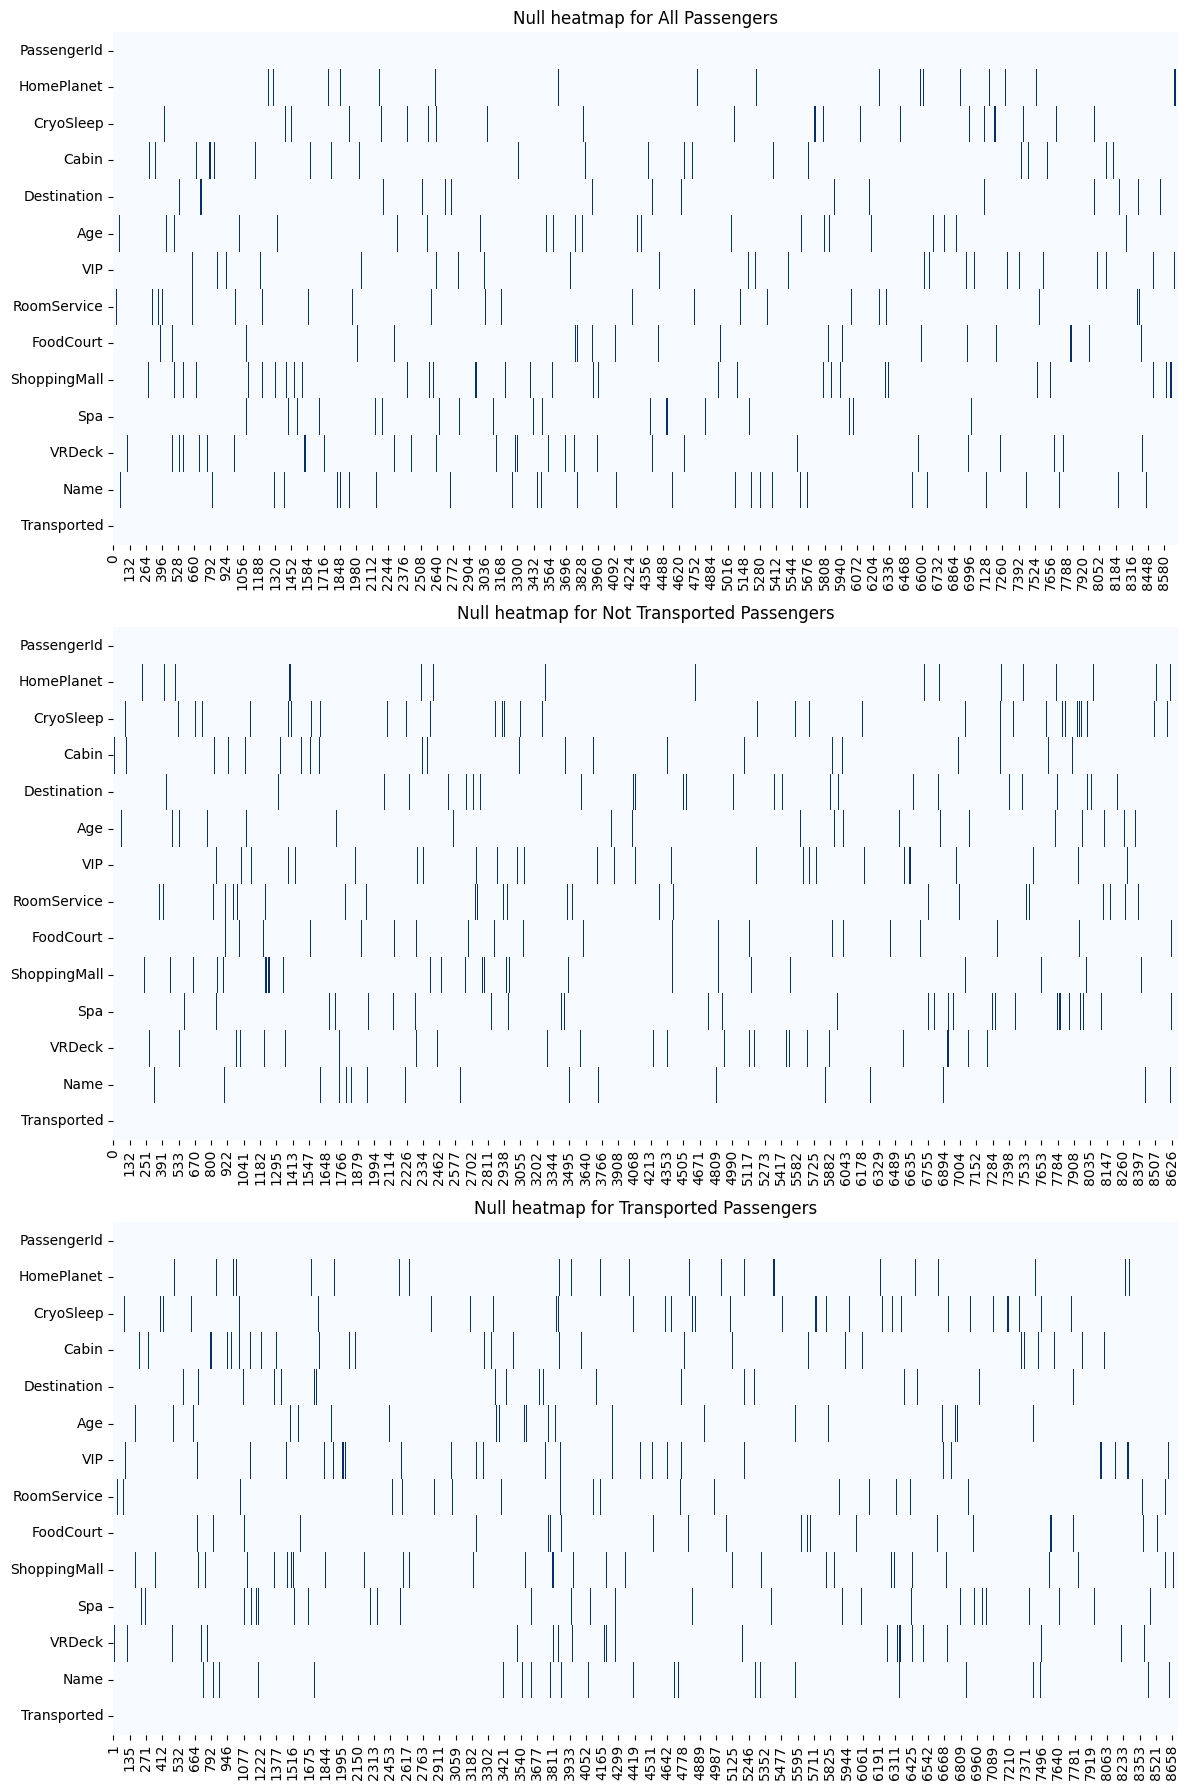

In [9]:
Plot_Nulls_Heatmap(df)

In [10]:
null_counts = df.groupby('Transported')[df.columns.drop(['PassengerId', 'Transported'])].apply(lambda f: f.isnull().sum())
null_counts

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
Transported,,,,,,,,,,,,
False,98,111,99,90,89,99,98,84,94,92,90,99
True,103,106,100,92,90,104,83,99,114,91,98,101


In [11]:
transported_nulls_ratio = null_counts.loc[True]/null_counts.sum()
transported_nulls_ratio

HomePlanet      0.512438
CryoSleep       0.488479
Cabin           0.502513
Destination     0.505495
Age             0.502793
VIP             0.512315
RoomService     0.458564
FoodCourt       0.540984
ShoppingMall    0.548077
Spa             0.497268
VRDeck          0.521277
Name            0.505000
dtype: float64

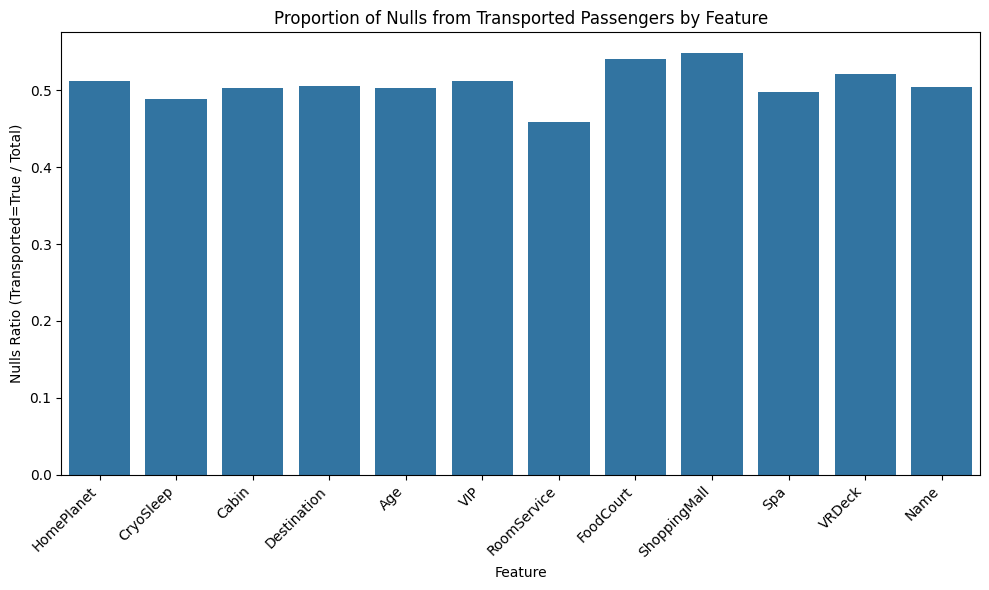

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x = transported_nulls_ratio.index, y = transported_nulls_ratio.values, ax = ax)
ax.set(xlabel = 'Feature',
       ylabel = 'Nulls Ratio (Transported=True / Total)',
       title = 'Proportion of Nulls from Transported Passengers by Feature')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

In [13]:
nulls_per_row = df[df.isnull().any(axis = 1)].isnull().sum(axis = 1)
min(nulls_per_row), max(nulls_per_row)

(1, 3)

In [14]:
len(nulls_per_row[nulls_per_row == 1])*100/len(df), len(nulls_per_row[nulls_per_row == 2])*100/len(df), len(nulls_per_row[nulls_per_row == 3])*100/len(df)

(21.477050500402623, 2.3352122397331185, 0.19555964569193604)

## Observations:
* Target class is balanced
* Missing data seems to be random and not correlated with target value
* 21.48% of data are missing info from one feature, only 2.34% missing two features and 0.20% missing three features

# Missingness Analysis

### Missingness Indicator

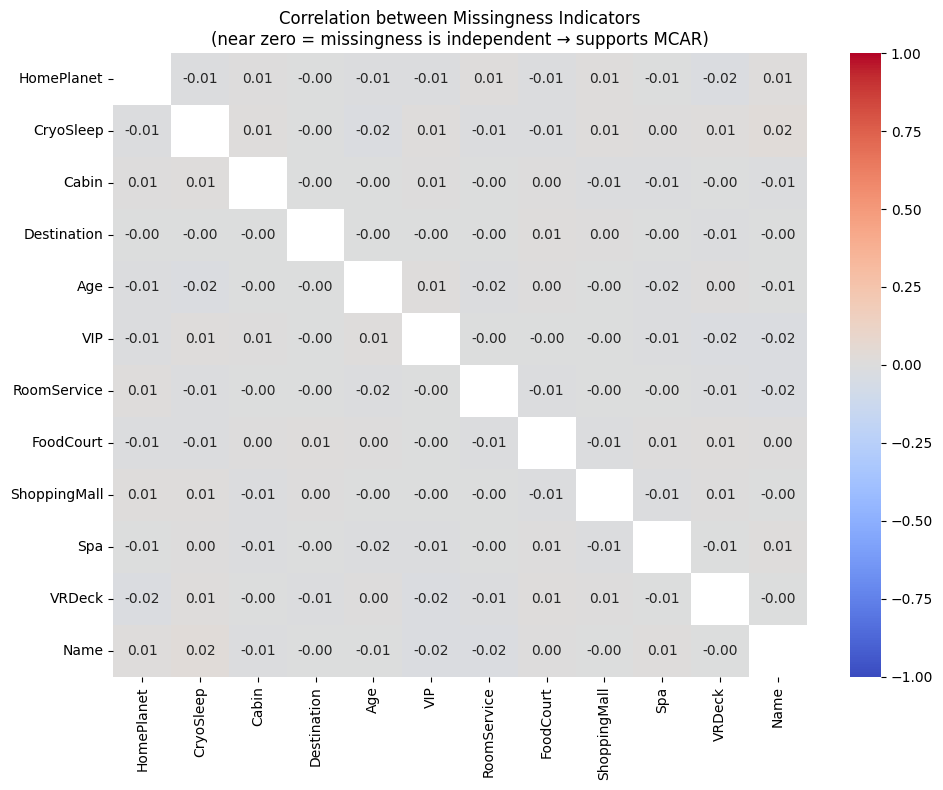

In [15]:
miss_indicators = df.isnull().astype(int)
miss_indicators = miss_indicators[miss_indicators.sum()[miss_indicators.sum() > 0].index]

# Phi coefficient (correlation between binary variables)
miss_corr = miss_indicators.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(miss_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            mask=np.eye(len(miss_corr), dtype=bool))
plt.title("Correlation between Missingness Indicators\n(near zero = missingness is independent → supports MCAR)")
plt.tight_layout()
plt.show()

### Little's MCAR Test

In [16]:
def littles_mcar_test(df):
    """
    Little's MCAR test (1988).
    H0: data is Missing Completely At Random.
    Returns chi-square statistic, degrees of freedom, and p-value.
    """
    df = df.copy()
    vars_ = df.columns.tolist()
    n, p = df.shape

    # Overall means (using all available values per column)
    grand_means = df.mean()

    # Encode missing pattern as a tuple of booleans per row
    patterns = df.isnull().apply(tuple, axis=1)
    unique_patterns = patterns.unique()

    chi2_stat = 0.0
    total_df = 0

    for pattern in unique_patterns:
        mask = patterns == pattern
        observed_cols = [v for v, missing in zip(vars_, pattern) if not missing]

        if len(observed_cols) == 0:
            continue

        group = df.loc[mask, observed_cols].dropna()
        n_j = len(group)

        if n_j < 2:
            continue

        group_mean = group.mean()
        diff = (group_mean - grand_means[observed_cols]).values

        # Covariance of observed columns in this pattern
        cov = df[observed_cols].cov()
        try:
            cov_inv = np.linalg.pinv(cov.values)
            chi2_stat += n_j * diff @ cov_inv @ diff
            total_df += len(observed_cols)
        except np.linalg.LinAlgError:
            continue

    total_df -= p  # subtract number of variables (estimated means)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=max(total_df, 1))

    return chi2_stat, total_df, p_value


# Run on numeric columns (Little's test requires numeric data)
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
chi2, dof, p = littles_mcar_test(df[numeric_cols])

print("Little's MCAR Test")
print(f"  Chi-square: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p:.4f}")
print()
if p > 0.05:
    print("Conclusion: Fail to reject H0 — data is consistent with MCAR.")
else:
    print("Conclusion: Reject H0 — data is NOT MCAR (likely MAR or MNAR).")

Little's MCAR Test
  Chi-square: 80.7924
  Degrees of freedom: 82
  p-value: 0.5170

Conclusion: Fail to reject H0 — data is consistent with MCAR.


# Numerical Features Distributions and Mutual Information

In [17]:
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Luxury_Features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
target = 'Transported'

In [18]:
df[num_features].skew().apply(np.abs)

Age              0.419097
RoomService      6.333014
FoodCourt        7.102228
ShoppingMall    12.627562
Spa              7.636020
VRDeck           7.819732
dtype: float64

### **<font color = 'DarkRed'> We can see that all the Luxury Features have a skewed distribution, so we need to apply a transformation to adjust the skewness </font>**

In [19]:
df[Luxury_Features] = df[Luxury_Features].astype(float).apply(np.log1p)
df[num_features].skew().apply(np.abs)

Age             0.419097
RoomService     1.117736
FoodCourt       1.110788
ShoppingMall    1.201576
Spa             1.090025
VRDeck          1.160167
dtype: float64

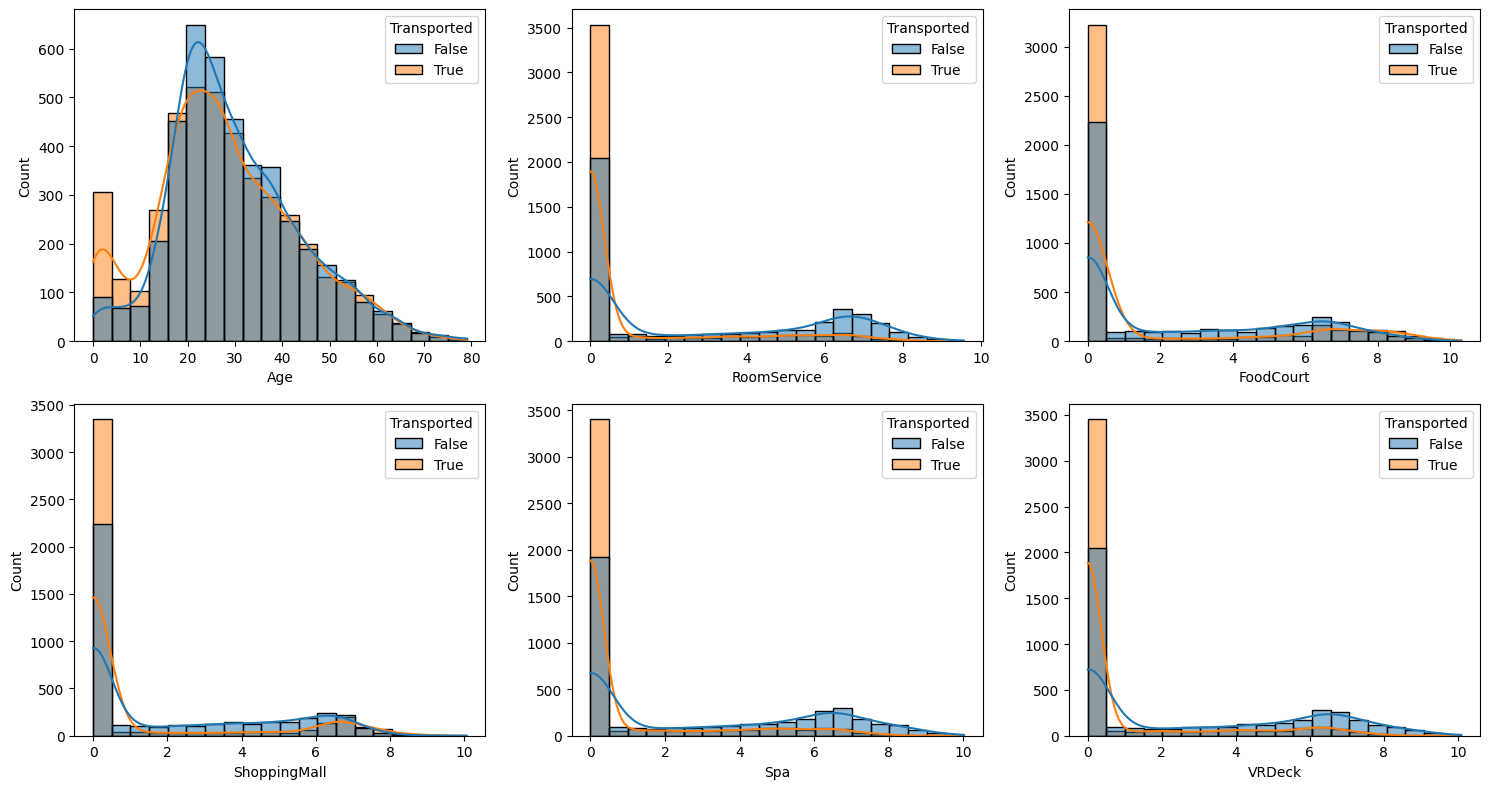

In [20]:
Plot_Num_Distributions(df, num_features, target, ncols = 3)

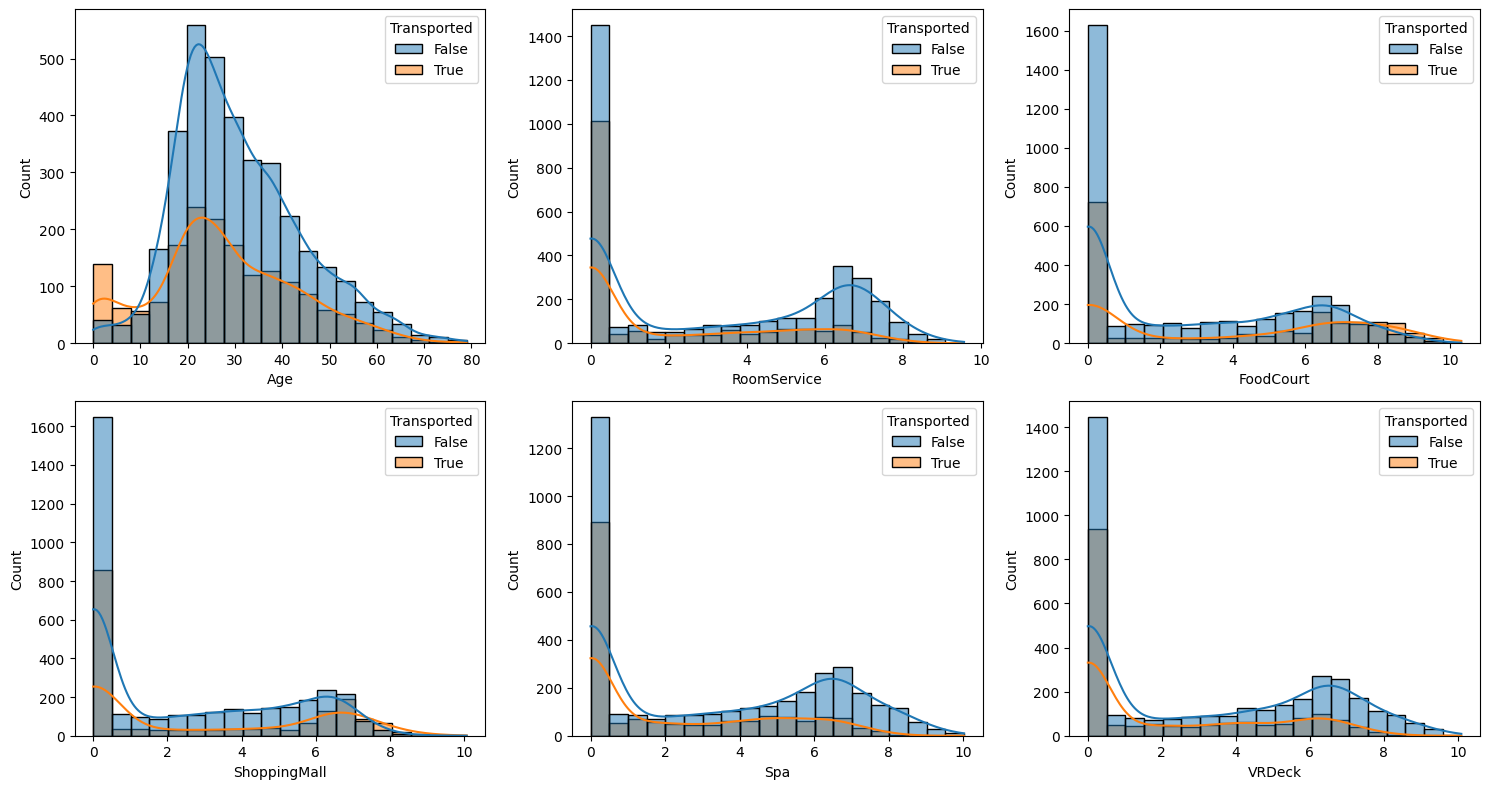

In [21]:
Plot_Num_Distributions(df[df.CryoSleep == False], num_features, target, ncols = 3)

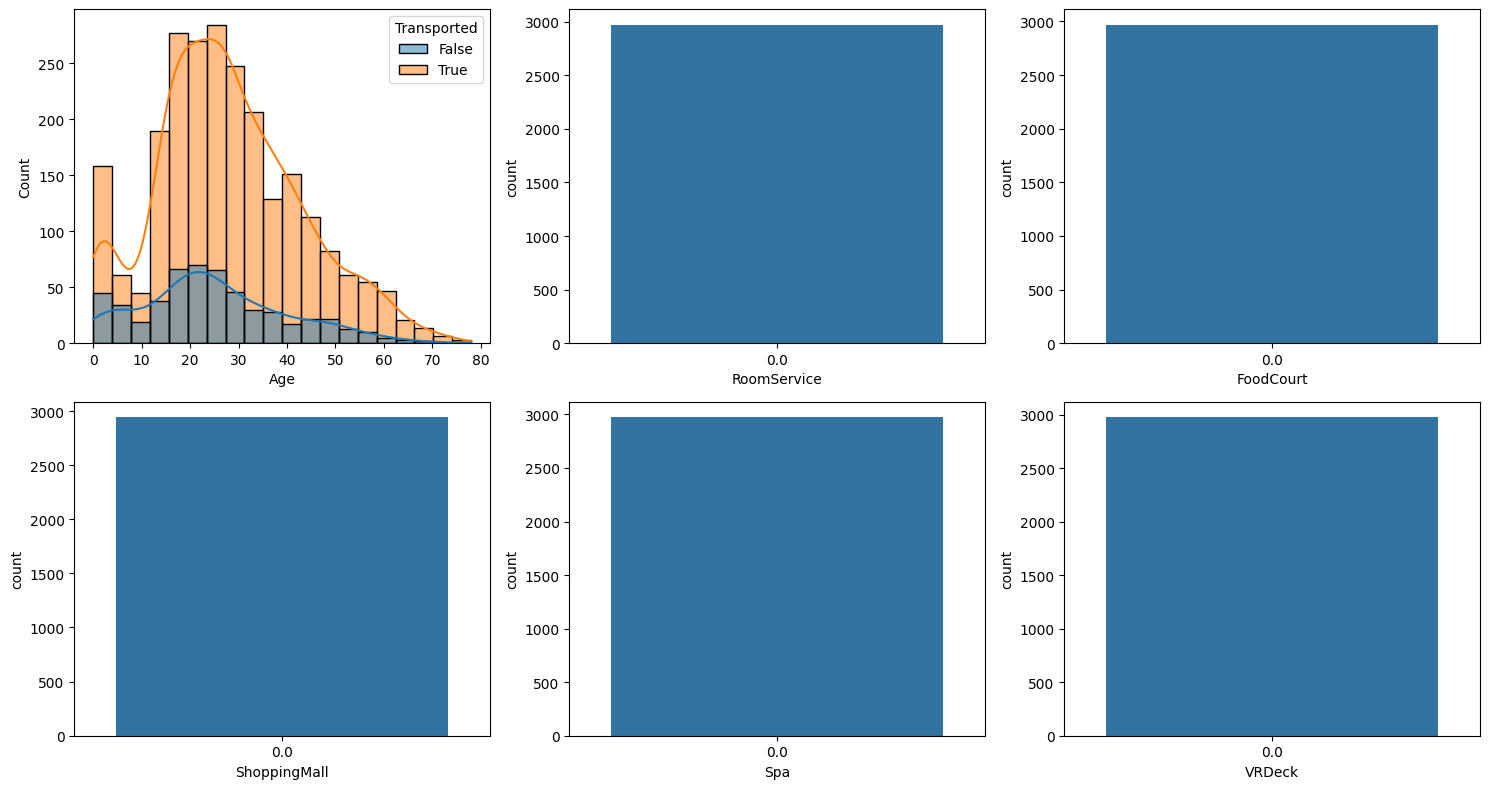

In [22]:
Plot_Num_Distributions(df[df.CryoSleep == True], num_features, target, ncols = 3)

In [23]:
bins = 11
bin_labels = range(1, bins + 1)
df['Age_Bin'], Bin_ranges = pd.qcut(df.Age, q = bins, labels = bin_labels, retbins = True)
Bin_ranges

array([ 0., 12., 18., 20., 23., 25., 28., 32., 37., 42., 50., 79.])

In [24]:
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Age_Bin
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Maham Ofracculy,False,9
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,4.700480,2.302585,3.258097,6.309918,3.806662,Juanna Vines,True,5
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,3.784190,8.182280,0.000000,8.812248,3.912023,Altark Susent,False,11
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.000000,7.157735,5.918894,8.110728,5.267858,Solam Susent,False,8
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,5.717028,4.262680,5.023881,6.338594,1.098612,Willy Santantines,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.000000,8.827615,0.000000,7.404888,4.317488,Gravior Noxnuther,False,9
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Kurta Mondalley,False,2
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.000000,0.000000,7.535297,0.693147,0.000000,Fayey Connon,True,6
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.000000,6.956545,0.000000,5.869297,8.082093,Celeon Hontichre,False,7


Text(0.5, 1.0, 'Age_Bin Distribution for Passengers Not in CryoSleep')

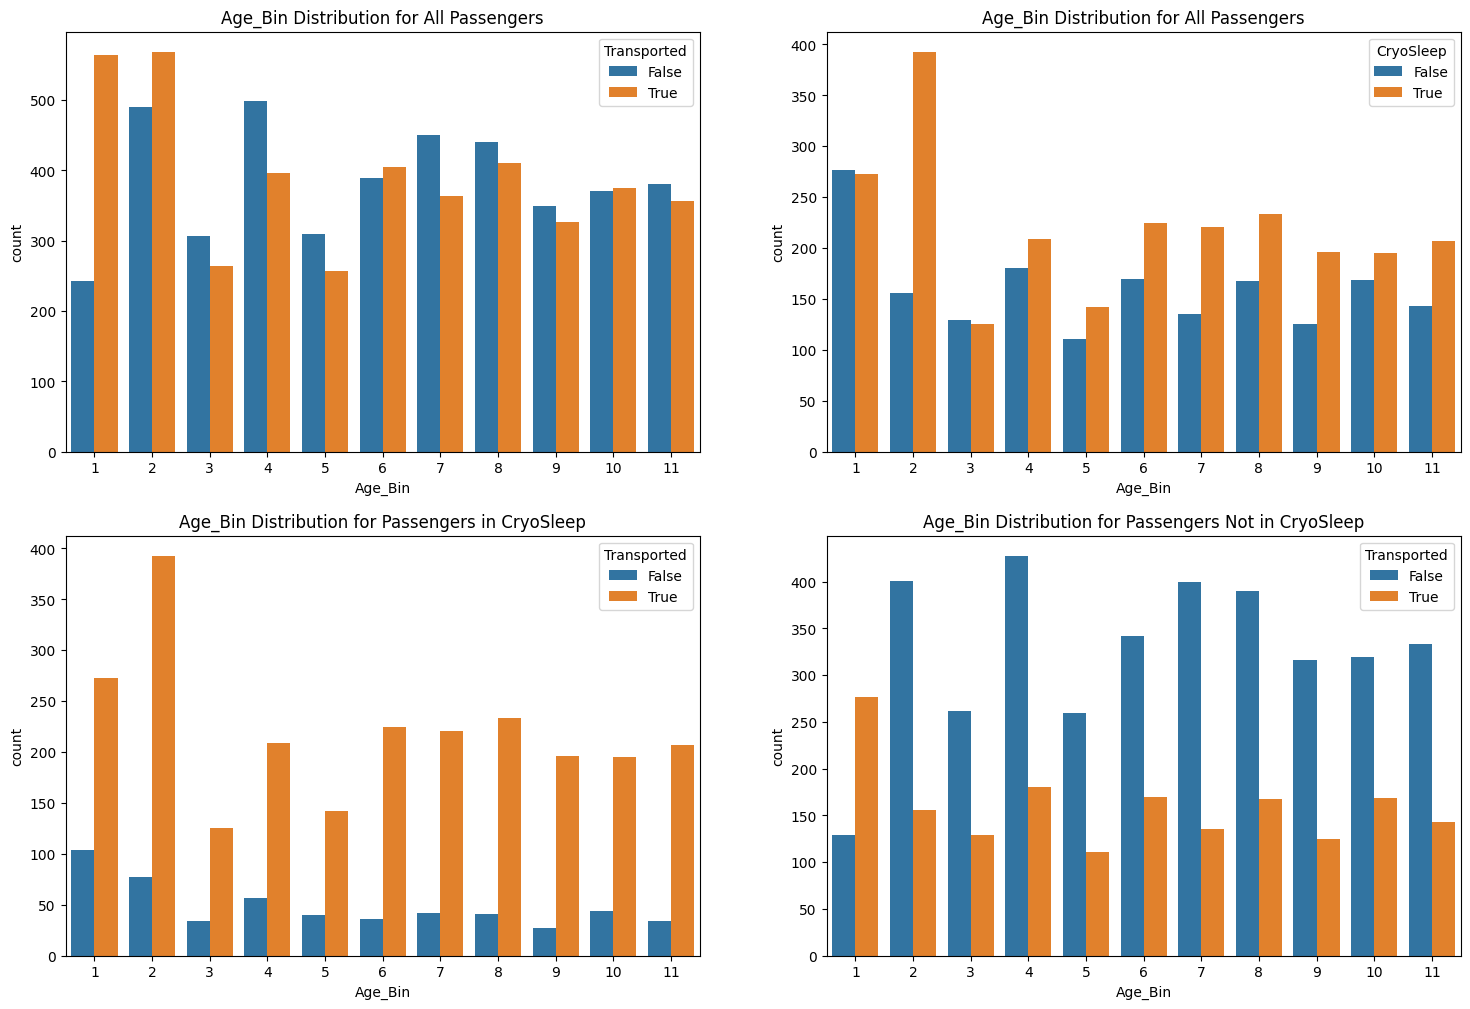

In [25]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (18, 12))
axs = axs.flatten()
sns.countplot(data = df, x = 'Age_Bin', hue = target, ax = axs[0])
sns.countplot(data = df[df.Transported == True], x = 'Age_Bin', hue = 'CryoSleep', ax = axs[1])
sns.countplot(data = df[df.CryoSleep == True], x = 'Age_Bin', hue = target, ax = axs[2])
sns.countplot(data = df[df.CryoSleep == False], x = 'Age_Bin', hue = target, ax = axs[3])

axs[0].set_title('Age_Bin Distribution for All Passengers')
axs[1].set_title('Age_Bin Distribution for All Passengers')
axs[2].set_title('Age_Bin Distribution for Passengers in CryoSleep')
axs[3].set_title('Age_Bin Distribution for Passengers Not in CryoSleep')

## Observations
* Passengers in Cryosleep are a lot more likely to be transported than those not in Cryosleep
* Young passengers are more likely to be transported than adults.
* Teens (13 - 18) are more likely to be in Cryosleep
* Teens not in Cryosleep are less likely to be transported
* Children (0 - 12) are the least likely to be negatively affected for not being in CryoSleep. They still have an advantage over all other age groups
* Obviously, passengers in Cryosleep spend no money on Luxury items. For passengers known to be in Cryosleep we can safely replace all nulls by zero for the Luxury features

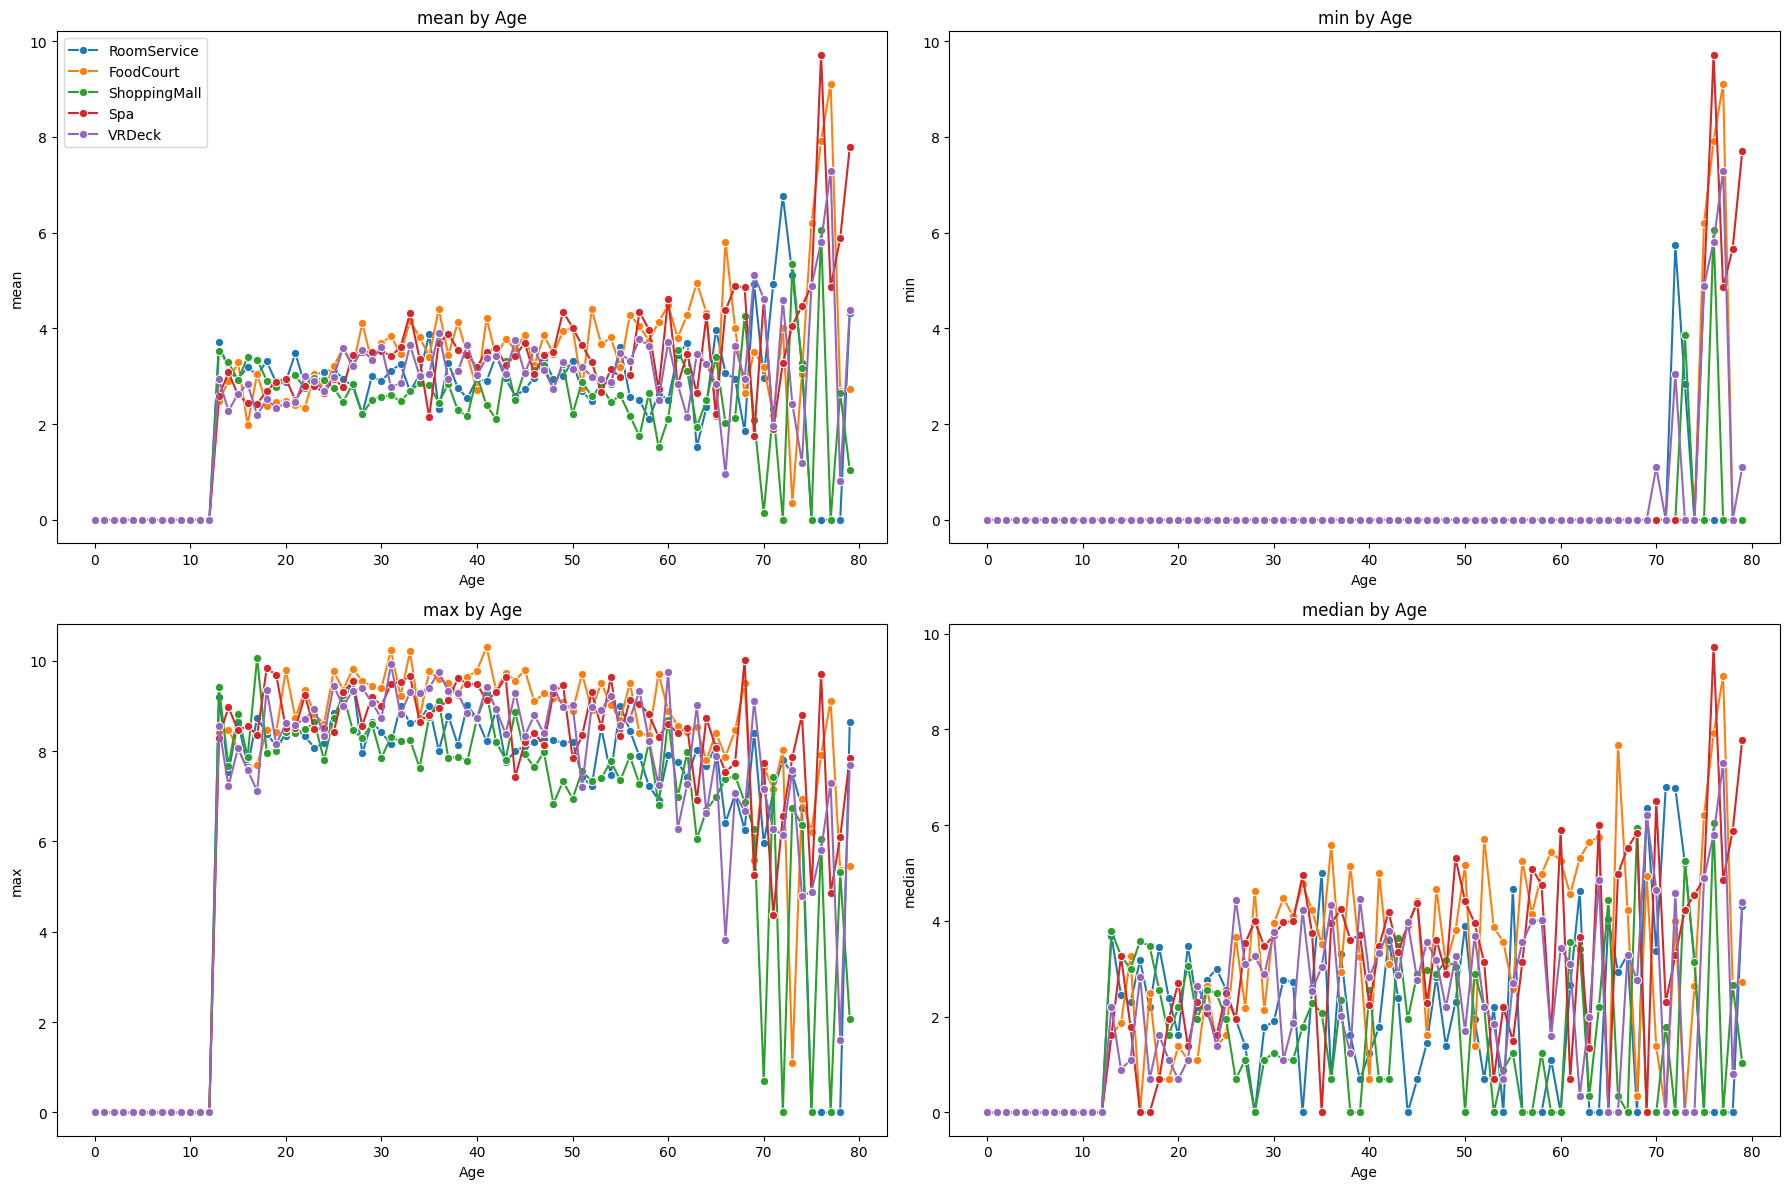

In [26]:
dfn = df[df.CryoSleep == False][num_features + ['Age_Bin', 'Transported']].dropna().copy()
# df_Luxury_byAge = df[df.CryoSleep == False].groupby('Age')[Luxury_Features].agg(['mean', 'min', 'max', 'median'])
dfn_Luxury_byAge = dfn.groupby('Age')[Luxury_Features].agg(['mean', 'min', 'max', 'median'])
stats = ['mean', 'min', 'max', 'median']

Plot_Stats(dfn_Luxury_byAge, 'Age', stats, ncols = 2)

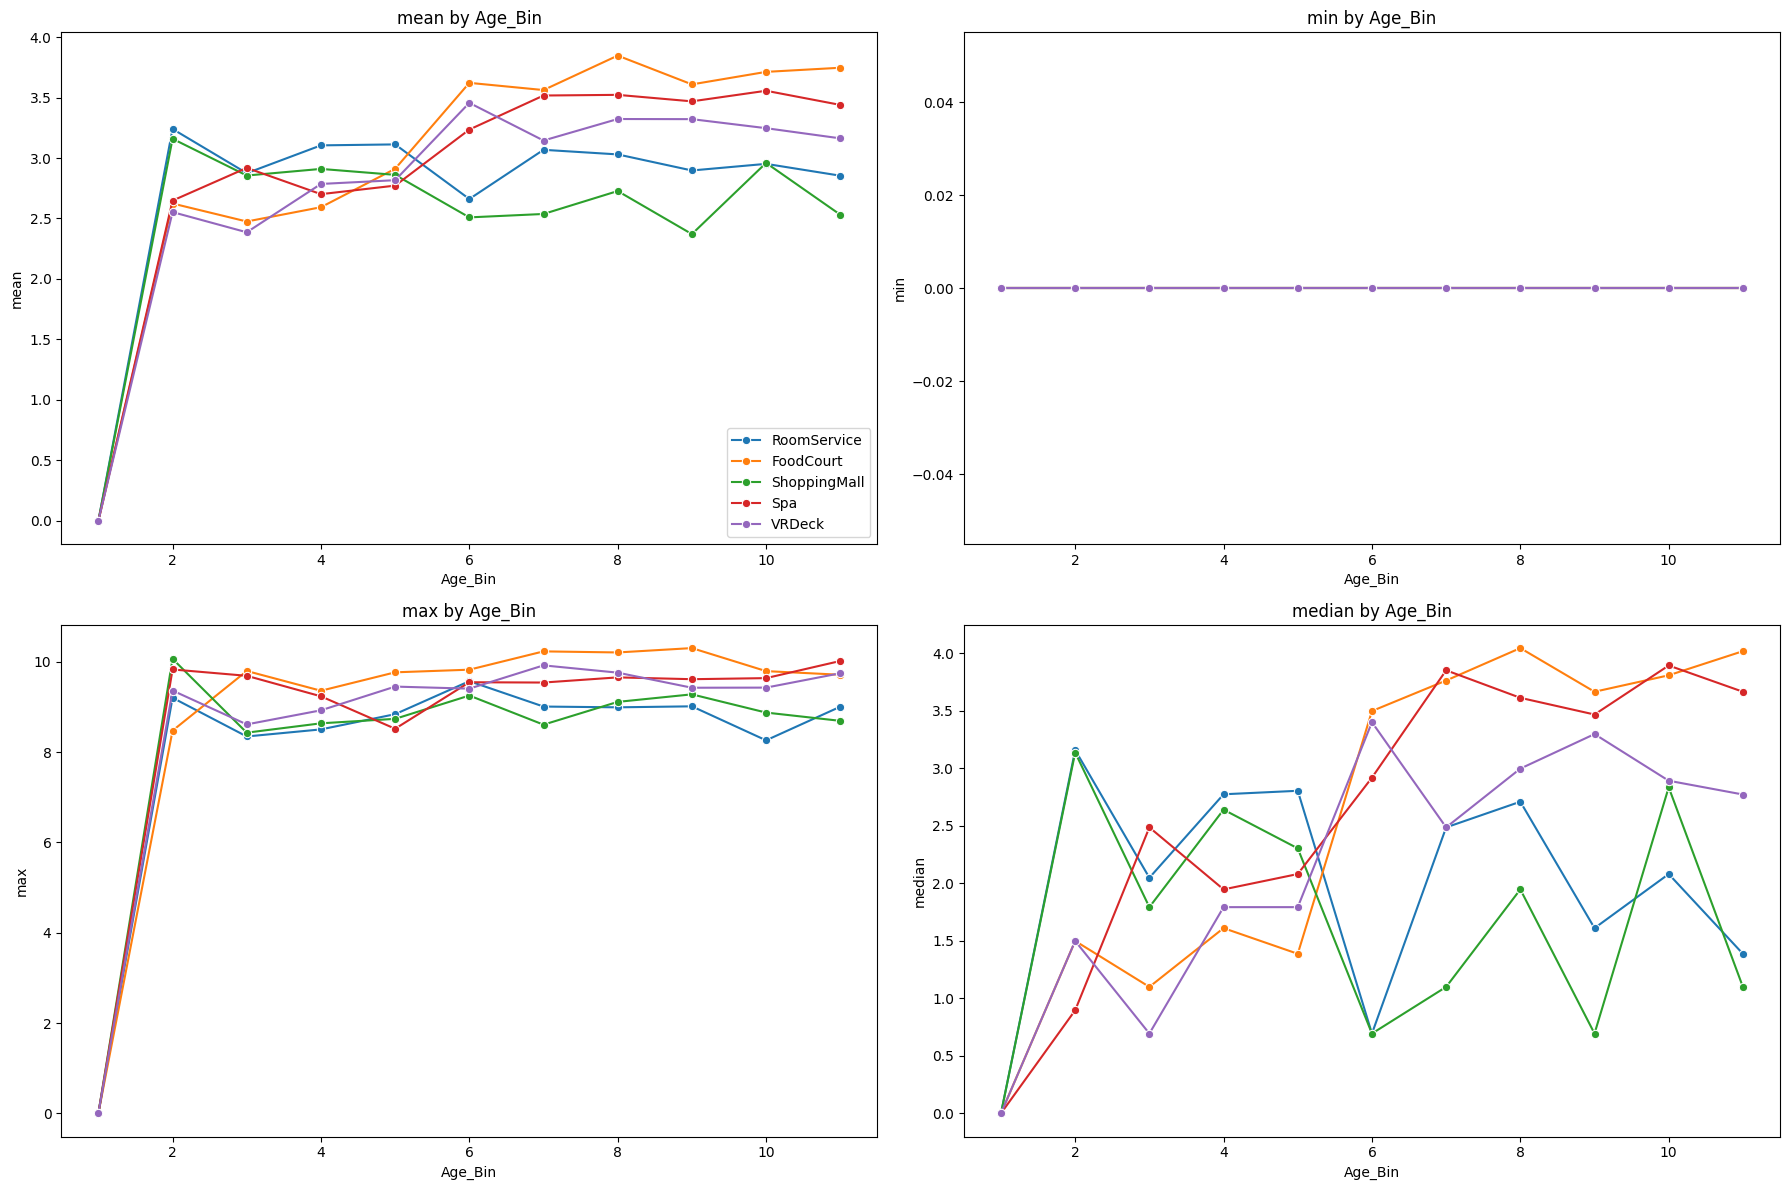

In [27]:
dfn_Luxury_byAge_Bin = dfn.groupby('Age_Bin', observed = True)[Luxury_Features].agg(['mean', 'min', 'max', 'median'])
Plot_Stats(dfn_Luxury_byAge_Bin, 'Age_Bin', stats, ncols = 2)

In [28]:
df[df.Age > 75].sort_values(by = 'Age', ascending = True)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Age_Bin
1390,1455_05,Europa,False,B/62/S,55 Cancri e,76.0,False,0.000000,7.913155,6.047372,9.716857,5.802118,Antino Wassird,False,11
8288,8852_01,Mars,True,D/278/P,TRAPPIST-1e,76.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Aark Homin,True,11
3526,3784_01,Earth,False,G/618/P,TRAPPIST-1e,77.0,False,0.000000,NaN,4.882802,8.289539,4.691348,Ale Morrencis,False,11
2930,3176_01,Europa,False,E/196/P,TRAPPIST-1e,77.0,False,0.000000,9.108640,0.000000,4.859812,7.289611,Ankalik Nateansive,True,11
2361,2545_01,Earth,True,G/410/P,55 Cancri e,78.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Joycey Hoppernardy,False,11
1429,1507_03,Earth,False,G/231/S,TRAPPIST-1e,78.0,False,0.000000,0.000000,0.000000,6.091310,1.609438,Anny Jeffey,False,11
6146,6485_01,Earth,False,F/1238/S,55 Cancri e,78.0,False,0.000000,5.365976,5.313206,5.666427,0.000000,Regory Haydenzier,True,11
615,0642_03,Europa,False,C/25/S,TRAPPIST-1e,79.0,False,0.000000,0.000000,0.000000,7.701200,1.098612,Chabik Kiling,False,11
4682,4991_01,Earth,False,G/806/P,TRAPPIST-1e,79.0,False,6.415097,NaN,0.000000,5.303305,1.791759,Rickie Pentss,False,11
338,0378_03,Europa,False,B/11/S,TRAPPIST-1e,79.0,False,8.639411,5.463832,2.079442,7.855545,7.685244,Naslon Pirejus,False,11


In [29]:
dfn_Luxury_byAge.loc[dfn_Luxury_byAge.index < 14]

RoomService                          FoodCourt                           \
            mean  min       max    median      mean  min       max    median   
Age                                                                            
0.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
1.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
2.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
3.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
4.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
5.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
6.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
7.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
8.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
9.0      0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
10.0     0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
11.0     0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
12.0     0.00000  0.0  0.000000  0.000000  0.000000  0.0  0.000000  0.000000   
13.0     3.70847  0.0  9.202409  3.688879  2.494101  0.0  8.408717  1.609438   

     ShoppingMall                               Spa                           \
             mean  min       max   median      mean  min       max    median   
Age                                                                            
0.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
1.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
2.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
3.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
4.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
5.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
6.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
7.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
8.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
9.0      0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
10.0     0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
11.0     0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
12.0     0.000000  0.0  0.000000  0.00000  0.000000  0.0  0.000000  0.000000   
13.0     3.521613  0.0  9.413608  3.78419  2.591584  0.0  8.298291  1.609438   

        VRDeck                           
          mean  min       max    median  
Age                                      
0.0   0.000000  0.0  0.000000  0.000000  
1.0   0.000000  0.0  0.000000  0.000000  
2.0   0.000000  0.0  0.000000  0.000000  
3.0   0.000000  0.0  0.000000  0.000000  
4.0   0.000000  0.0  0.000000  0.000000  
5.0   0.000000  0.0  0.000000  0.000000  
6.0   0.000000  0.0  0.000000  0.000000  
7.0   0.000000  0.0  0.000000  0.000000  
8.0   0.000000  0.0  0.000000  0.000000  
9.0   0.000000  0.0  0.000000  0.000000  
10.0  0.000000  0.0  0.000000  0.000000  
11.0  0.000000  0.0  0.000000  0.000000  
12.0  0.000000  0.0  0.000000  0.000000  
13.0  2.943788  0.0  8.546364  2.197225

In [30]:
# mask = dfn_Luxury_byAge.columns.get_level_values(1) == 'median'
# pd.set_option('display.max_rows', 100)
# display(dfn_Luxury_byAge.loc[:, mask])
# pd.reset_option('display.max_rows')
dfn.Age_Bin = dfn.Age_Bin.astype(int)
dfn.dtypes

Age             float64
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Age_Bin           int64
Transported        bool
dtype: object

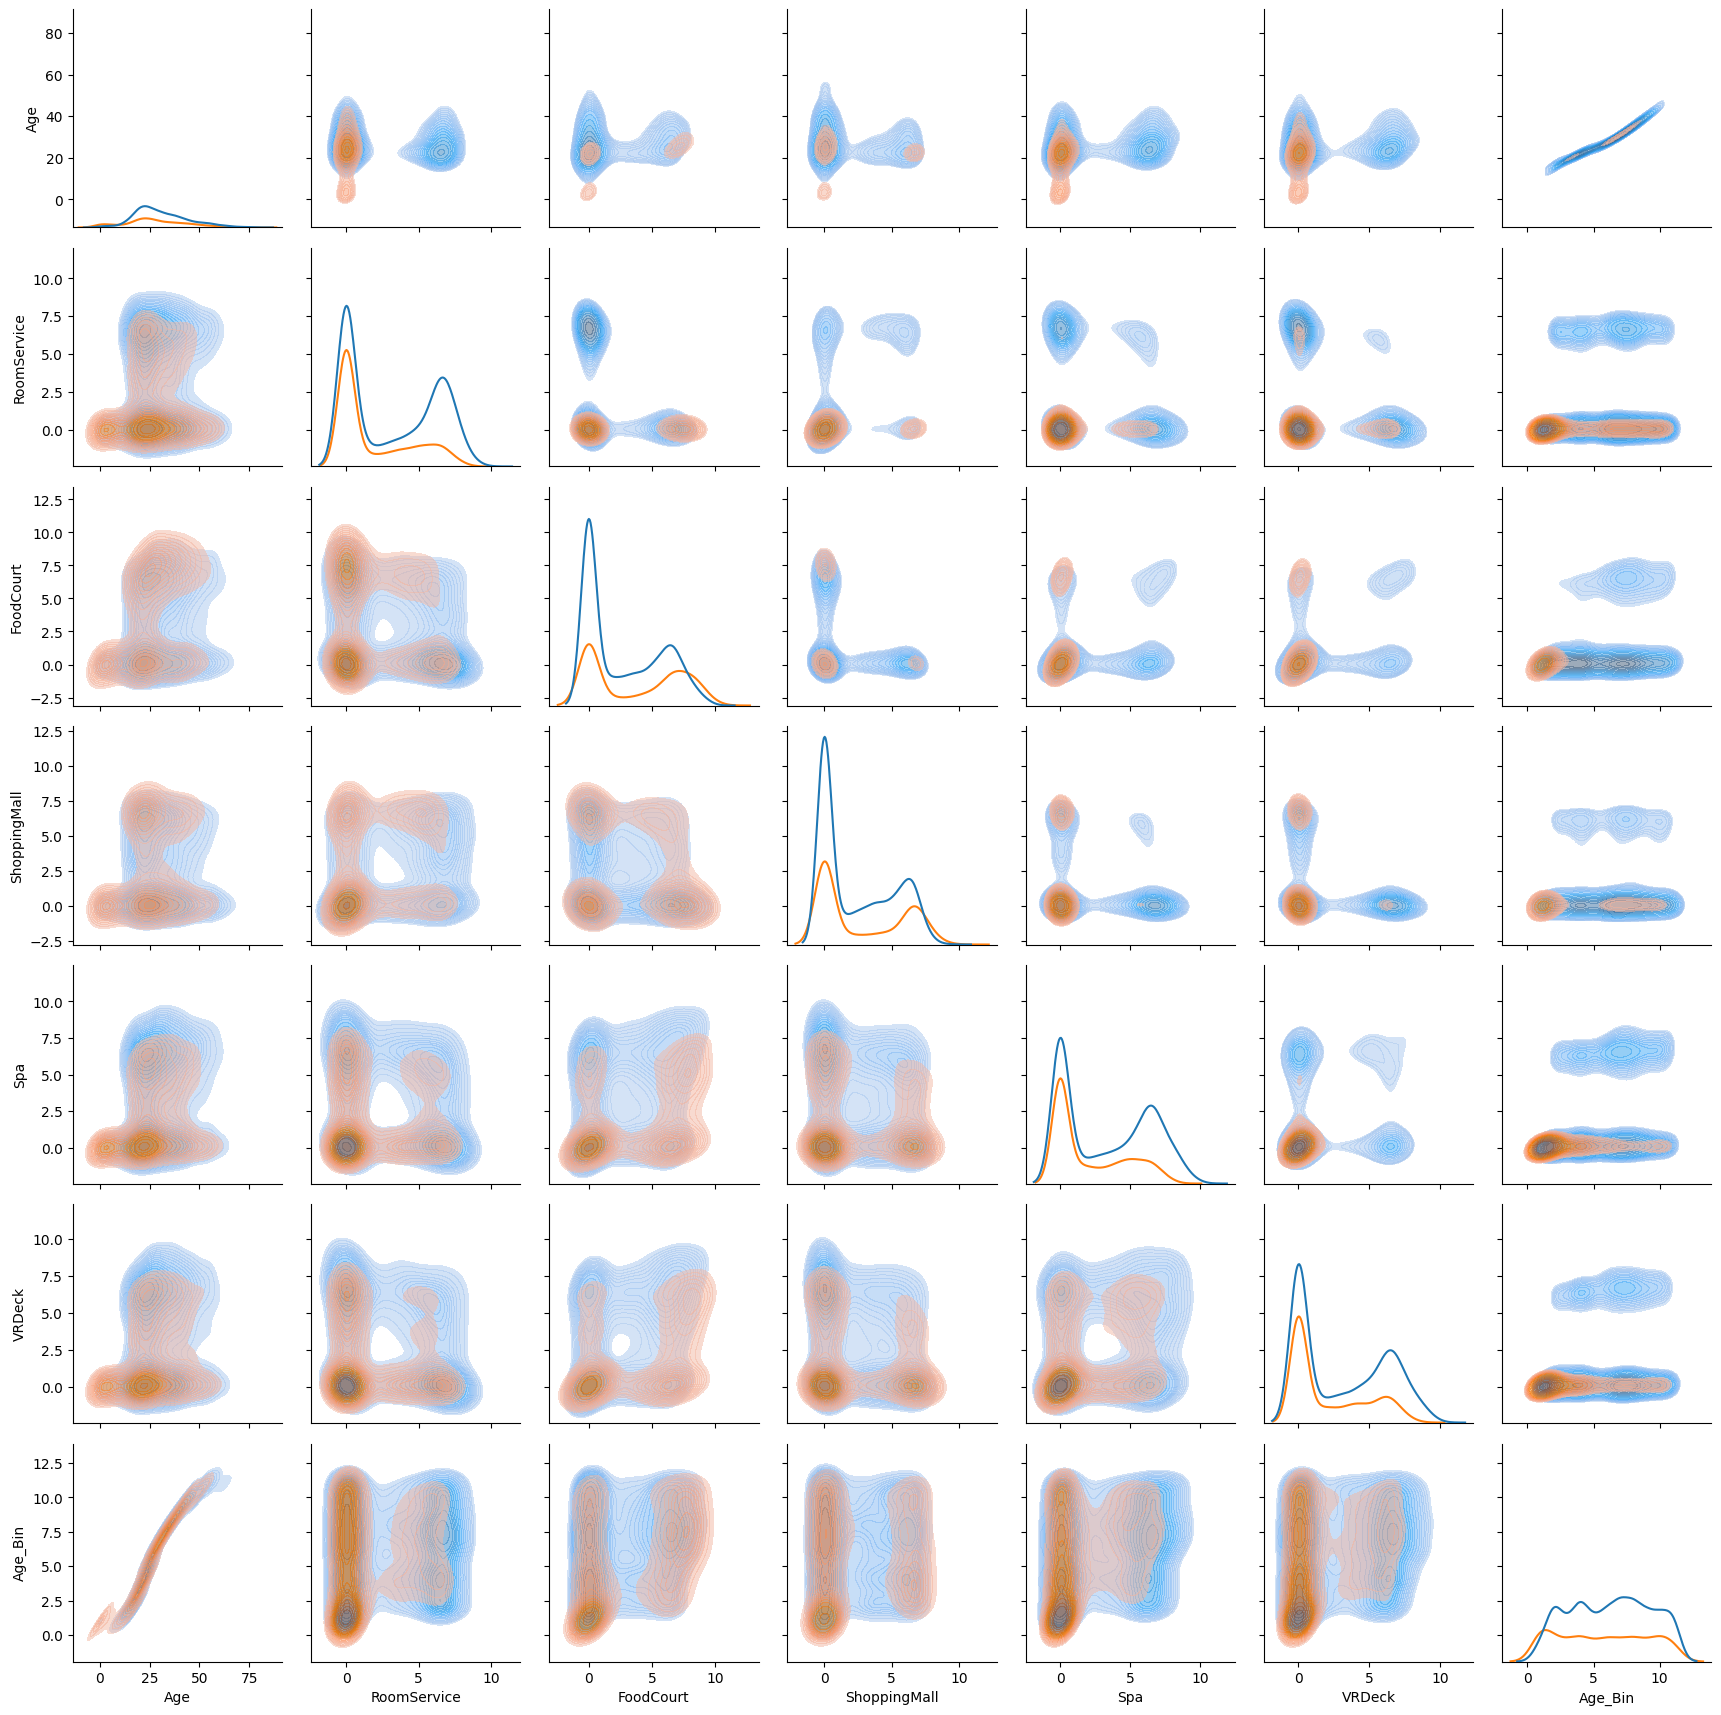

In [31]:
PairGrid_kde(dfn, num_features + ['Age_Bin'], hue = 'Transported')

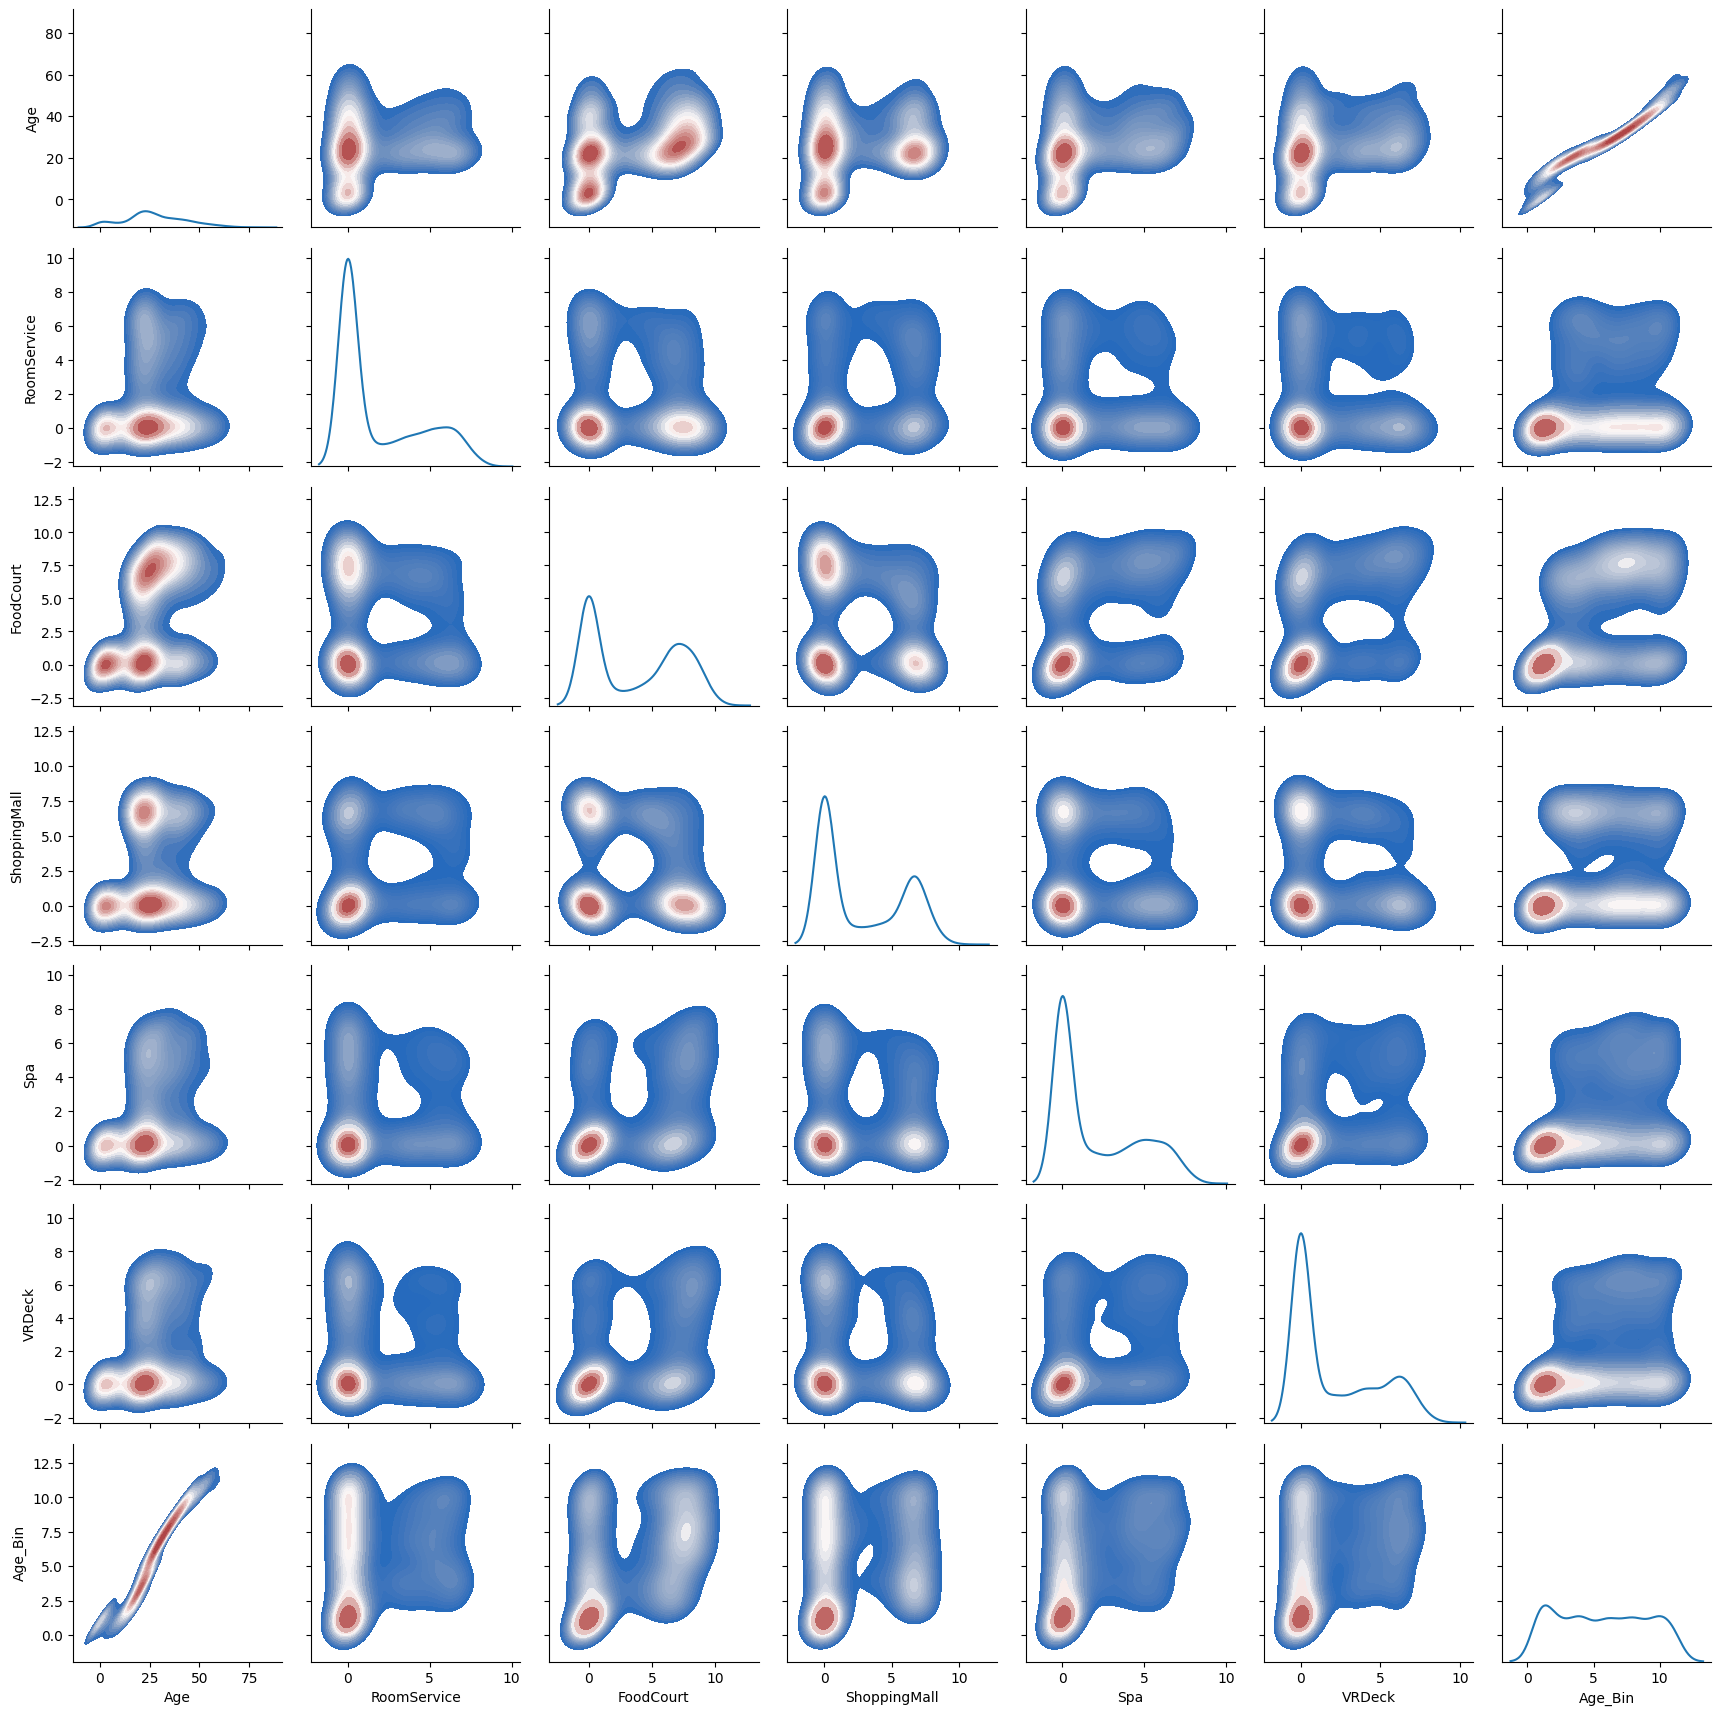

In [32]:
PairGrid_kde(dfn[dfn.Transported == True], num_features + ['Age_Bin'])

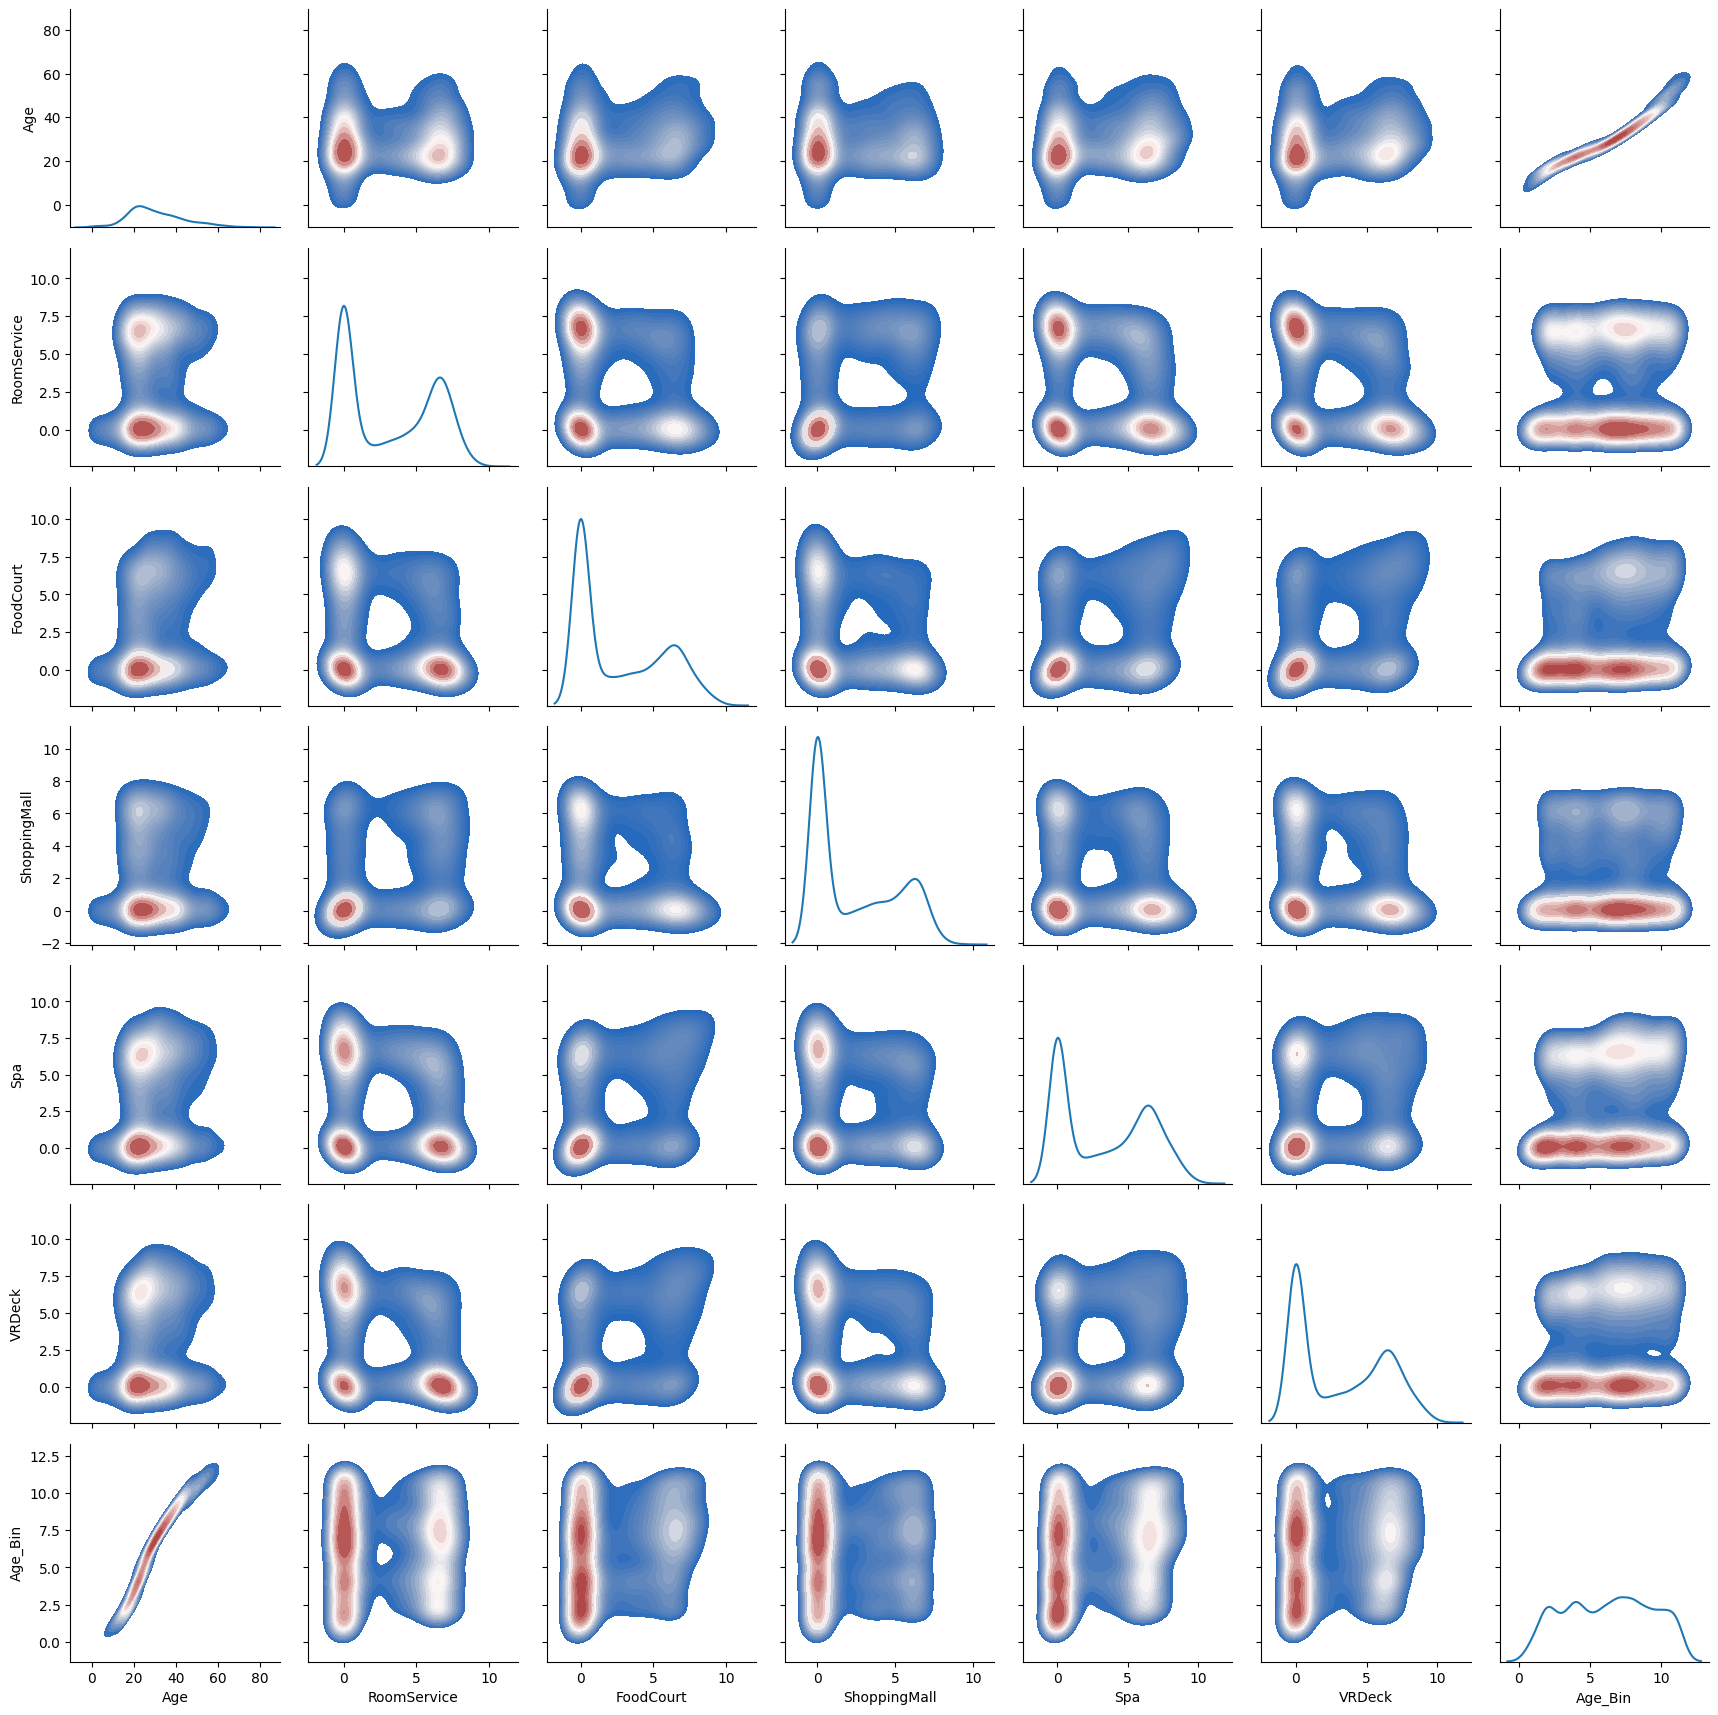

In [33]:
PairGrid_kde(dfn[dfn.Transported == False], num_features + ['Age_Bin'])

In [34]:
MI_matrix, MI_matrix_T, MI_matrix_NT, MI_min, MI_max = Get_MI_Matrices(dfn, num_features, 'Transported', classif = False)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
Age,0.000000,0.061180,0.077014,0.065485,0.086844,0.069780
RoomService,0.070896,0.000000,0.026681,0.073118,0.030051,0.034359
FoodCourt,0.071532,0.046207,0.000000,0.022507,0.063157,0.104349
ShoppingMall,0.057275,0.070649,0.013737,0.000000,0.032512,0.024952
Spa,0.079071,0.037785,0.064656,0.034156,0.000000,0.061357
VRDeck,0.085335,0.040811,0.101014,0.026938,0.050073,0.000000


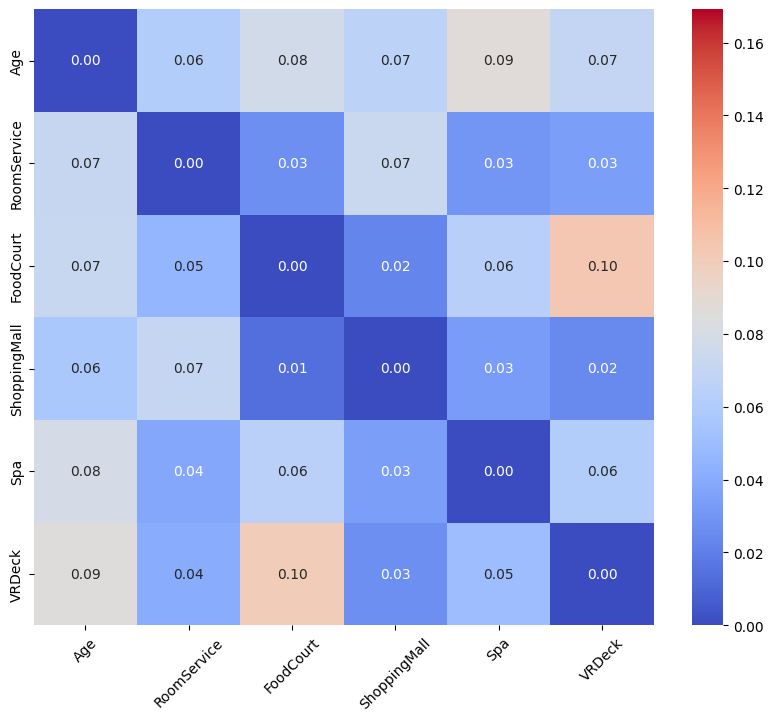

In [35]:
display(MI_matrix)
Plot_MI_Heatmap(MI_matrix, MI_min, MI_max)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
Age,0.000000,0.094516,0.165029,0.124693,0.134020,0.107205
RoomService,0.109610,0.000000,0.065805,0.061665,0.026765,0.025731
FoodCourt,0.169172,0.039889,0.000000,0.104995,0.103094,0.145931
ShoppingMall,0.142051,0.039742,0.085901,0.000000,0.045058,0.046758
Spa,0.115965,0.015646,0.103721,0.058466,0.000000,0.080921
VRDeck,0.100396,0.000000,0.139907,0.044578,0.076463,0.000000


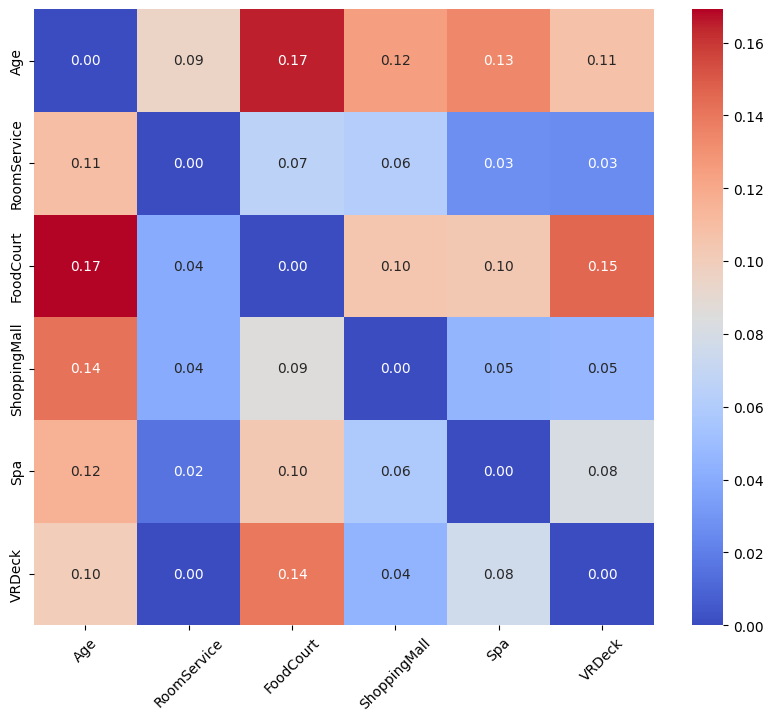

In [36]:
display(MI_matrix_T)
Plot_MI_Heatmap(MI_matrix_T, MI_min, MI_max)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
Age,0.000000,0.011517,0.044801,0.010221,0.041452,0.034442
RoomService,0.035135,0.000000,0.024236,0.061329,0.061083,0.067890
FoodCourt,0.028863,0.024302,0.000000,0.005092,0.072282,0.111894
ShoppingMall,0.015704,0.059921,0.000000,0.000000,0.029572,0.007388
Spa,0.031698,0.059176,0.076301,0.021512,0.000000,0.060589
VRDeck,0.037487,0.067340,0.104930,0.011547,0.071041,0.000000


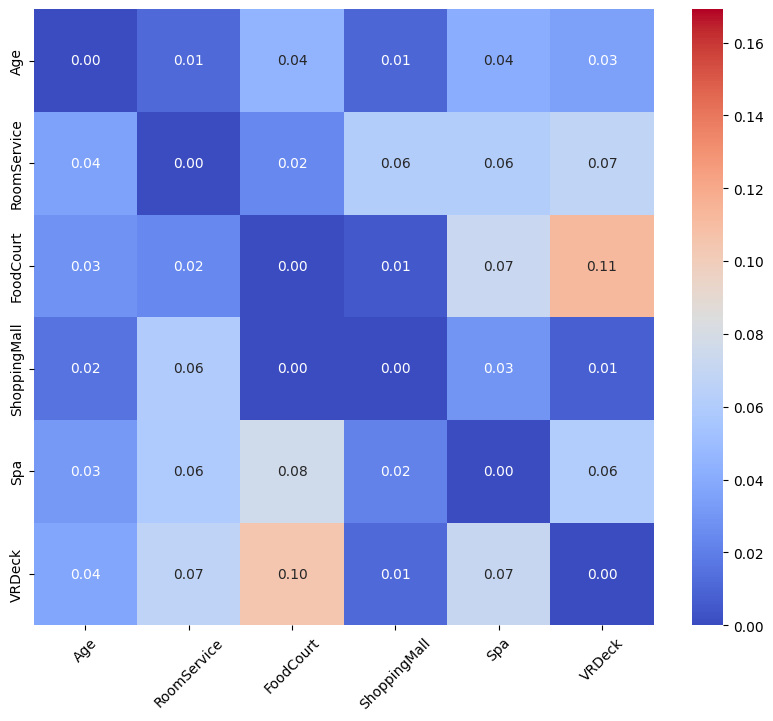

In [37]:
display(MI_matrix_NT)
Plot_MI_Heatmap(MI_matrix_NT, MI_min, MI_max)

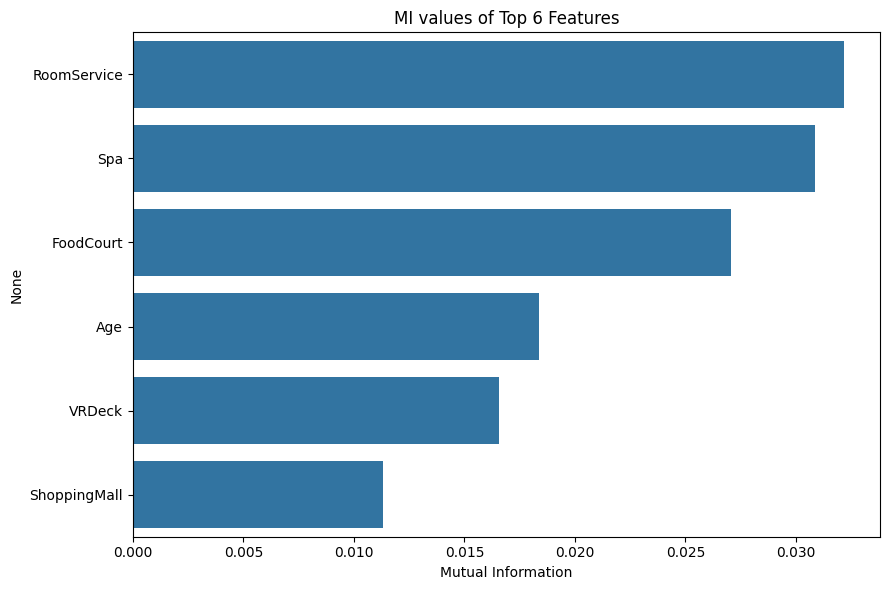

In [38]:
X = dfn.drop(columns = ['Transported', 'Age_Bin'])
y = dfn['Transported']
MI = pd.Series(mutual_info_classif(X, y), index = X.columns.tolist()).sort_values(ascending = False)
Plot_MI(MI, topk = len(MI), bottom = False)

## Observations
* Passengers under Age of 13 do not spend on Luxury items
* Luxury items have a bimodal distribution. Most passengers either spend very little or a lot on Luxury items.
* Spending on VRDeck, Spa, or RoomService decreases the chance of a passenger being transported
* There is higher mutual information between Age and Luxury features among Transported Passengers (who are not in CryoSleep) than among those not transported, particularly mutual information between Age and FoodCourt

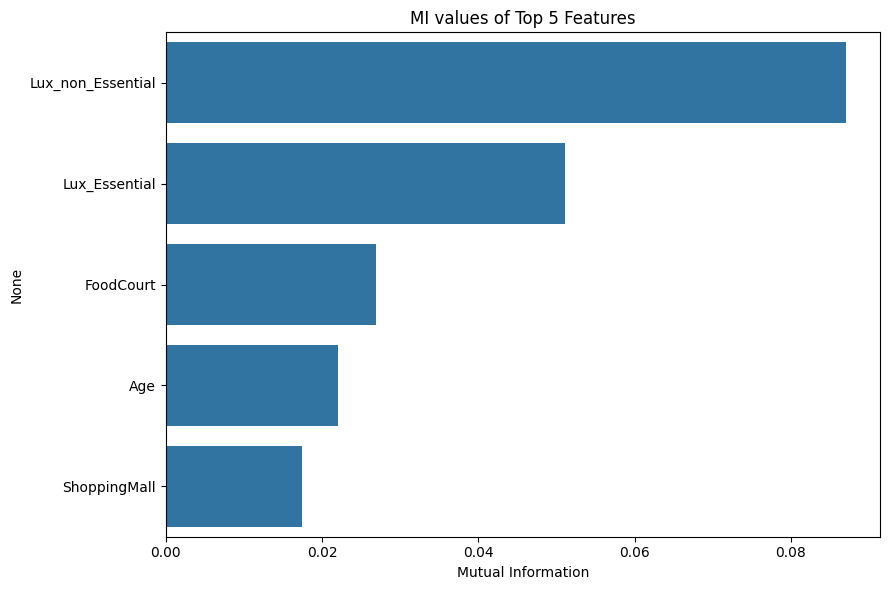

In [39]:
dfn2 = dfn.dropna().copy()
Non_Essential_Lux_Features = ['RoomService', 'Spa', 'VRDeck']
Essential_Lux_Features = ['FoodCourt', 'ShoppingMall']
dfn2['Lux_non_Essential'] = dfn2[Non_Essential_Lux_Features].mean(axis = 1)
dfn2['Lux_Essential'] = dfn2[Essential_Lux_Features].mean(axis = 1)
dfn2.drop(columns = Non_Essential_Lux_Features, inplace = True)

X = dfn2.drop(columns = ['Transported', 'Age_Bin'])
y = dfn2['Transported']
MI = pd.Series(mutual_info_classif(X, y), index = X.columns.tolist()).sort_values(ascending = False)
Plot_MI(MI, topk = len(MI), bottom = False)

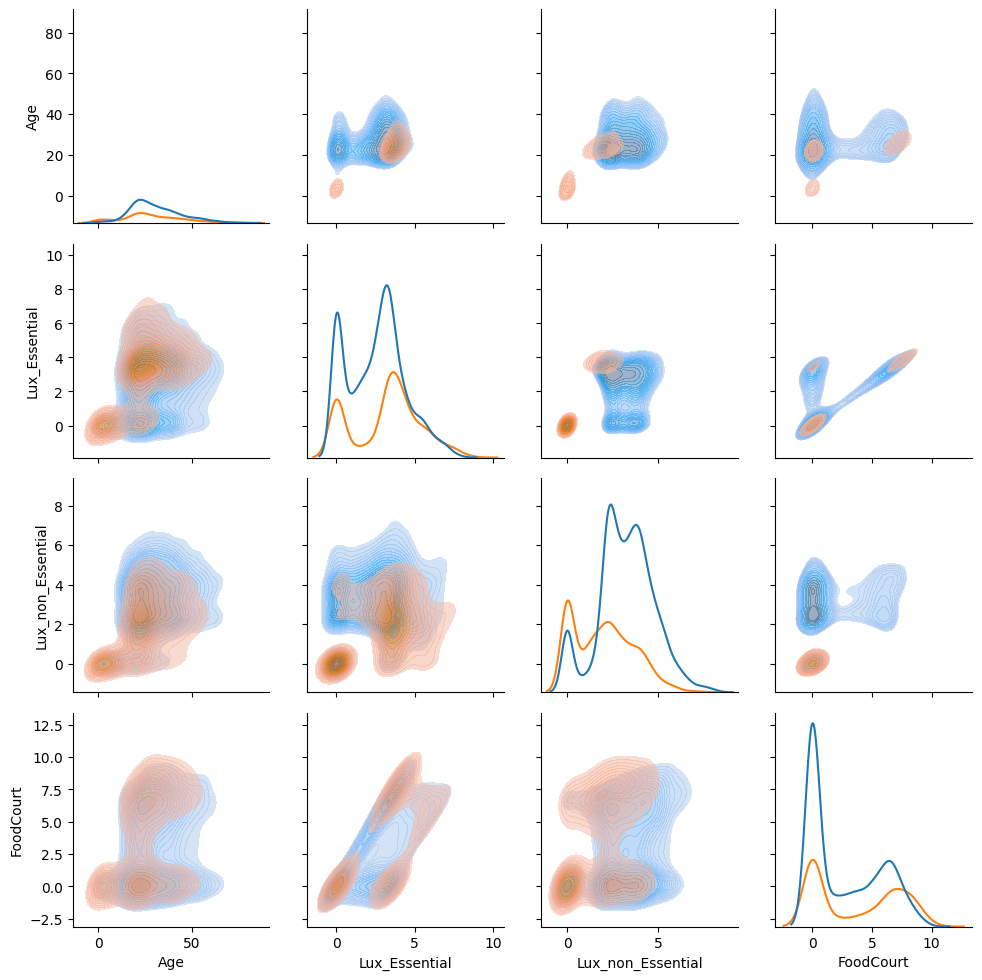

In [40]:
PairGrid_kde(dfn2, ['Age', 'Lux_Essential', 'Lux_non_Essential', 'FoodCourt'], hue = 'Transported')

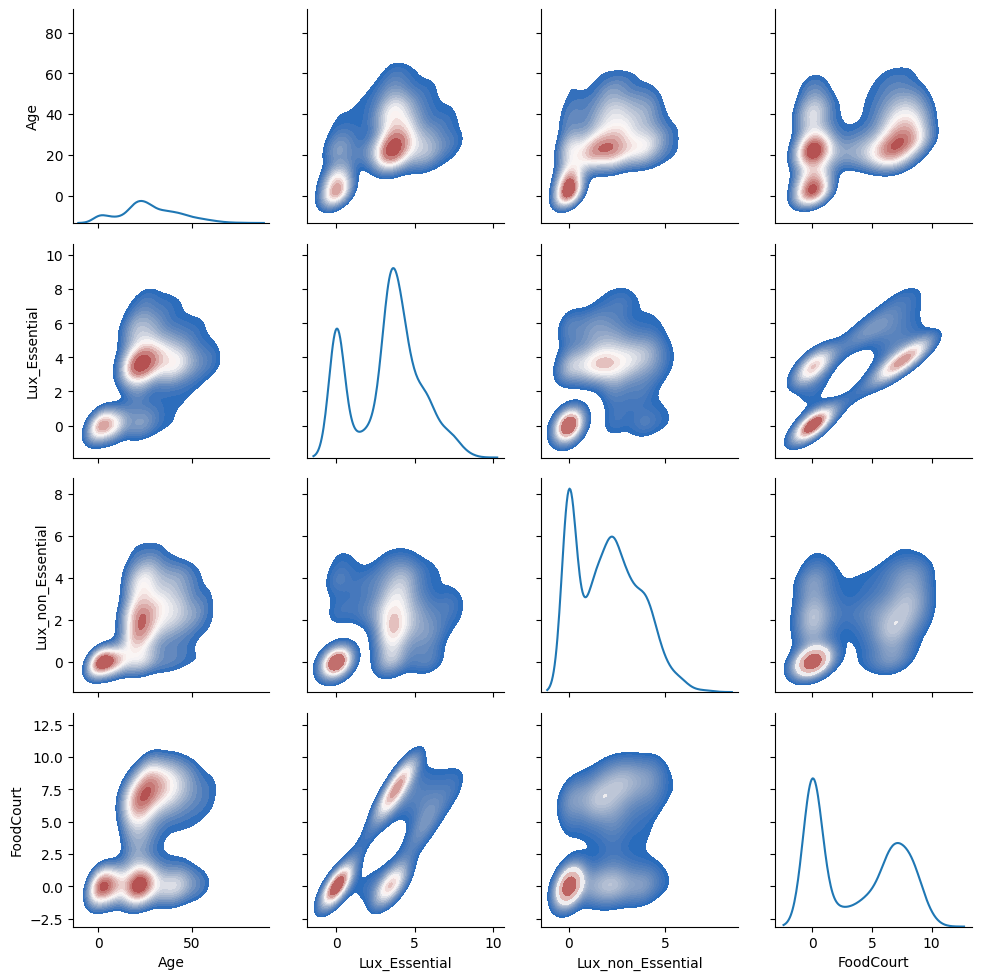

In [41]:
PairGrid_kde(dfn2[dfn2.Transported == True], ['Age', 'Lux_Essential', 'Lux_non_Essential', 'FoodCourt'])

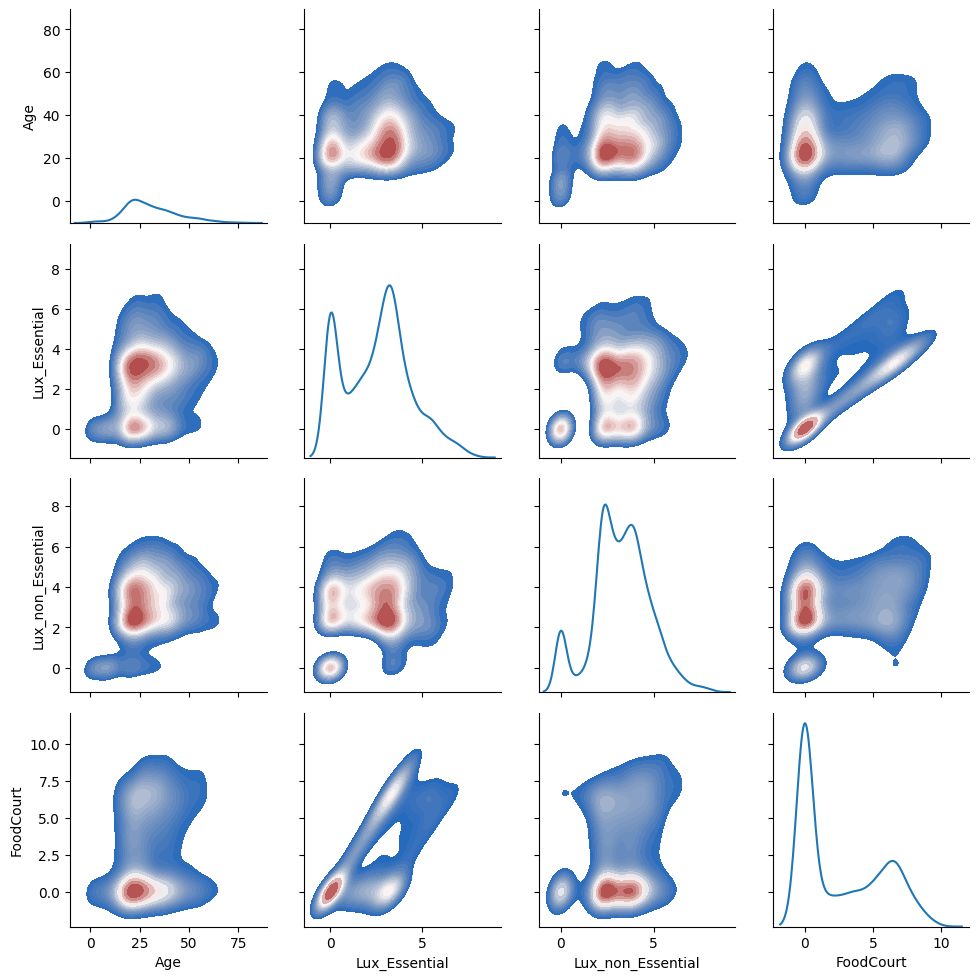

In [42]:
PairGrid_kde(dfn2[dfn2.Transported == False], ['Age', 'Lux_Essential', 'Lux_non_Essential', 'FoodCourt'])

# Categorical Features

In [43]:
Cat_Features = ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']

In [44]:
for col in Cat_Features:
    print(col, len(df[col].dropna()), df[col].dropna().nunique())

PassengerId 8693 8693
HomePlanet 8492 3
CryoSleep 8476 2
Cabin 8494 6560
Destination 8511 3
VIP 8490 2
Name 8493 8473


In [45]:
name_count = df.Name.value_counts()
dupl_values = name_count[name_count > 1].index.to_list()
df[df.Name.isin(dupl_values)].sort_values(by = 'Name')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Age_Bin
7270,7775_01,Europa,False,C/253/P,55 Cancri e,28.0,False,2.079442,6.194405,0.000000,1.609438,8.704171,Alraium Disivering,False,6
6296,6665_01,Europa,True,B/222/P,55 Cancri e,17.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Alraium Disivering,True,2
476,0512_02,Europa,True,D/18/S,TRAPPIST-1e,55.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Ankalik Nateansive,True,11
2930,3176_01,Europa,False,E/196/P,TRAPPIST-1e,77.0,False,0.000000,9.108640,0.000000,4.859812,7.289611,Ankalik Nateansive,True,11
8488,9071_01,Earth,False,F/1855/P,55 Cancri e,22.0,False,0.000000,0.000000,6.978214,3.850148,1.386294,Anton Woody,False,4
2991,3236_03,Earth,False,E/200/P,TRAPPIST-1e,18.0,False,0.000000,3.433987,0.000000,6.629363,1.791759,Anton Woody,False,2
2559,2746_01,Mars,False,F/569/P,TRAPPIST-1e,52.0,False,6.632002,0.000000,5.877736,1.791759,0.000000,Apix Wala,False,11
4108,4387_01,Mars,False,F/902/P,PSO J318.5-22,32.0,False,5.262690,0.000000,6.091310,2.944439,0.000000,Apix Wala,False,7
7871,8398_01,Europa,True,B/329/S,TRAPPIST-1e,15.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Asch Stradick,True,2
6086,6432_01,Europa,False,D/202/P,55 Cancri e,55.0,False,4.744932,5.407172,0.000000,7.853993,7.979339,Asch Stradick,False,11


In [46]:
df2 = df.copy()
df_split = df2.Cabin.str.split("/", expand = True).rename({0: 'deck', 1: 'Cabin Number', 2: 'side'}, axis = 1)
df2 = pd.concat([df2, df_split], axis = 1)
df_split = df2.Name.str.split(" ", expand = True).rename({0: 'First Name', 1: 'Last Name'}, axis = 1)
df2 = pd.concat([df2, df_split], axis = 1)
df2 = df2.drop(columns = ['Cabin', 'Name'])
df2

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Age_Bin,deck,Cabin Number,side,First Name,Last Name
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,False,9,B,0,P,Maham,Ofracculy
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,4.700480,2.302585,3.258097,6.309918,3.806662,True,5,F,0,S,Juanna,Vines
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,3.784190,8.182280,0.000000,8.812248,3.912023,False,11,A,0,S,Altark,Susent
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.000000,7.157735,5.918894,8.110728,5.267858,False,8,A,0,S,Solam,Susent
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,5.717028,4.262680,5.023881,6.338594,1.098612,True,2,F,1,S,Willy,Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,55 Cancri e,41.0,True,0.000000,8.827615,0.000000,7.404888,4.317488,False,9,A,98,P,Gravior,Noxnuther
8689,9278_01,Earth,True,PSO J318.5-22,18.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,False,2,G,1499,S,Kurta,Mondalley
8690,9279_01,Earth,False,TRAPPIST-1e,26.0,False,0.000000,0.000000,7.535297,0.693147,0.000000,True,6,G,1500,S,Fayey,Connon
8691,9280_01,Europa,False,55 Cancri e,32.0,False,0.000000,6.956545,0.000000,5.869297,8.082093,False,7,E,608,S,Celeon,Hontichre


In [47]:
for col in ['deck', 'Cabin Number', 'side', 'First Name', 'Last Name']:
    print(col, len(df2[col].dropna()), df2[col].dropna().nunique())

deck 8494 8
Cabin Number 8494 1817
side 8494 2
First Name 8493 2706
Last Name 8493 2217


#### For now, we can ignore Name, PassengerId, and Cabin Number since they have high cardinality

In [48]:
Categorical_Features = ['HomePlanet', 'Destination', 'VIP', 'CryoSleep', 'deck', 'side', 'Age_Bin']

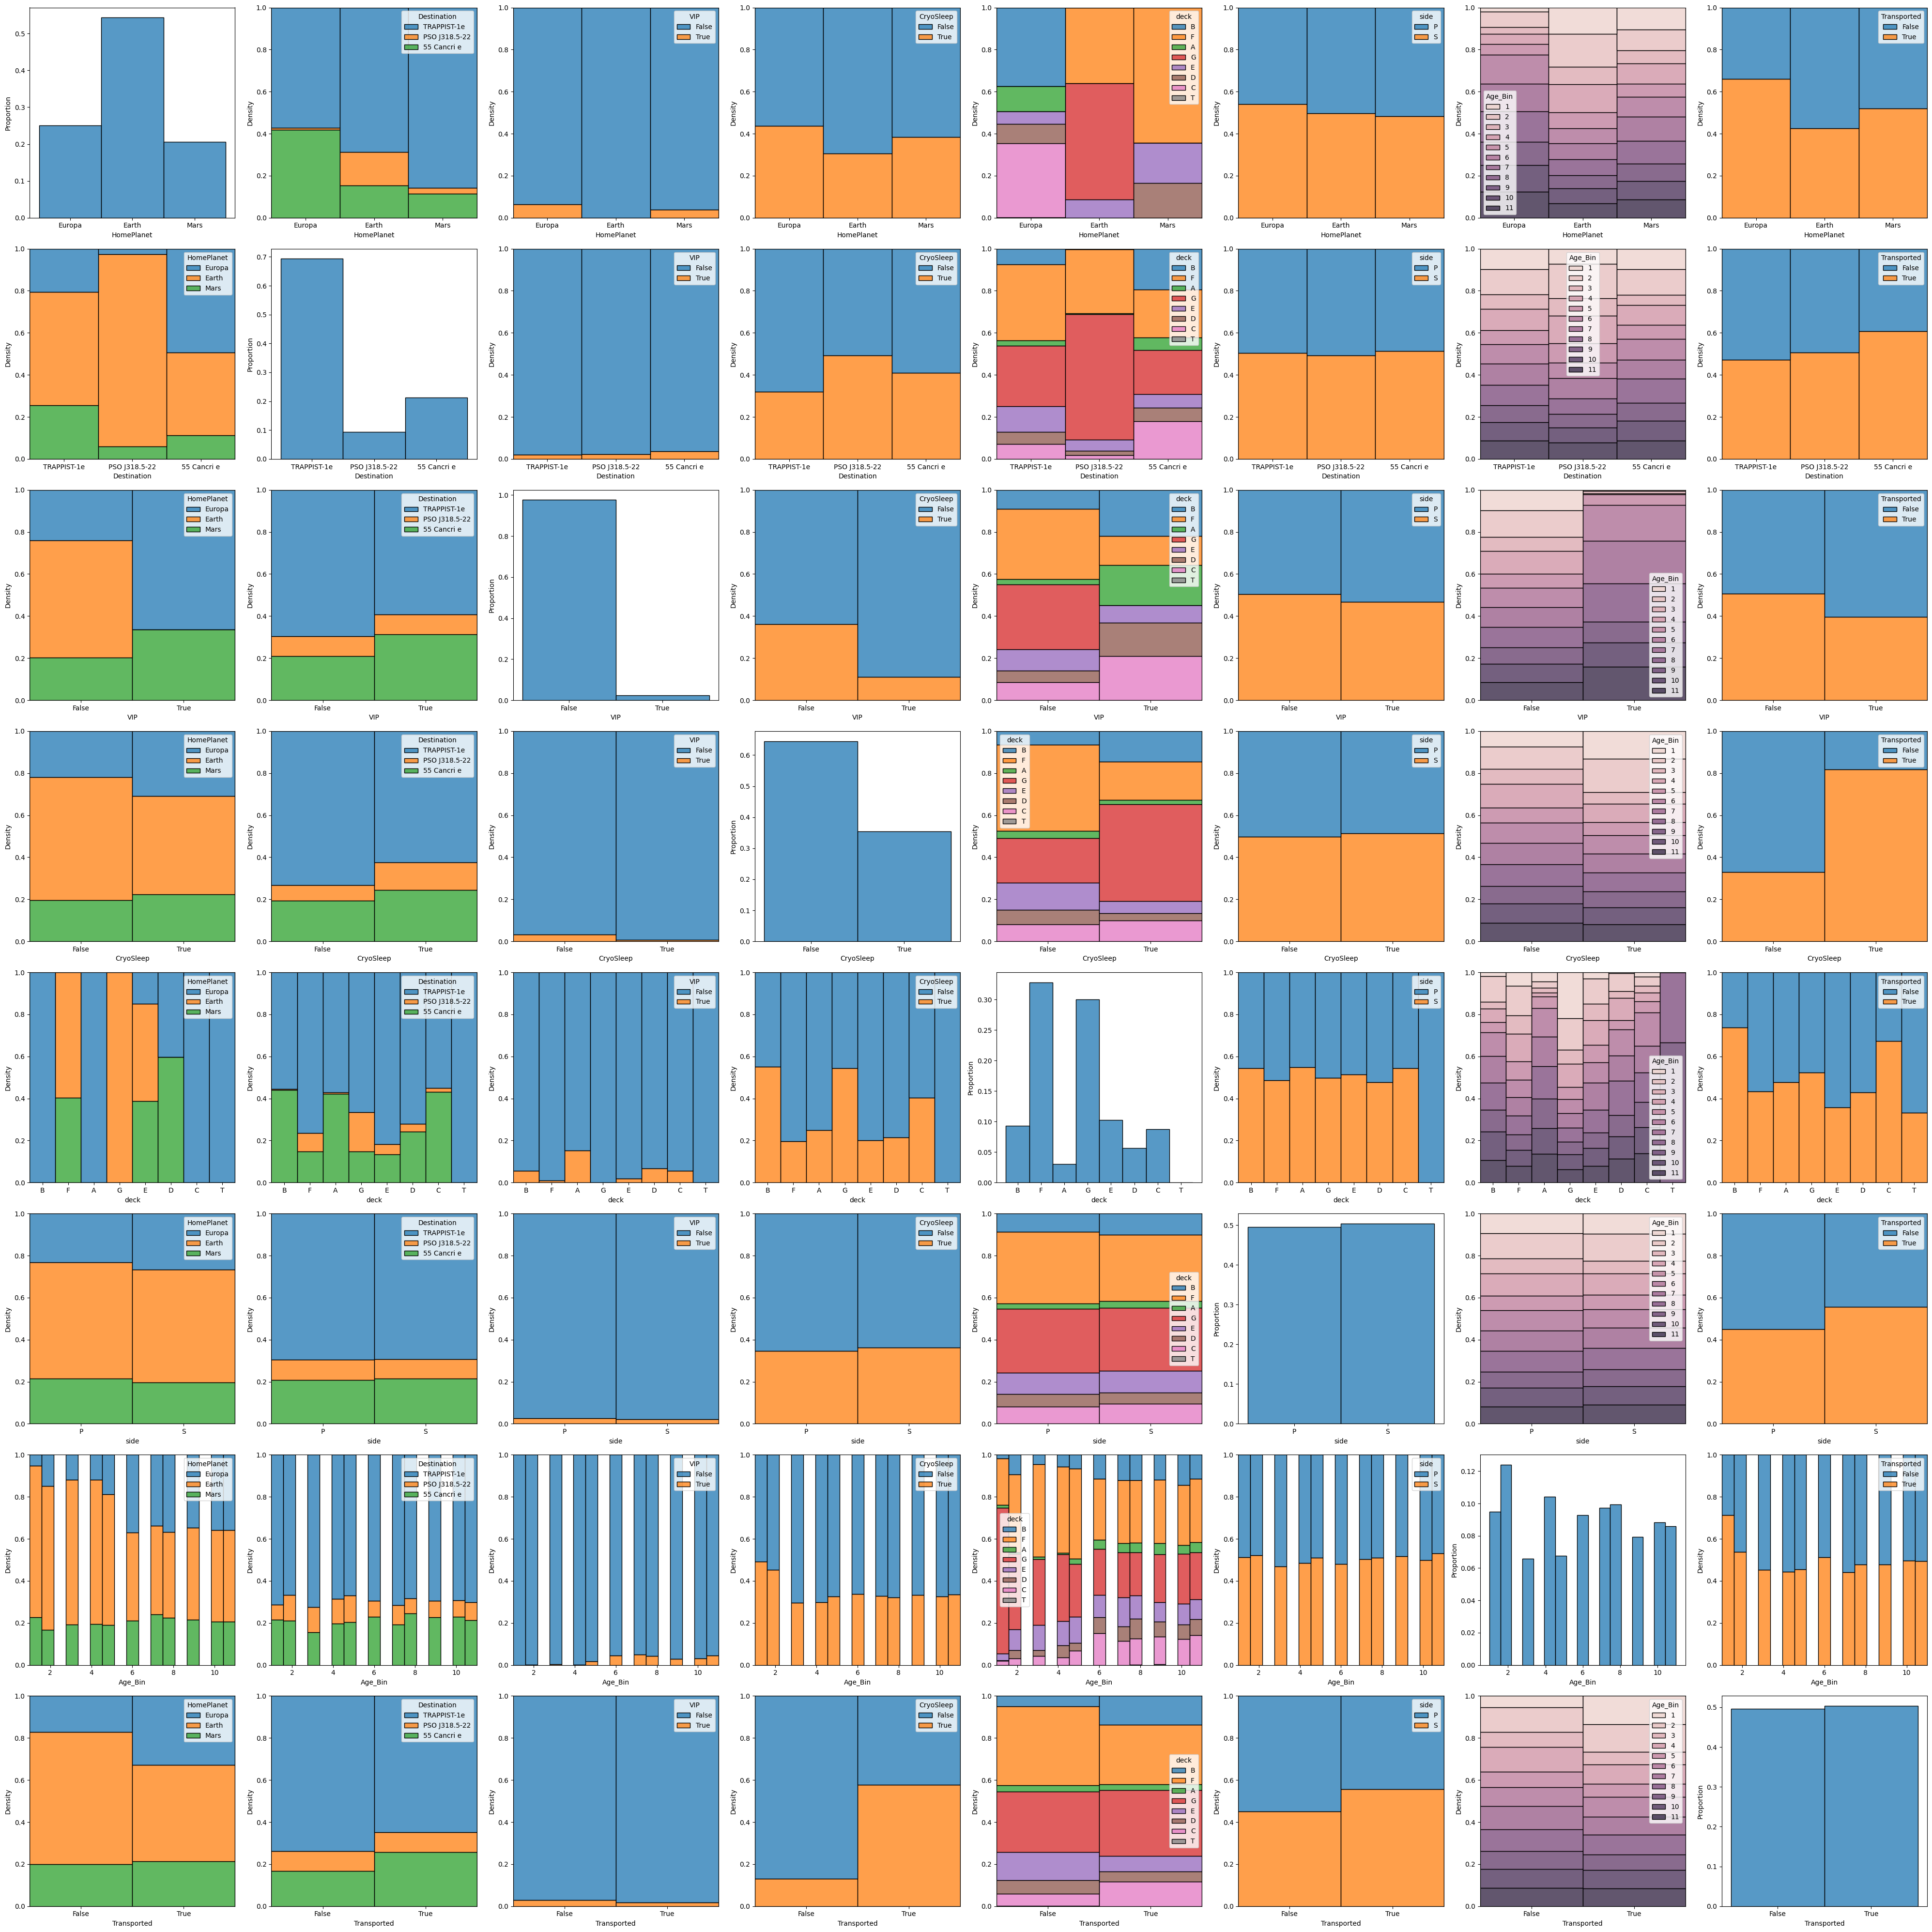

In [49]:
Gridplot_Hists(df2, Categorical_Features + ['Transported'])

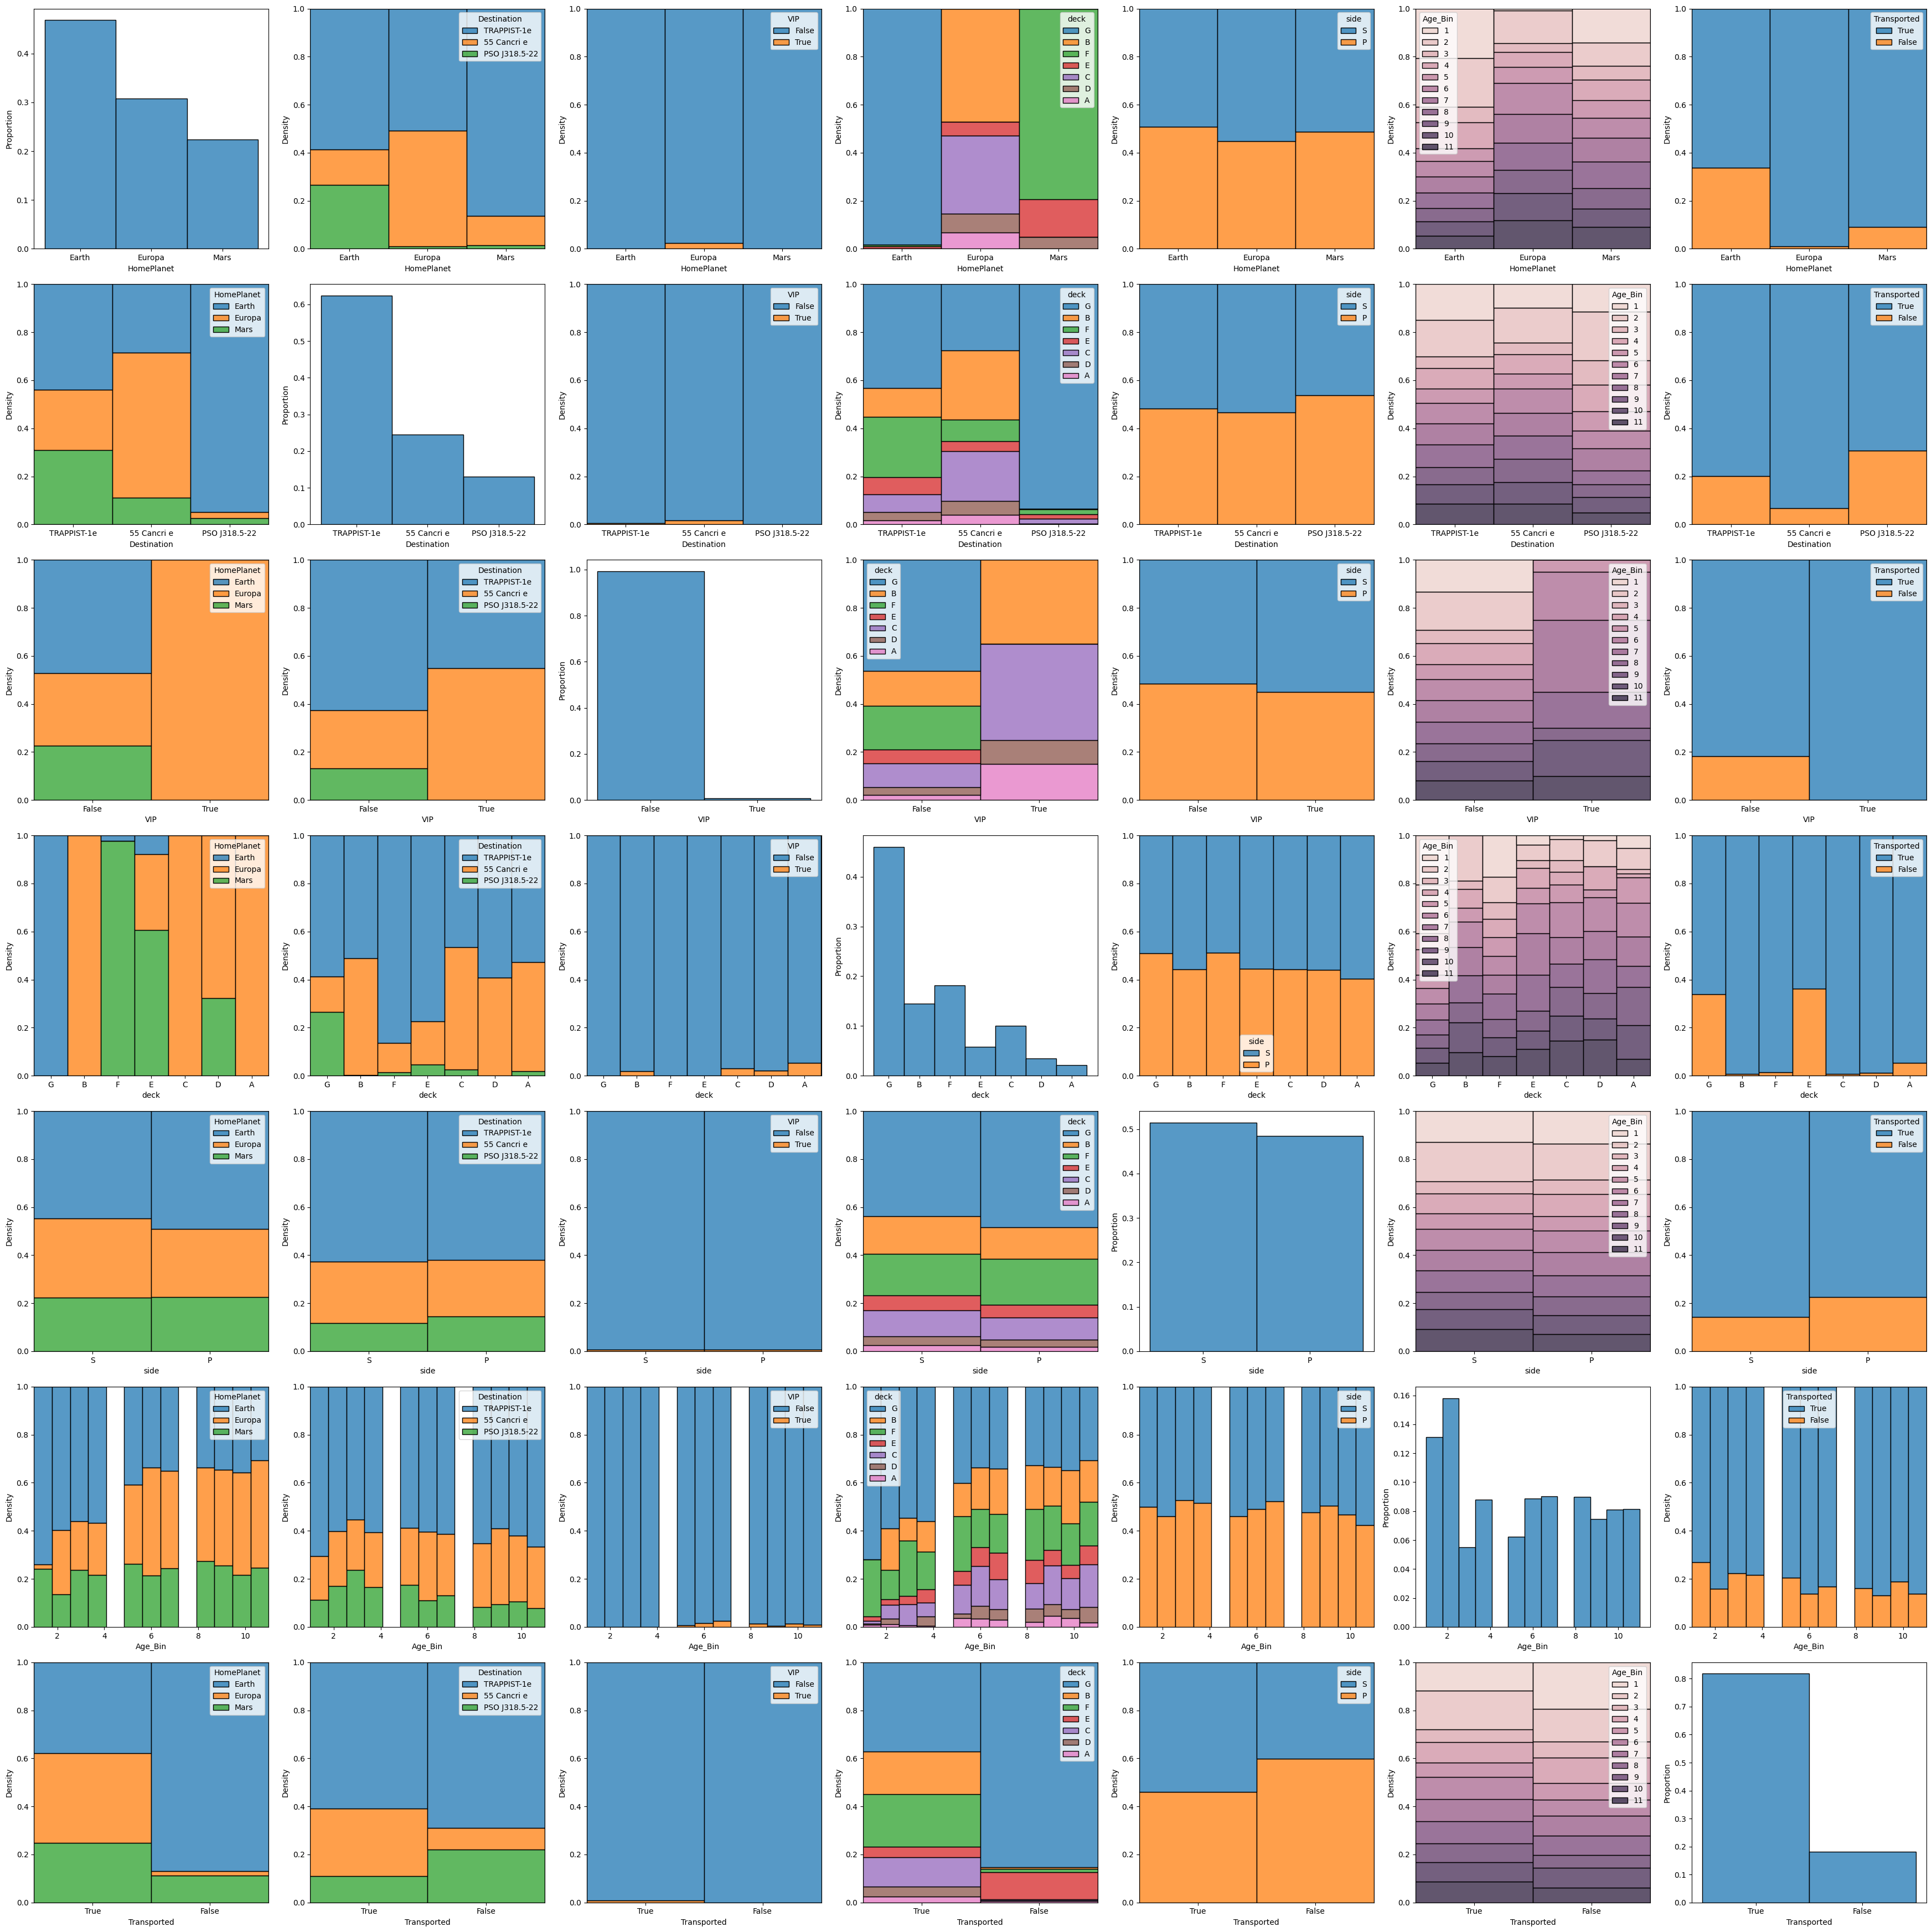

In [50]:
Gridplot_Hists(df2[df2.CryoSleep == True], [c for c in Categorical_Features if c != 'CryoSleep'] + ['Transported'])

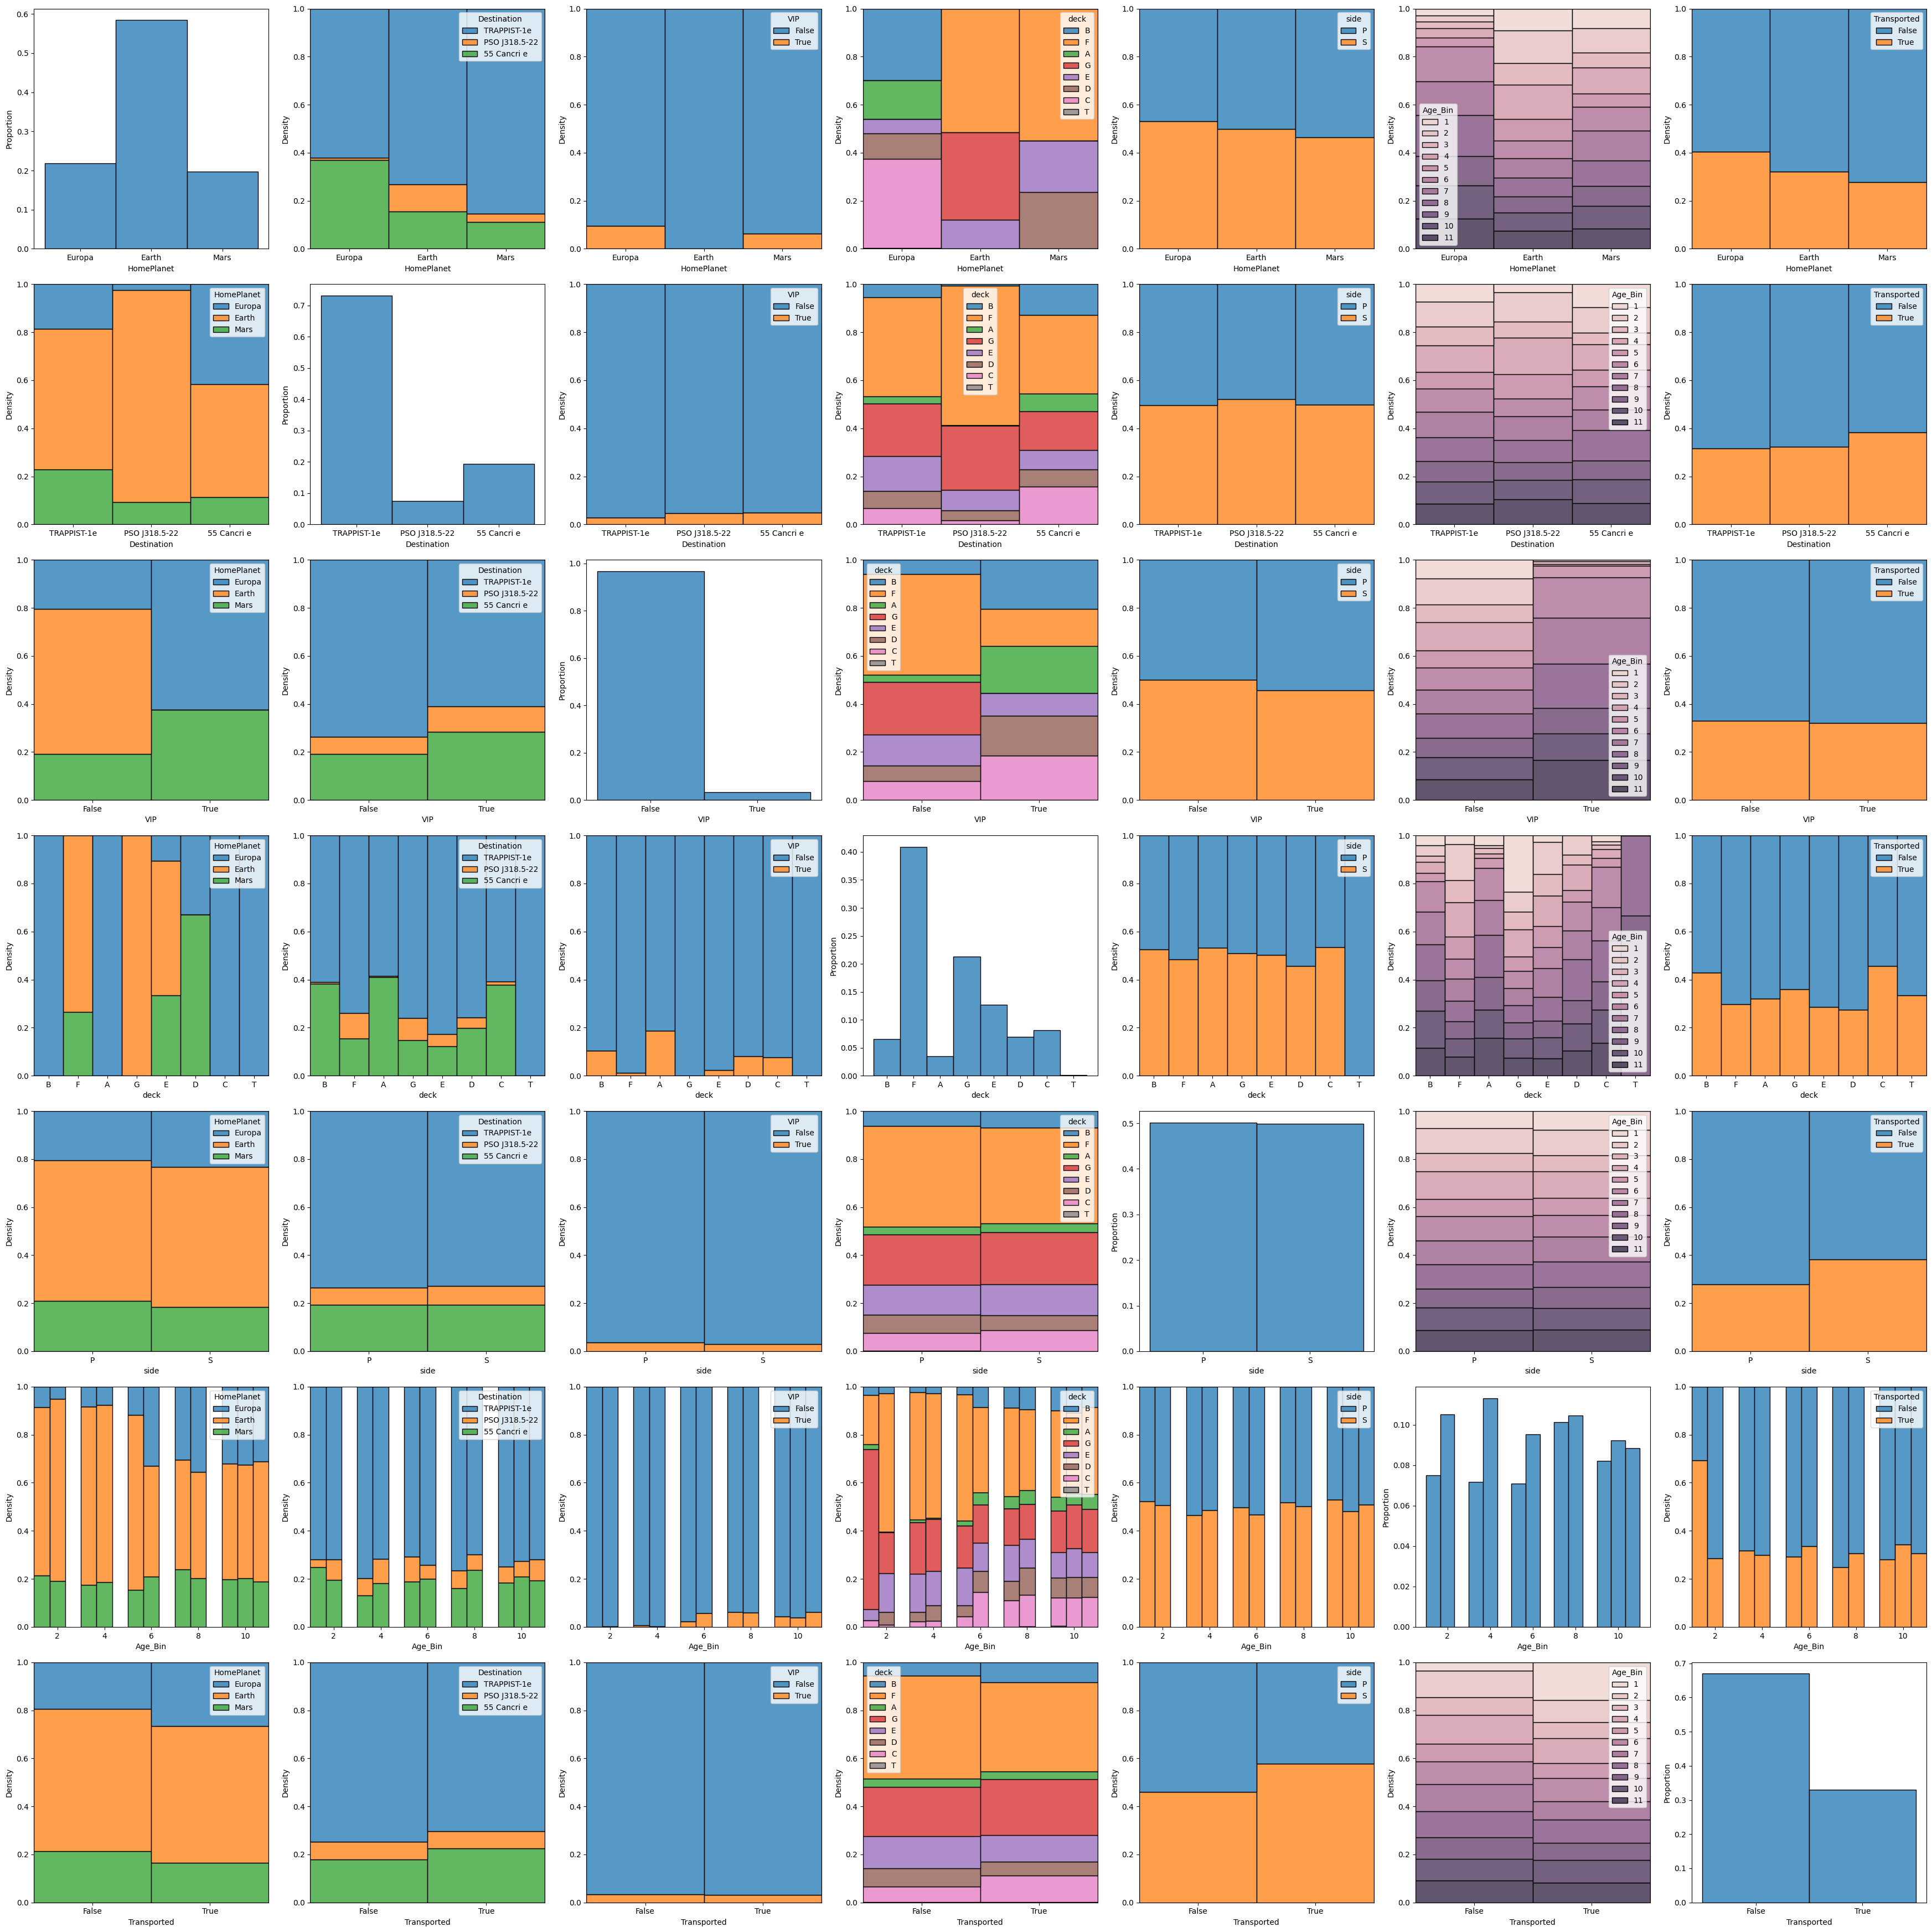

In [51]:
Gridplot_Hists(df2[df2.CryoSleep == False], [c for c in Categorical_Features if c != 'CryoSleep'] + ['Transported'])

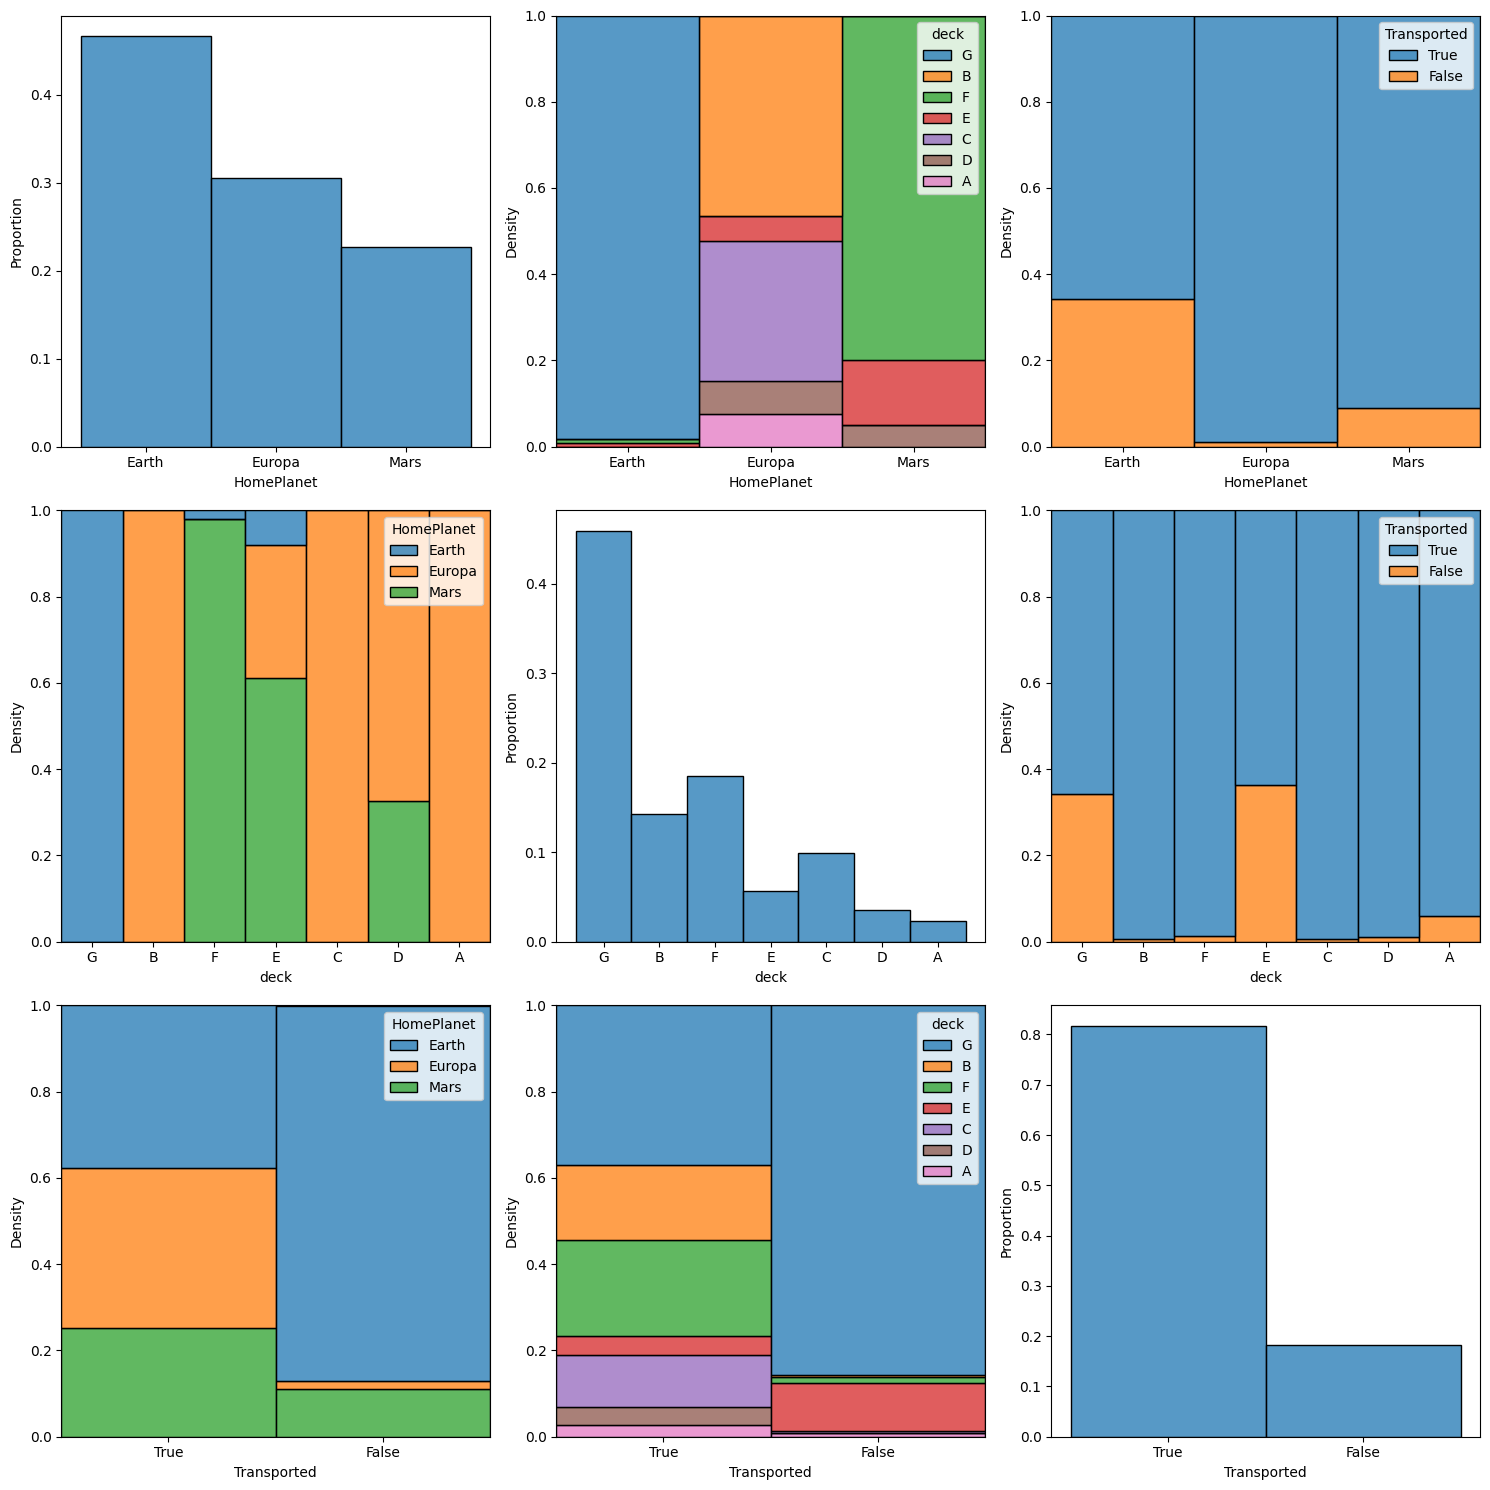

In [52]:
Gridplot_Hists(df2[df2.CryoSleep == True], ['HomePlanet', 'deck', 'Transported'])

In [53]:
df3 = df2[['HomePlanet', 'Age', 'Age_Bin', 'CryoSleep', 'deck']].dropna().copy()
for Planet in ['Earth', 'Mars', 'Europa']:
    print(Planet, len(df3[(df3.HomePlanet == Planet) & (df3.Age < 25)])/len(df3[df3.HomePlanet == Planet]), len(df3[(df3.Age < 25) & (df3.CryoSleep == True) & (df3.HomePlanet == Planet)])/len(df3[(df3.Age < 25) & (df3.HomePlanet == Planet)]))

Earth 0.5524118738404453 0.33711167086481947
Mars 0.39133089133089133 0.40717628705148207
Europa 0.18689690198070086 0.6114130434782609


In [54]:
df4 = df3[df3.CryoSleep == True]
for Planet in ['Earth', 'Mars', 'Europa']:
    print(Planet, len(df4[(df4.HomePlanet == Planet) & (df4.Age < 25)])/len(df4[df4.HomePlanet == Planet]))

Earth 0.613914373088685
Mars 0.41037735849056606
Europa 0.2619324796274738


In [55]:
len(df3[(df3.HomePlanet == 'Europa') & (df3.Age_Bin > 5)])/len(df3[df3.HomePlanet == 'Europa'])

0.7760284408329101

In [56]:
Planet = 'Earth'
for deck in ['E', 'F', 'G']:
    print(deck, len(df3[(df3.HomePlanet == Planet) & (df3.deck == deck)])/len(df3[df3.HomePlanet == Planet]), 
          len(df3[(df3.HomePlanet == Planet) & (df3.deck == deck) & (df3.CryoSleep == True)])/len(df3[(df3.HomePlanet == Planet) & (df3.CryoSleep == True)]))

E 0.08789424860853433 0.009174311926605505
F 0.3608534322820037 0.008409785932721712
G 0.5512523191094619 0.9824159021406728


In [57]:
Planet = 'Mars'
for deck in ['D', 'E', 'F']:
    print(deck, len(df3[(df3.HomePlanet == Planet) & (df3.deck == deck)])/len(df3[df3.HomePlanet == Planet]), 
          len(df3[(df3.HomePlanet == Planet) & (df3.deck == deck) & (df3.CryoSleep == True)])/len(df3[(df3.HomePlanet == Planet) & (df3.CryoSleep == True)]))

D 0.16544566544566544 0.04874213836477988
E 0.19108669108669107 0.15251572327044025
F 0.6434676434676435 0.7987421383647799


In [58]:
Planet = 'Europa'
for deck in ['A', 'B', 'C', 'D', 'E', 'T']:
    print(deck, len(df3[(df3.HomePlanet == Planet) & (df3.deck == deck)])/len(df3[df3.HomePlanet == Planet]), 
          len(df3[(df3.HomePlanet == Planet) & (df3.deck == deck) & (df3.CryoSleep == True)])/len(df3[(df3.HomePlanet == Planet) & (df3.CryoSleep == True)]))

A 0.12087353986795328 0.07217694994179279
B 0.3727780599288979 0.470314318975553
C 0.3534789233113255 0.3259604190919674
D 0.0898933468765871 0.07334109429569266
E 0.061452513966480445 0.05820721769499418
T 0.0015236160487557136 0.0


## Obeservations
* More than half of passengers are from Homeplanet Earth
* Passengers on deck G are all from Earth
* Passengers from Earth are on decks G (55%), F (36%), & E (9%)
* The overwhelming majority of passengers from Earth that are in CryoSleep are on deck G (~98%)
* Passengers from Mars are on decks F (64%), E (19%), & D (17%)
* The majority of passengers from Mars that are in Cryosleep are on deck F (80%) with most of the remaining on deck E (15%), and only 5% on deck D
* Passengers on decks A, B, C, T are all from Europa
* Other than decks A (12%), B (37%), C (35%), T (0.15%), passengers from Europa can also be on decks D (9%) or E (6%)
* All passengers on deck T are from Europa, Destination TRAPPIST-1e, VIP = False. There are very few passengers on deck T though.
* Passengers from Earth are less likely to be in Cryosleep than passengers from Europa and Mars, and more likely to be young (~54% og passengers from Earth are under the age of 25 while only 19% of passengers from Europa and 38% of passengers from Mars are under the age of 25. Note, however, that the Homeplanet age distribution differ by Cryosleep status. For example, among passengers in cryosleep, 64% of passengers from Earth are under the age of 25.
* Europa passengers tend to be older

In [59]:
dfc = df2[Categorical_Features + ['Transported']].dropna().copy()

binary_features = ['VIP', 'CryoSleep']
cat_features = ['HomePlanet', 'Destination', 'deck', 'side', 'Age_Bin']

dfc[binary_features] = dfc[binary_features].astype(int)

encoders = {}
for col in cat_features:
    le = LabelEncoder()
    dfc[col] = le.fit_transform(dfc[col].astype(str))
    encoders[col] = le

# encoders['HomePlanet'].inverse_transform(dfc['HomePlanet'])

In [60]:
MI_matrix, MI_matrix_T, MI_matrix_NT, MI_min, MI_max = Get_MI_Matrices(dfc, Categorical_Features, 'Transported')

,HomePlanet,Destination,VIP,CryoSleep,deck,side,Age_Bin
HomePlanet,0.000000,0.070297,0.015743,0.015573,0.647790,0.000000,0.053864
Destination,0.071083,0.000000,0.000000,0.006031,0.064418,0.008958,0.003221
VIP,0.020532,0.002606,0.000000,0.004851,0.019473,0.000000,0.010174
CryoSleep,0.008167,0.003670,0.005783,0.000000,0.056056,0.000000,0.012761
deck,0.638862,0.047613,0.019984,0.053488,0.000000,0.000000,0.070766
side,0.002134,0.002795,0.011936,0.002726,0.000462,0.000000,0.007460
Age_Bin,0.044245,0.001439,0.030831,0.018717,0.071443,0.000000,0.000000


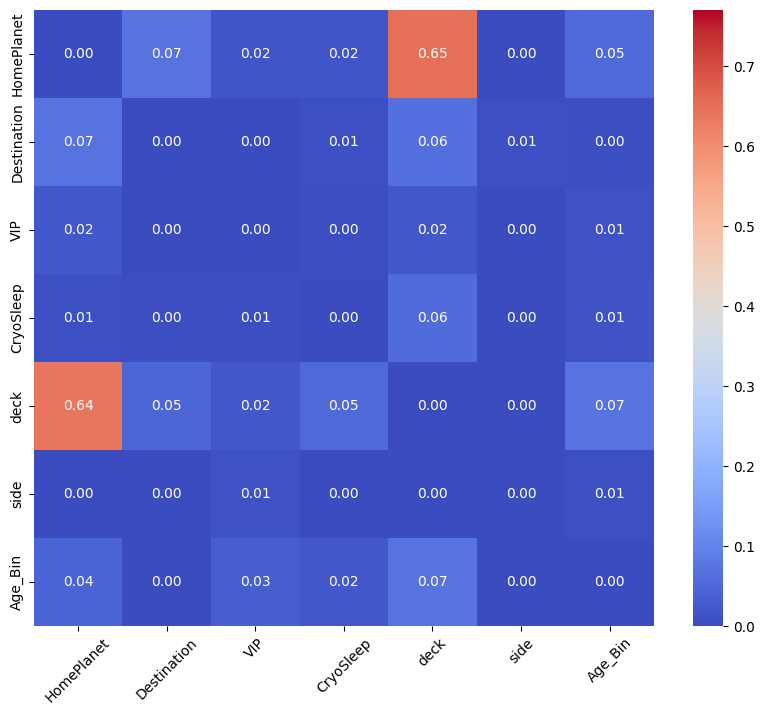

In [61]:
display(MI_matrix)
Plot_MI_Heatmap(MI_matrix, MI_min, MI_max)

,HomePlanet,Destination,VIP,CryoSleep,deck,side,Age_Bin
HomePlanet,0.000000,0.074938,0.009576,0.029171,0.752132,0.001955,0.056688
Destination,0.083559,0.000000,0.000000,0.006349,0.061804,0.003598,0.016278
VIP,0.015985,0.000000,0.000000,0.004491,0.013908,0.005125,0.010156
CryoSleep,0.010476,0.000000,0.008796,0.000000,0.028955,0.006757,0.012345
deck,0.770839,0.096292,0.017654,0.032057,0.000000,0.014255,0.059449
side,0.010335,0.000000,0.017332,0.000000,0.000000,0.000000,0.000000
Age_Bin,0.057283,0.015808,0.019358,0.053534,0.092742,0.000000,0.000000


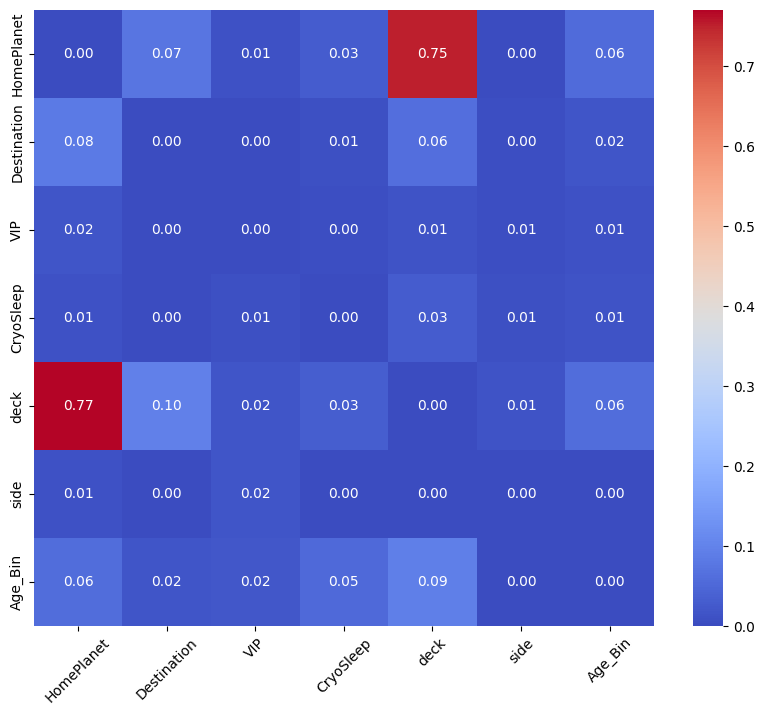

In [62]:
display(MI_matrix_T)
Plot_MI_Heatmap(MI_matrix_T, MI_min, MI_max)

,HomePlanet,Destination,VIP,CryoSleep,deck,side,Age_Bin
HomePlanet,0.000000,0.046740,0.024524,0.023304,0.535256,0.000000,0.066065
Destination,0.048171,0.000000,0.000000,0.012072,0.051638,0.013288,0.002489
VIP,0.031530,0.000000,0.000000,0.004899,0.027478,0.000000,0.010568
CryoSleep,0.029519,0.015790,0.000721,0.000000,0.120510,0.004025,0.018575
deck,0.543339,0.053404,0.020551,0.119642,0.000000,0.003733,0.089363
side,0.000000,0.002229,0.000000,0.000000,0.004591,0.000000,0.001153
Age_Bin,0.050319,0.000000,0.044574,0.000000,0.101371,0.000124,0.000000


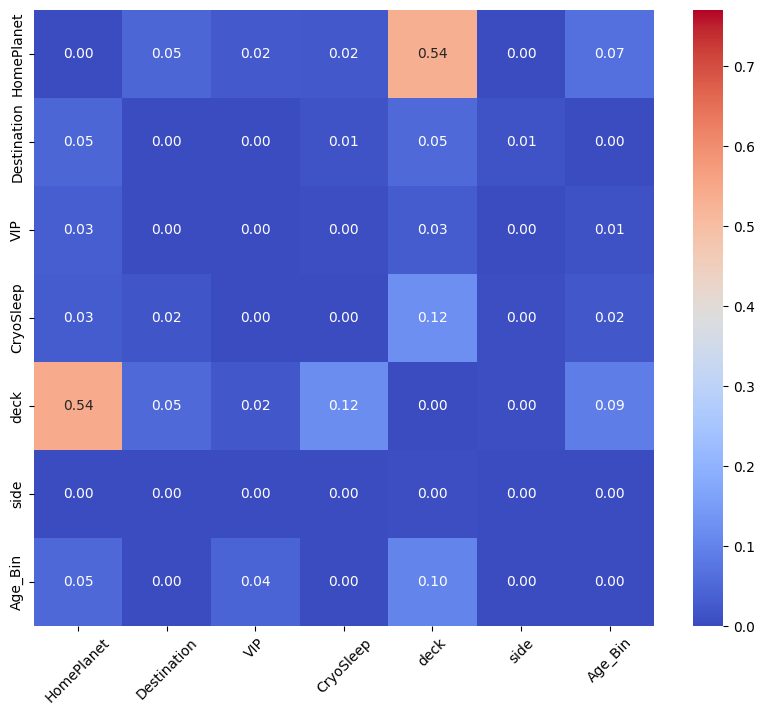

In [63]:
display(MI_matrix_NT)
Plot_MI_Heatmap(MI_matrix_NT, MI_min, MI_max)

#### Mutual Information between Categorical Variables and Target

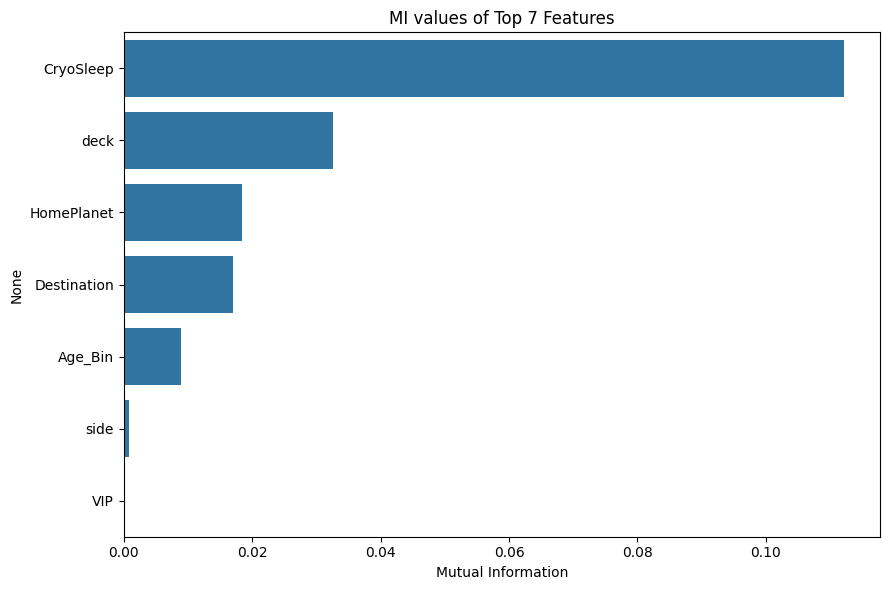

In [64]:
X = dfc.drop(columns = ['Transported'])
y = dfc['Transported']
MI = pd.Series(mutual_info_classif(X, y), index = X.columns.tolist()).sort_values(ascending = False)
Plot_MI(MI, topk = len(MI), bottom = False)

#### Since HomePlanet and deck have high mutual information, we can collate these two features into one.

In [65]:
df3 = df2[Categorical_Features + ['Transported']].dropna().copy()
df3['HomePlanet_deck'] = df3['HomePlanet'] + df3['deck']

display(df3.HomePlanet_deck.unique())

binary_features = ['VIP', 'CryoSleep']
cat_features = ['HomePlanet', 'Destination', 'deck', 'side', 'Age_Bin', 'HomePlanet_deck']

df3[binary_features] = df3[binary_features].astype(int)

for col in cat_features:
    le = LabelEncoder()
    df3[col] = le.fit_transform(df3[col].astype(str))

df3

array(['EuropaB', 'EarthF', 'EuropaA', 'EarthG', 'MarsF', 'EarthE',
       'MarsD', 'EuropaC', 'EuropaD', 'MarsE', 'EuropaE', 'EuropaT'],
      dtype=object)

,HomePlanet,Destination,VIP,CryoSleep,deck,side,Age_Bin,Transported,HomePlanet_deck
0,1,2,0,0,1,0,10,False,4
1,0,2,0,0,5,1,6,True,1
2,1,2,1,0,0,1,2,False,3
3,1,2,0,0,0,1,9,False,3
4,0,2,0,0,5,1,3,True,1
...,...,...,...,...,...,...,...,...,...
8688,1,0,1,0,0,0,10,False,3
8689,0,1,0,1,6,1,3,False,2
8690,0,2,0,0,6,1,7,True,2
8691,1,0,0,0,4,1,8,False,7


In [66]:
Categorical_Features2 = ['Destination', 'VIP', 'CryoSleep', 'side', 'Age_Bin', 'HomePlanet_deck']
MI_matrix, MI_matrix_T, MI_matrix_NT, MI_min, MI_max = Get_MI_Matrices(df3, Categorical_Features2, 'Transported')

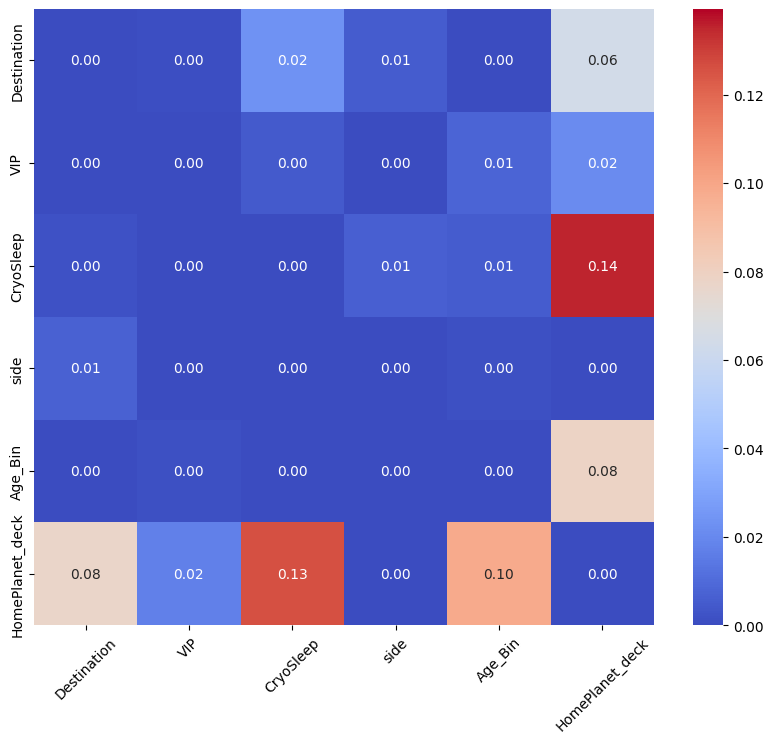

In [67]:
Plot_MI_Heatmap(MI_matrix, MI_min, MI_max)

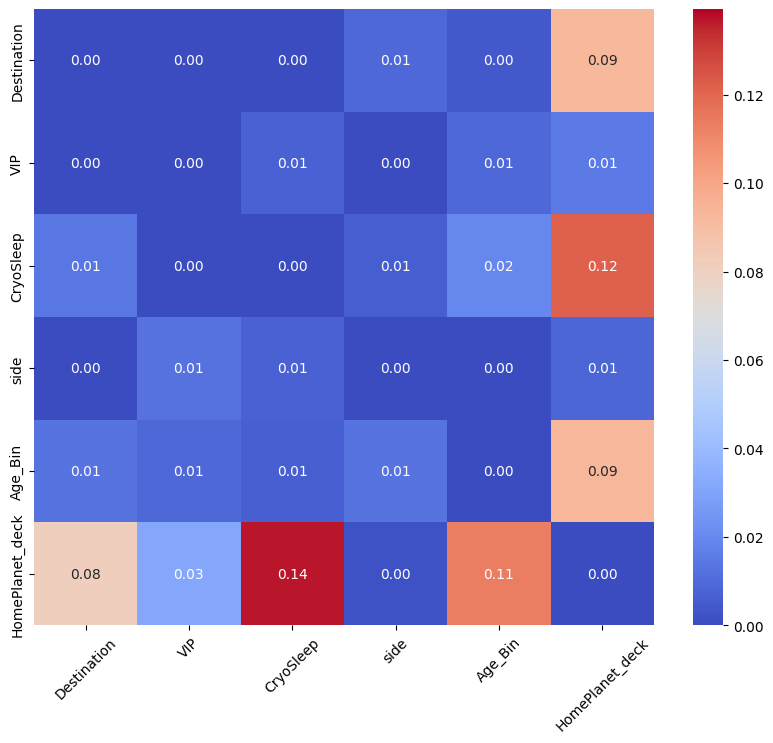

In [68]:
Plot_MI_Heatmap(MI_matrix_T, MI_min, MI_max)

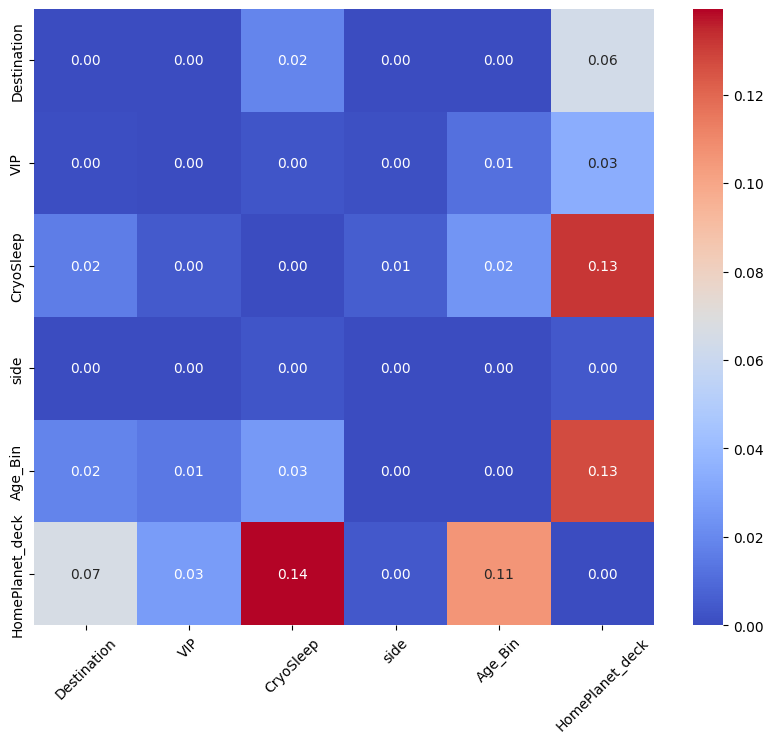

In [69]:
Plot_MI_Heatmap(MI_matrix_NT, MI_min, MI_max)

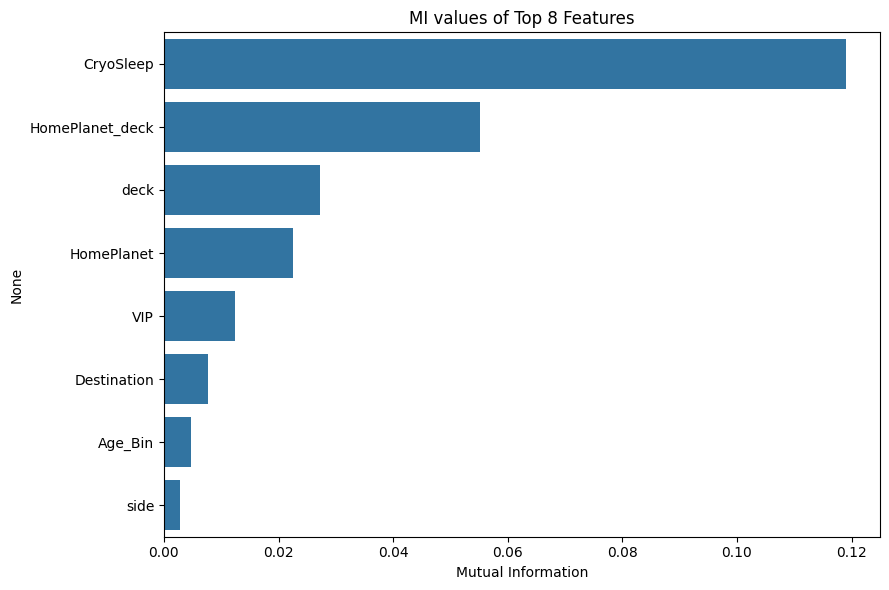

In [70]:
X = df3.drop(columns = ['Transported'])
y = df3['Transported']
MI = pd.Series(mutual_info_classif(X, y), index = X.columns.tolist()).sort_values(ascending = False)
Plot_MI(MI, topk = len(MI), bottom = False)

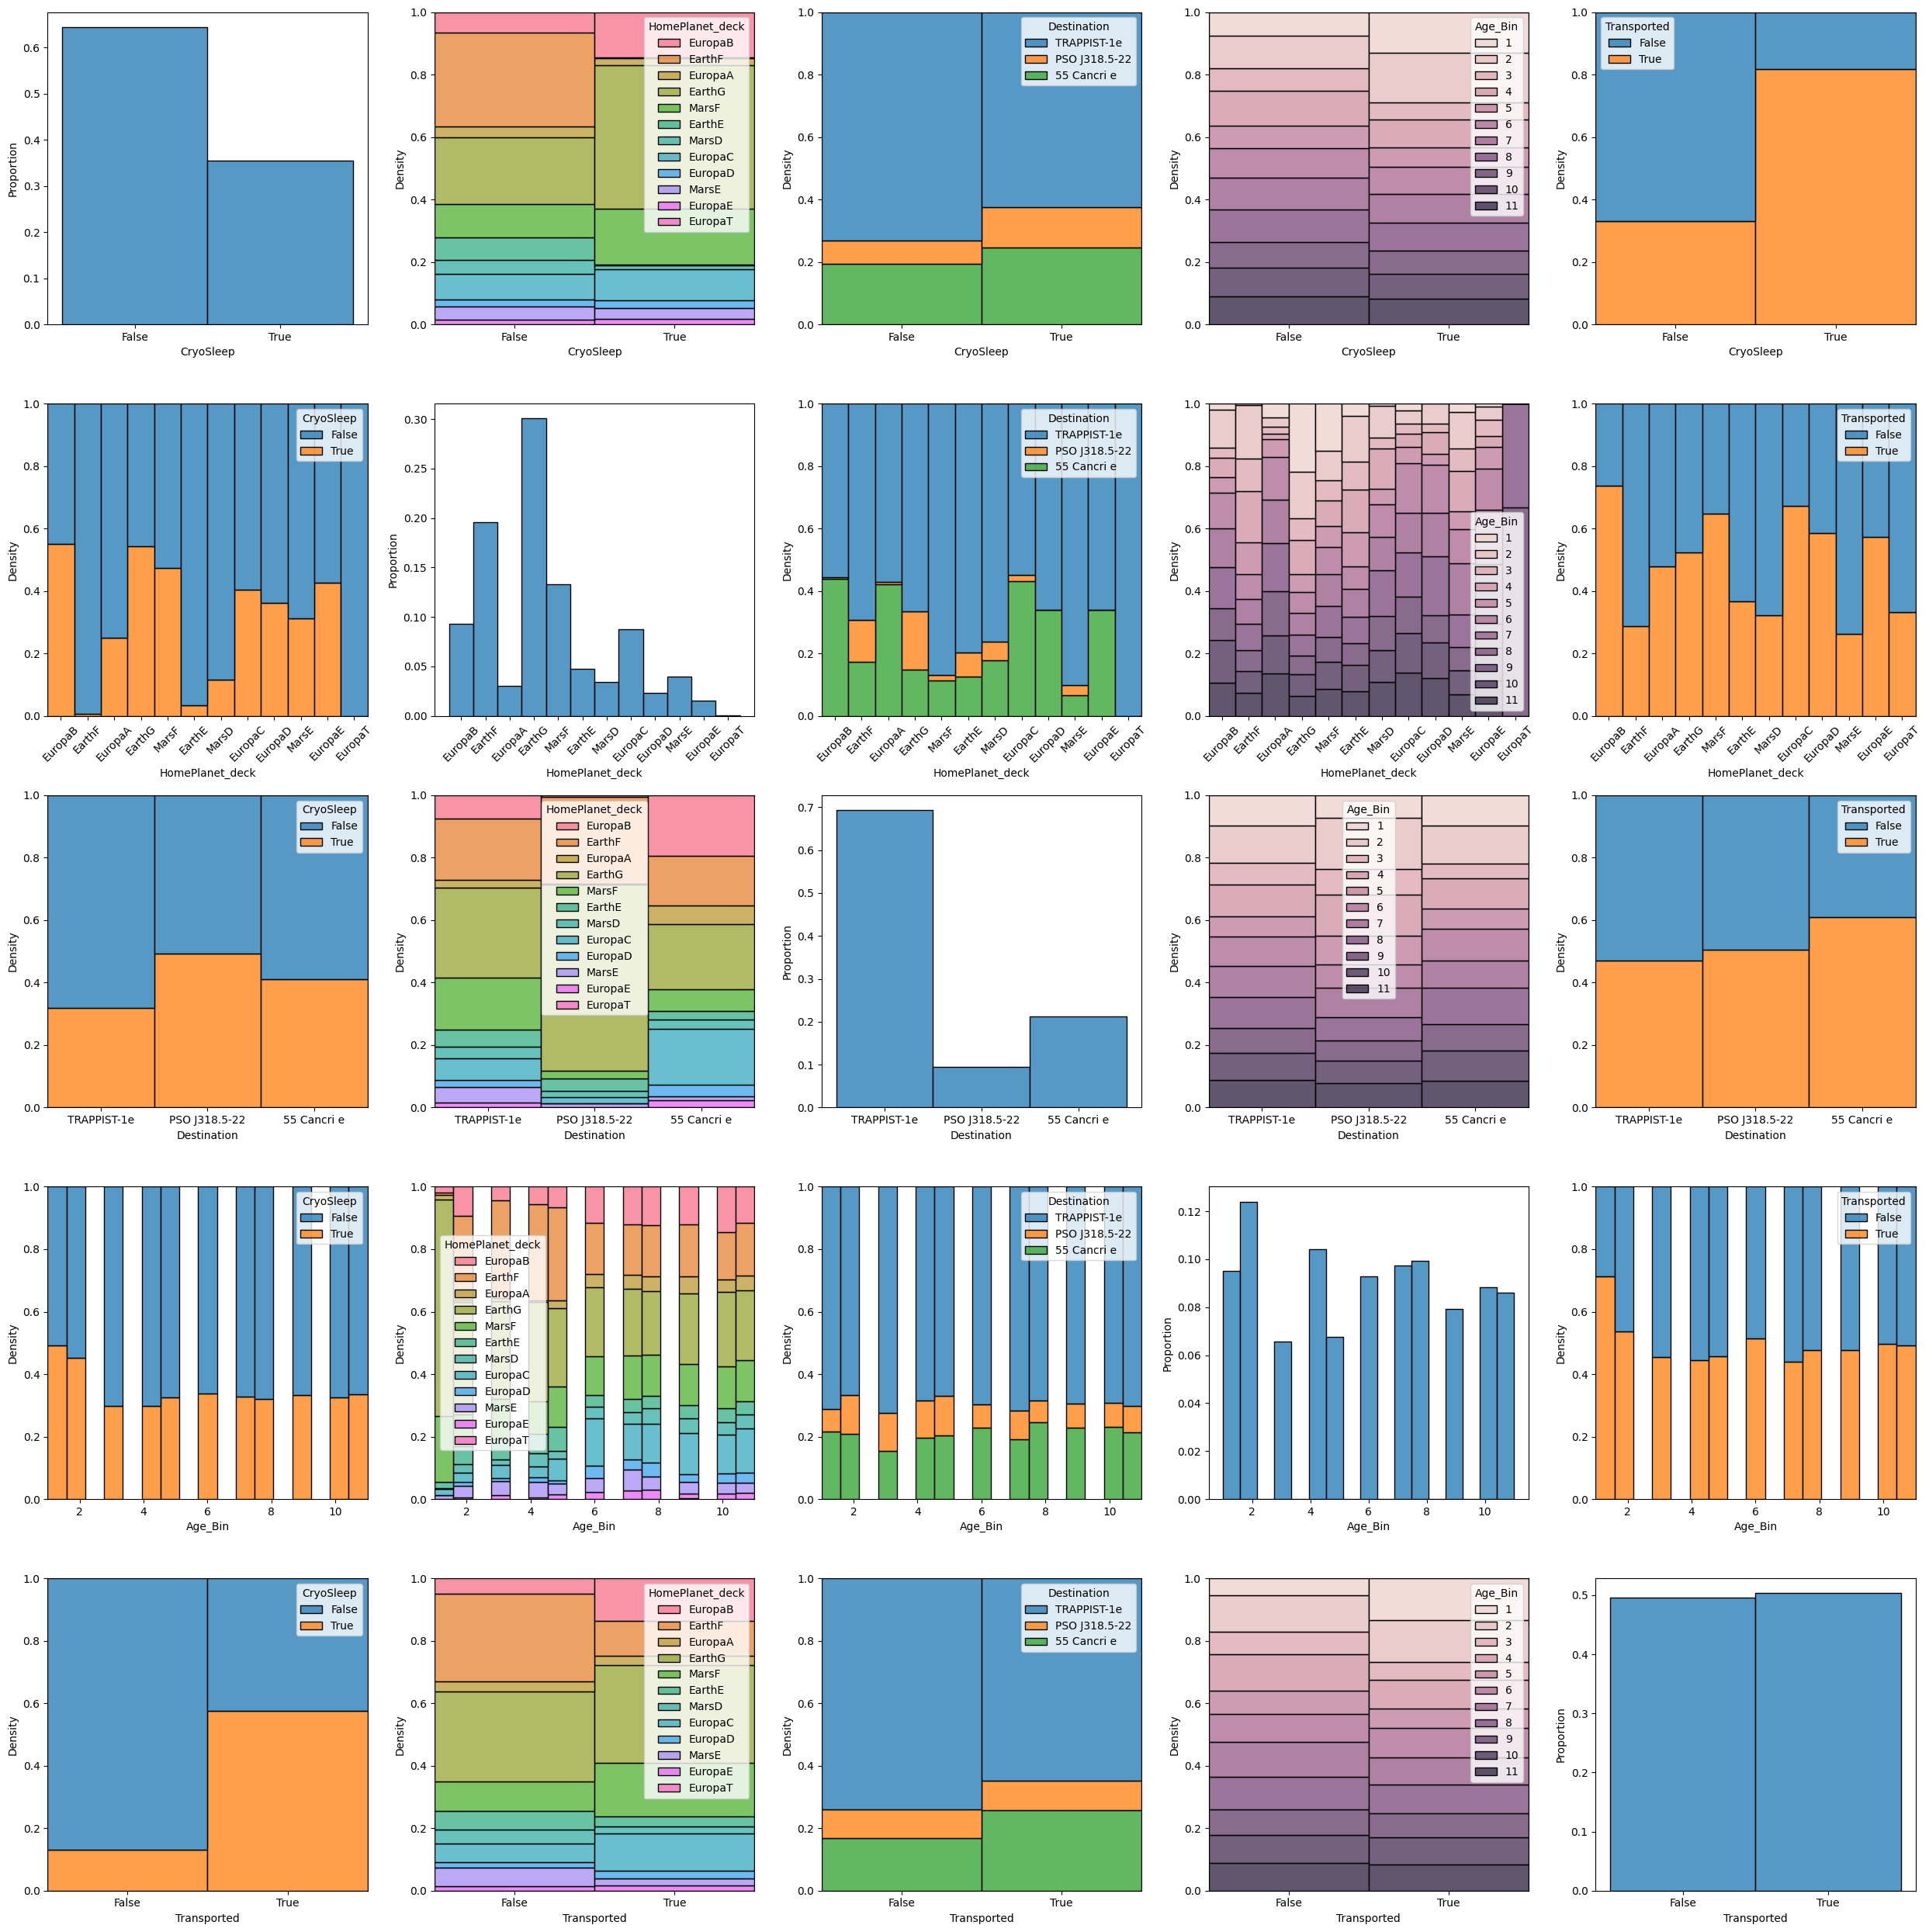

In [71]:
df4 = df2[Categorical_Features + ['Transported']].dropna().copy()
df4['HomePlanet_deck'] = df4['HomePlanet'] + df4['deck']
Gridplot_Hists(df4, ['CryoSleep', 'HomePlanet_deck', 'Destination', 'Age_Bin', 'Transported'])

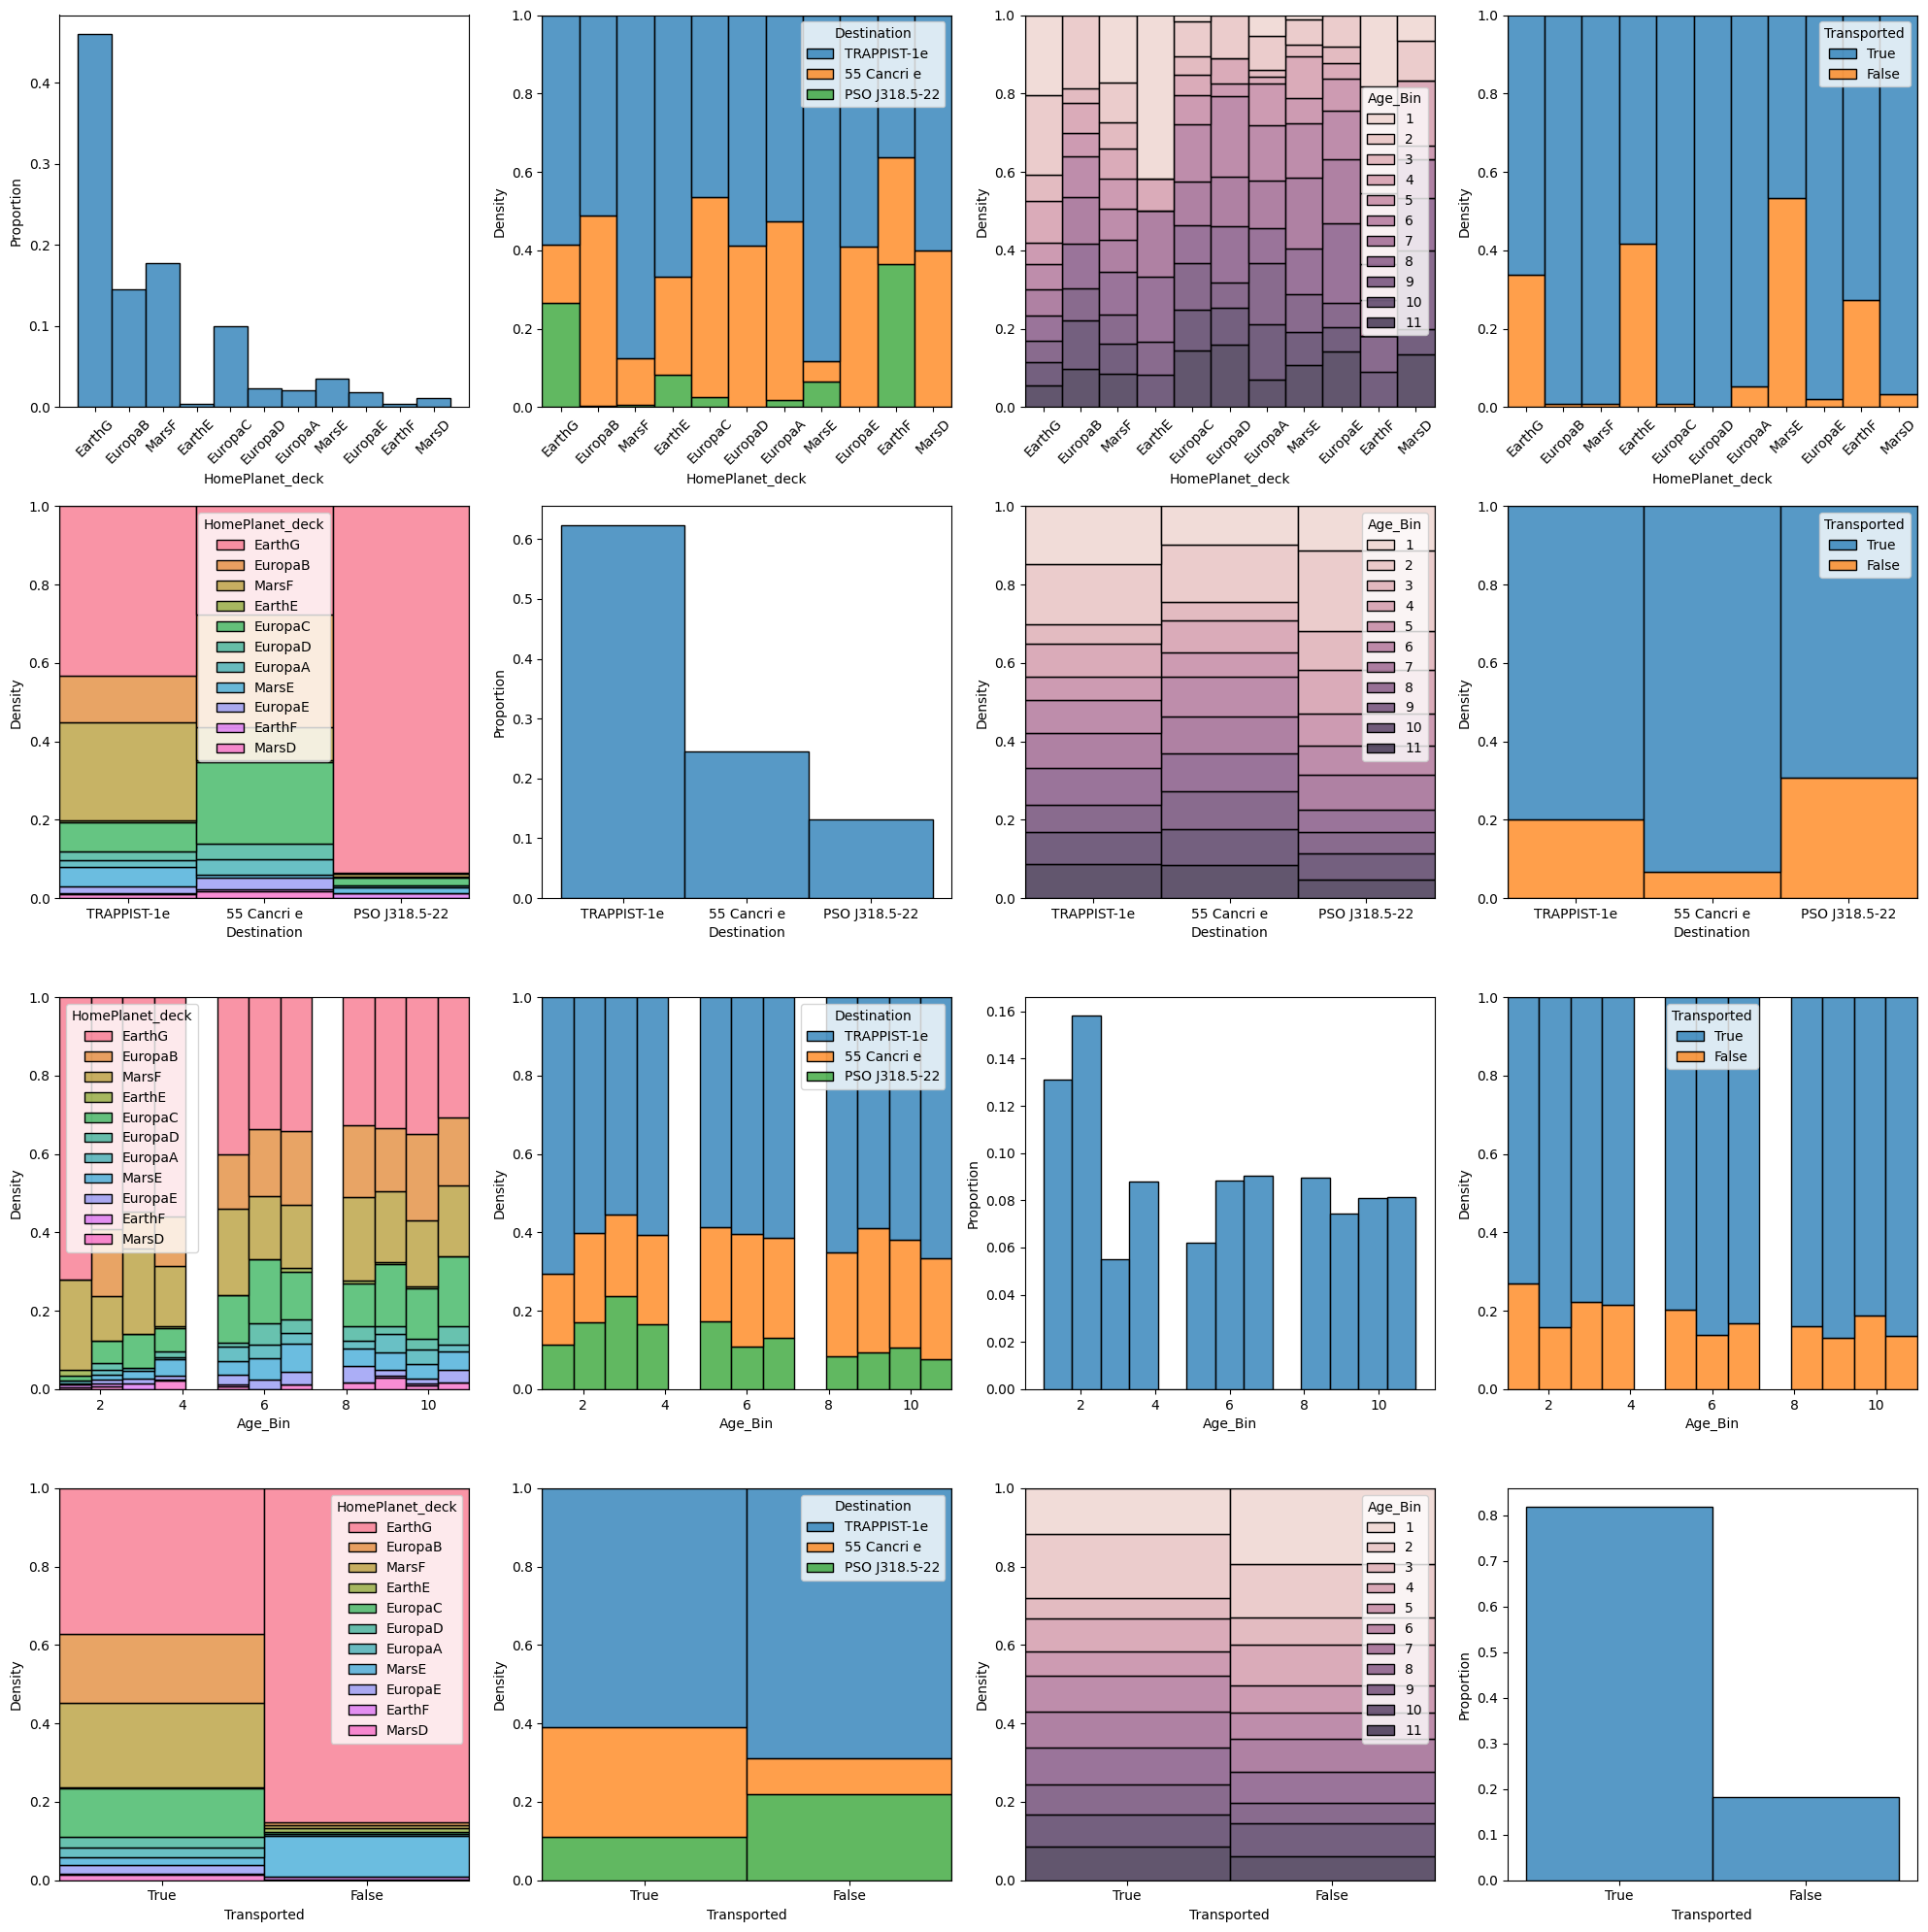

In [72]:
Gridplot_Hists(df4[df4.CryoSleep == True], ['HomePlanet_deck', 'Destination', 'Age_Bin', 'Transported'])

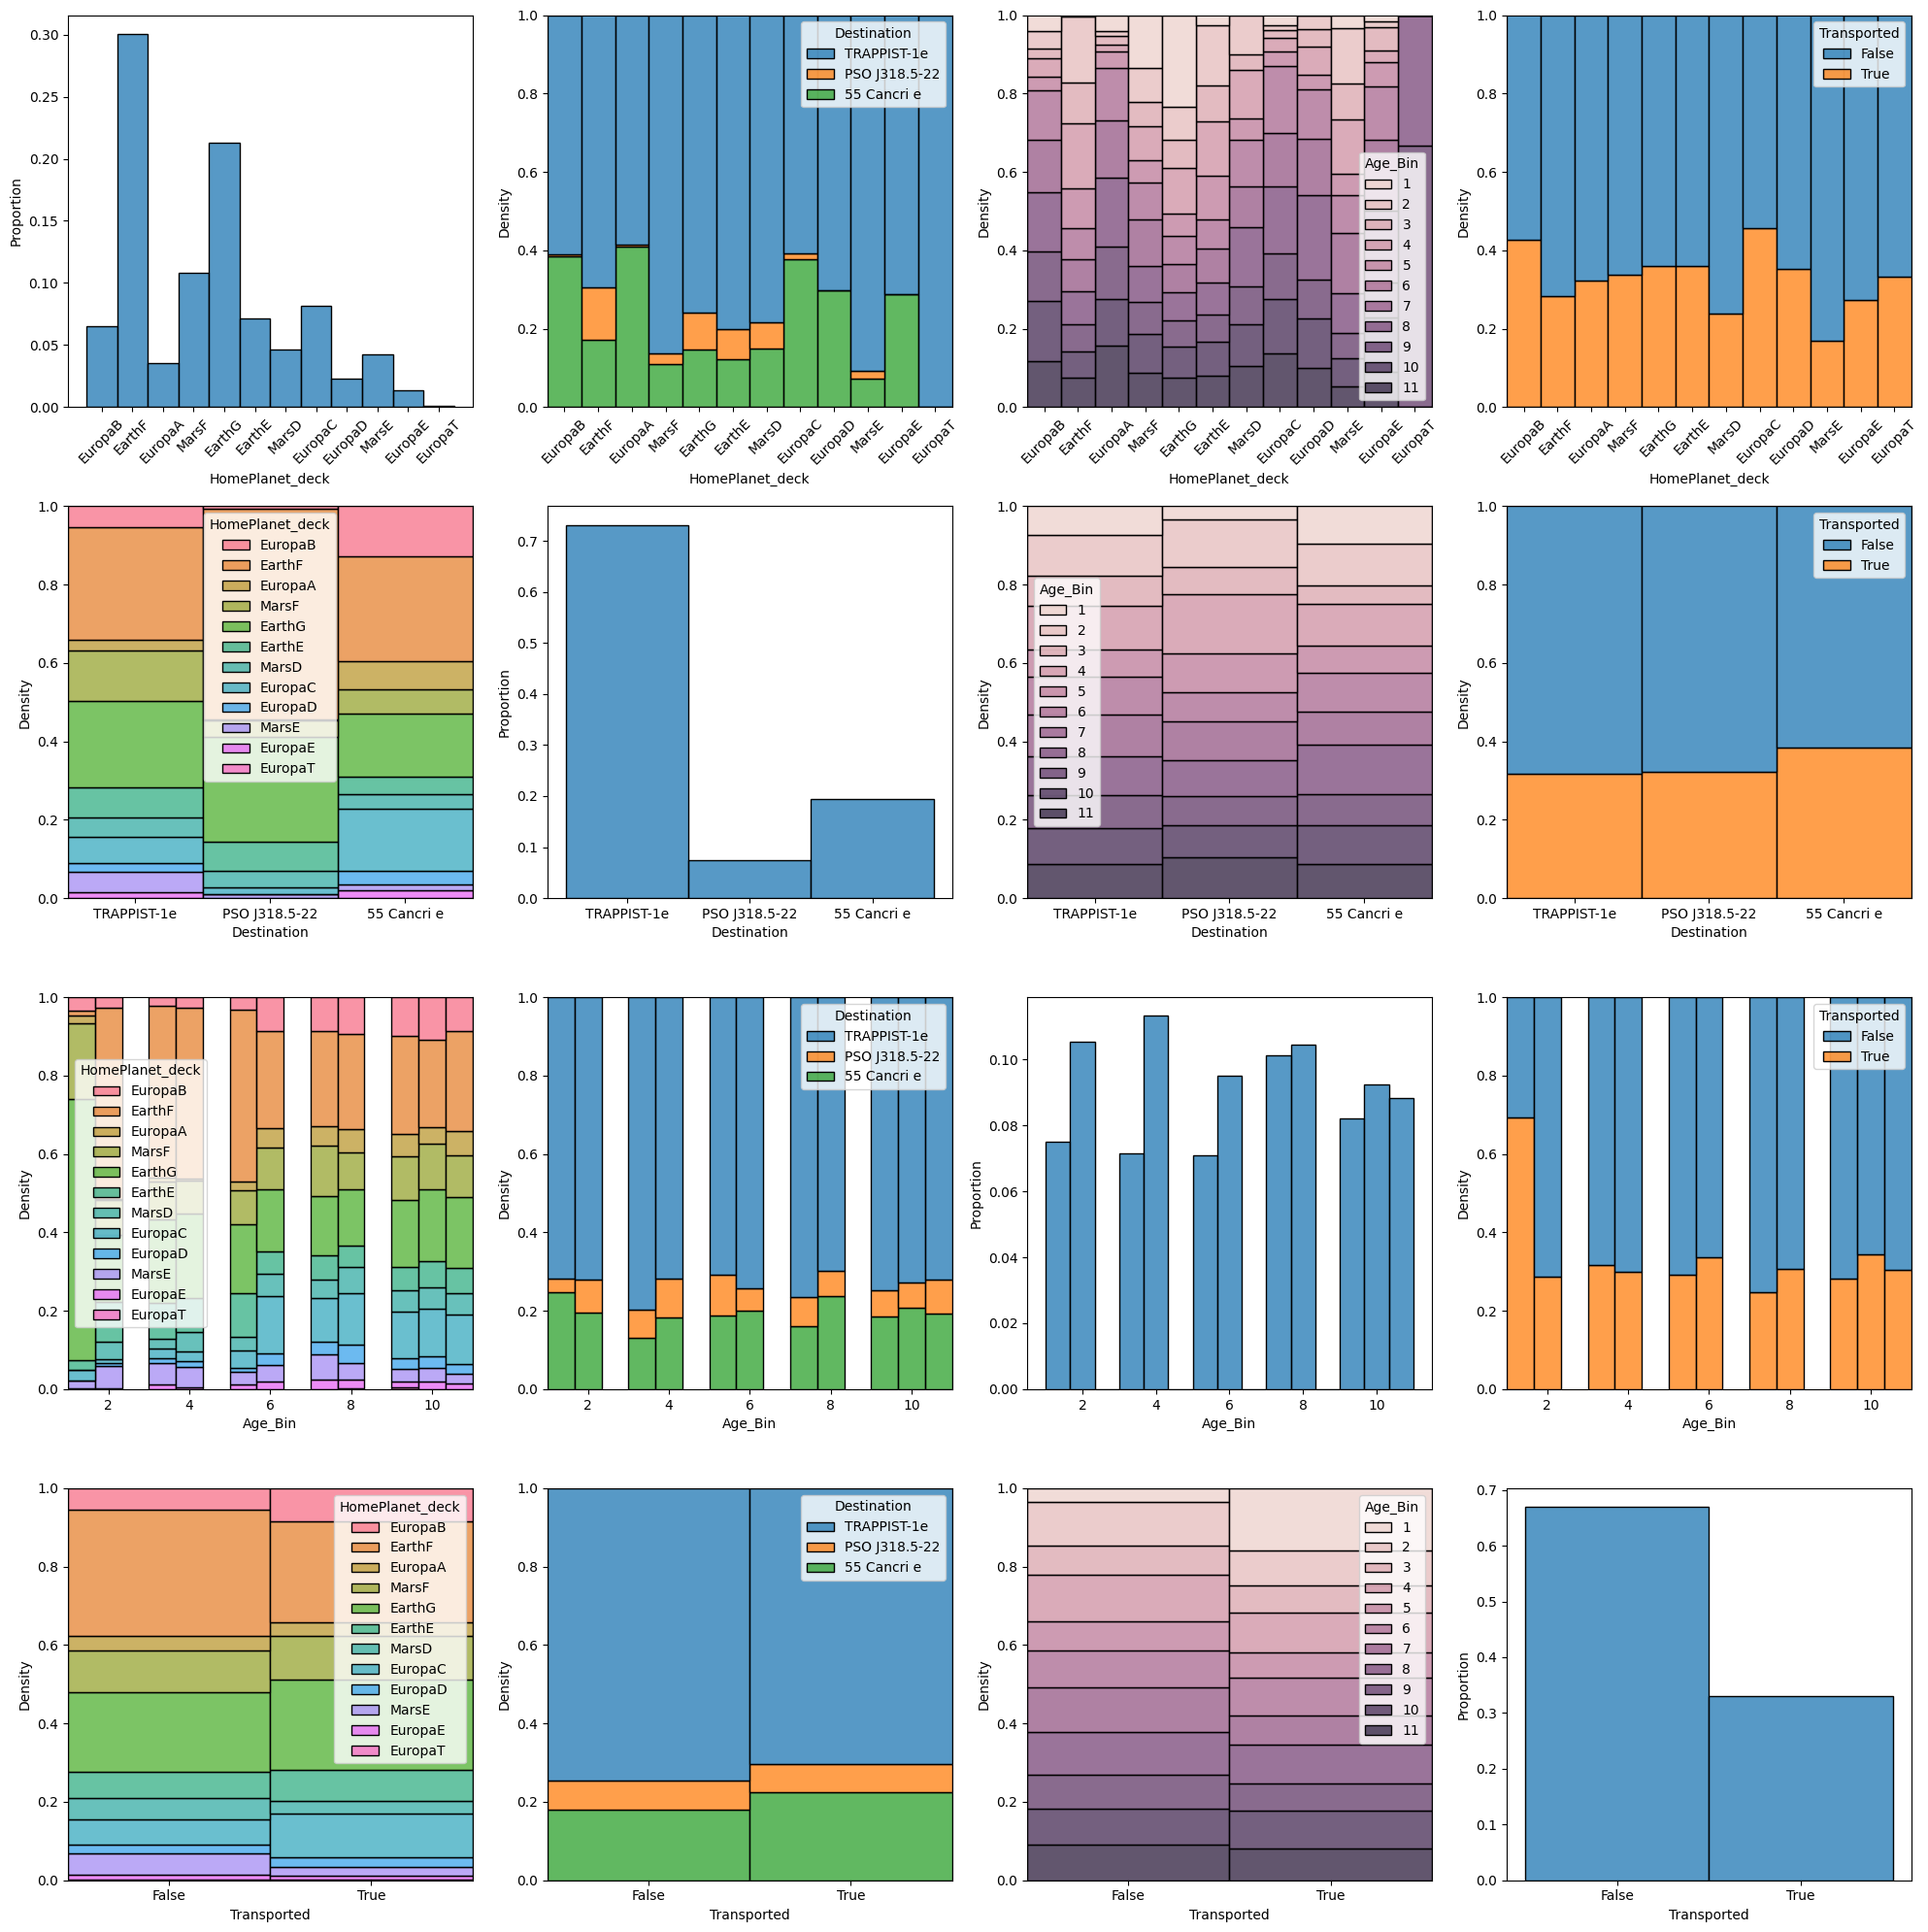

In [73]:
Gridplot_Hists(df4[df4.CryoSleep == False], ['HomePlanet_deck', 'Destination', 'Age_Bin', 'Transported'])

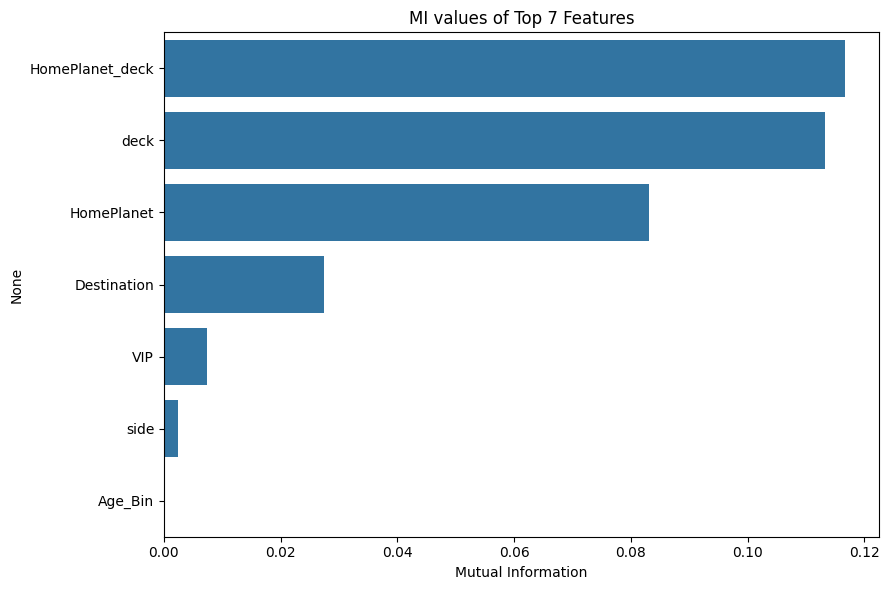

In [74]:
X = df3[df3.CryoSleep == True].drop(columns = ['Transported', 'CryoSleep'])
y = df3[df3.CryoSleep == True]['Transported']
MI = pd.Series(mutual_info_classif(X, y), index = X.columns.tolist()).sort_values(ascending = False)
Plot_MI(MI, topk = len(MI), bottom = False)

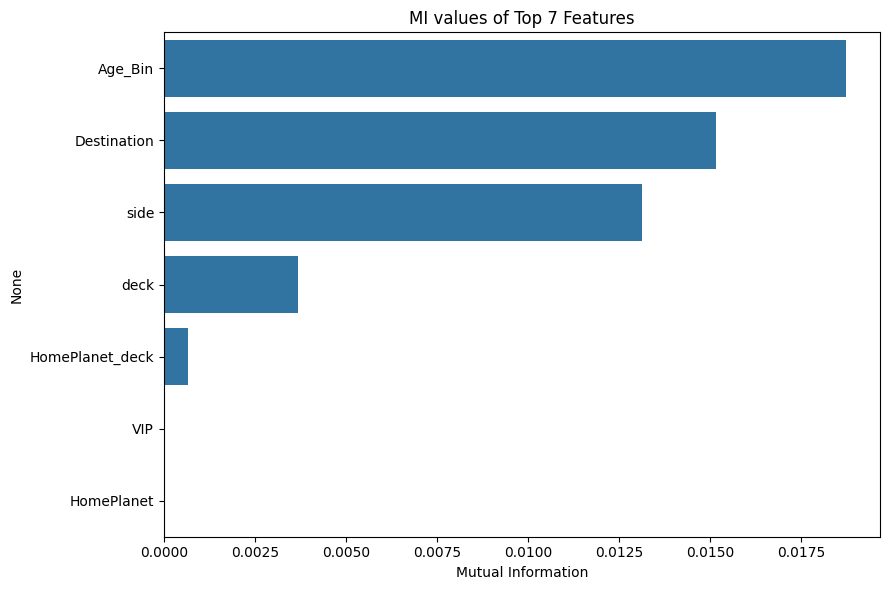

In [75]:
X = df3[df3.CryoSleep == False].drop(columns = ['Transported', 'CryoSleep'])
y = df3[df3.CryoSleep == False]['Transported']
MI = pd.Series(mutual_info_classif(X, y), index = X.columns.tolist()).sort_values(ascending = False)
Plot_MI(MI, topk = len(MI), bottom = False)

## Observations
* No passenger from Europa on decks E or D have destination PSO J318.5-22
* Passengers from Earth on deck F are extremely unlikely to be in Cryosleep
* Passengers on deck D and destination PSO J318.5-22 are all from Mars and all NOT in CryoSleep.

In [76]:
df5 = df2[['PassengerId', 'HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Age_Bin', 'deck', 'First Name', 'Last Name', 'Transported']].dropna().copy()
df5['HomePlanet_deck'] = df5['HomePlanet'] + df5['deck']
df5['FamilySize'] = df5.groupby('Last Name')['Last Name'].transform(len)
df5['FirstNameLength'] = df5['First Name'].fillna('').astype(str).apply(len)
df5['LastNameLength'] = df5['Last Name'].fillna('').astype(str).apply(len)
df5

,PassengerId,HomePlanet,Destination,CryoSleep,VIP,Age_Bin,deck,First Name,Last Name,Transported,HomePlanet_deck,FamilySize,FirstNameLength,LastNameLength
0,0001_01,Europa,TRAPPIST-1e,False,False,9,B,Maham,Ofracculy,False,EuropaB,1,5,9
1,0002_01,Earth,TRAPPIST-1e,False,False,5,F,Juanna,Vines,True,EarthF,3,6,5
2,0003_01,Europa,TRAPPIST-1e,False,True,11,A,Altark,Susent,False,EuropaA,6,6,6
3,0003_02,Europa,TRAPPIST-1e,False,False,8,A,Solam,Susent,False,EuropaA,6,5,6
4,0004_01,Earth,TRAPPIST-1e,False,False,2,F,Willy,Santantines,True,EarthF,6,5,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,55 Cancri e,False,True,9,A,Gravior,Noxnuther,False,EuropaA,2,7,9
8689,9278_01,Earth,PSO J318.5-22,True,False,2,G,Kurta,Mondalley,False,EarthG,2,5,9
8690,9279_01,Earth,TRAPPIST-1e,False,False,6,G,Fayey,Connon,True,EarthG,5,5,6
8691,9280_01,Europa,55 Cancri e,False,False,7,E,Celeon,Hontichre,False,EuropaE,4,6,9


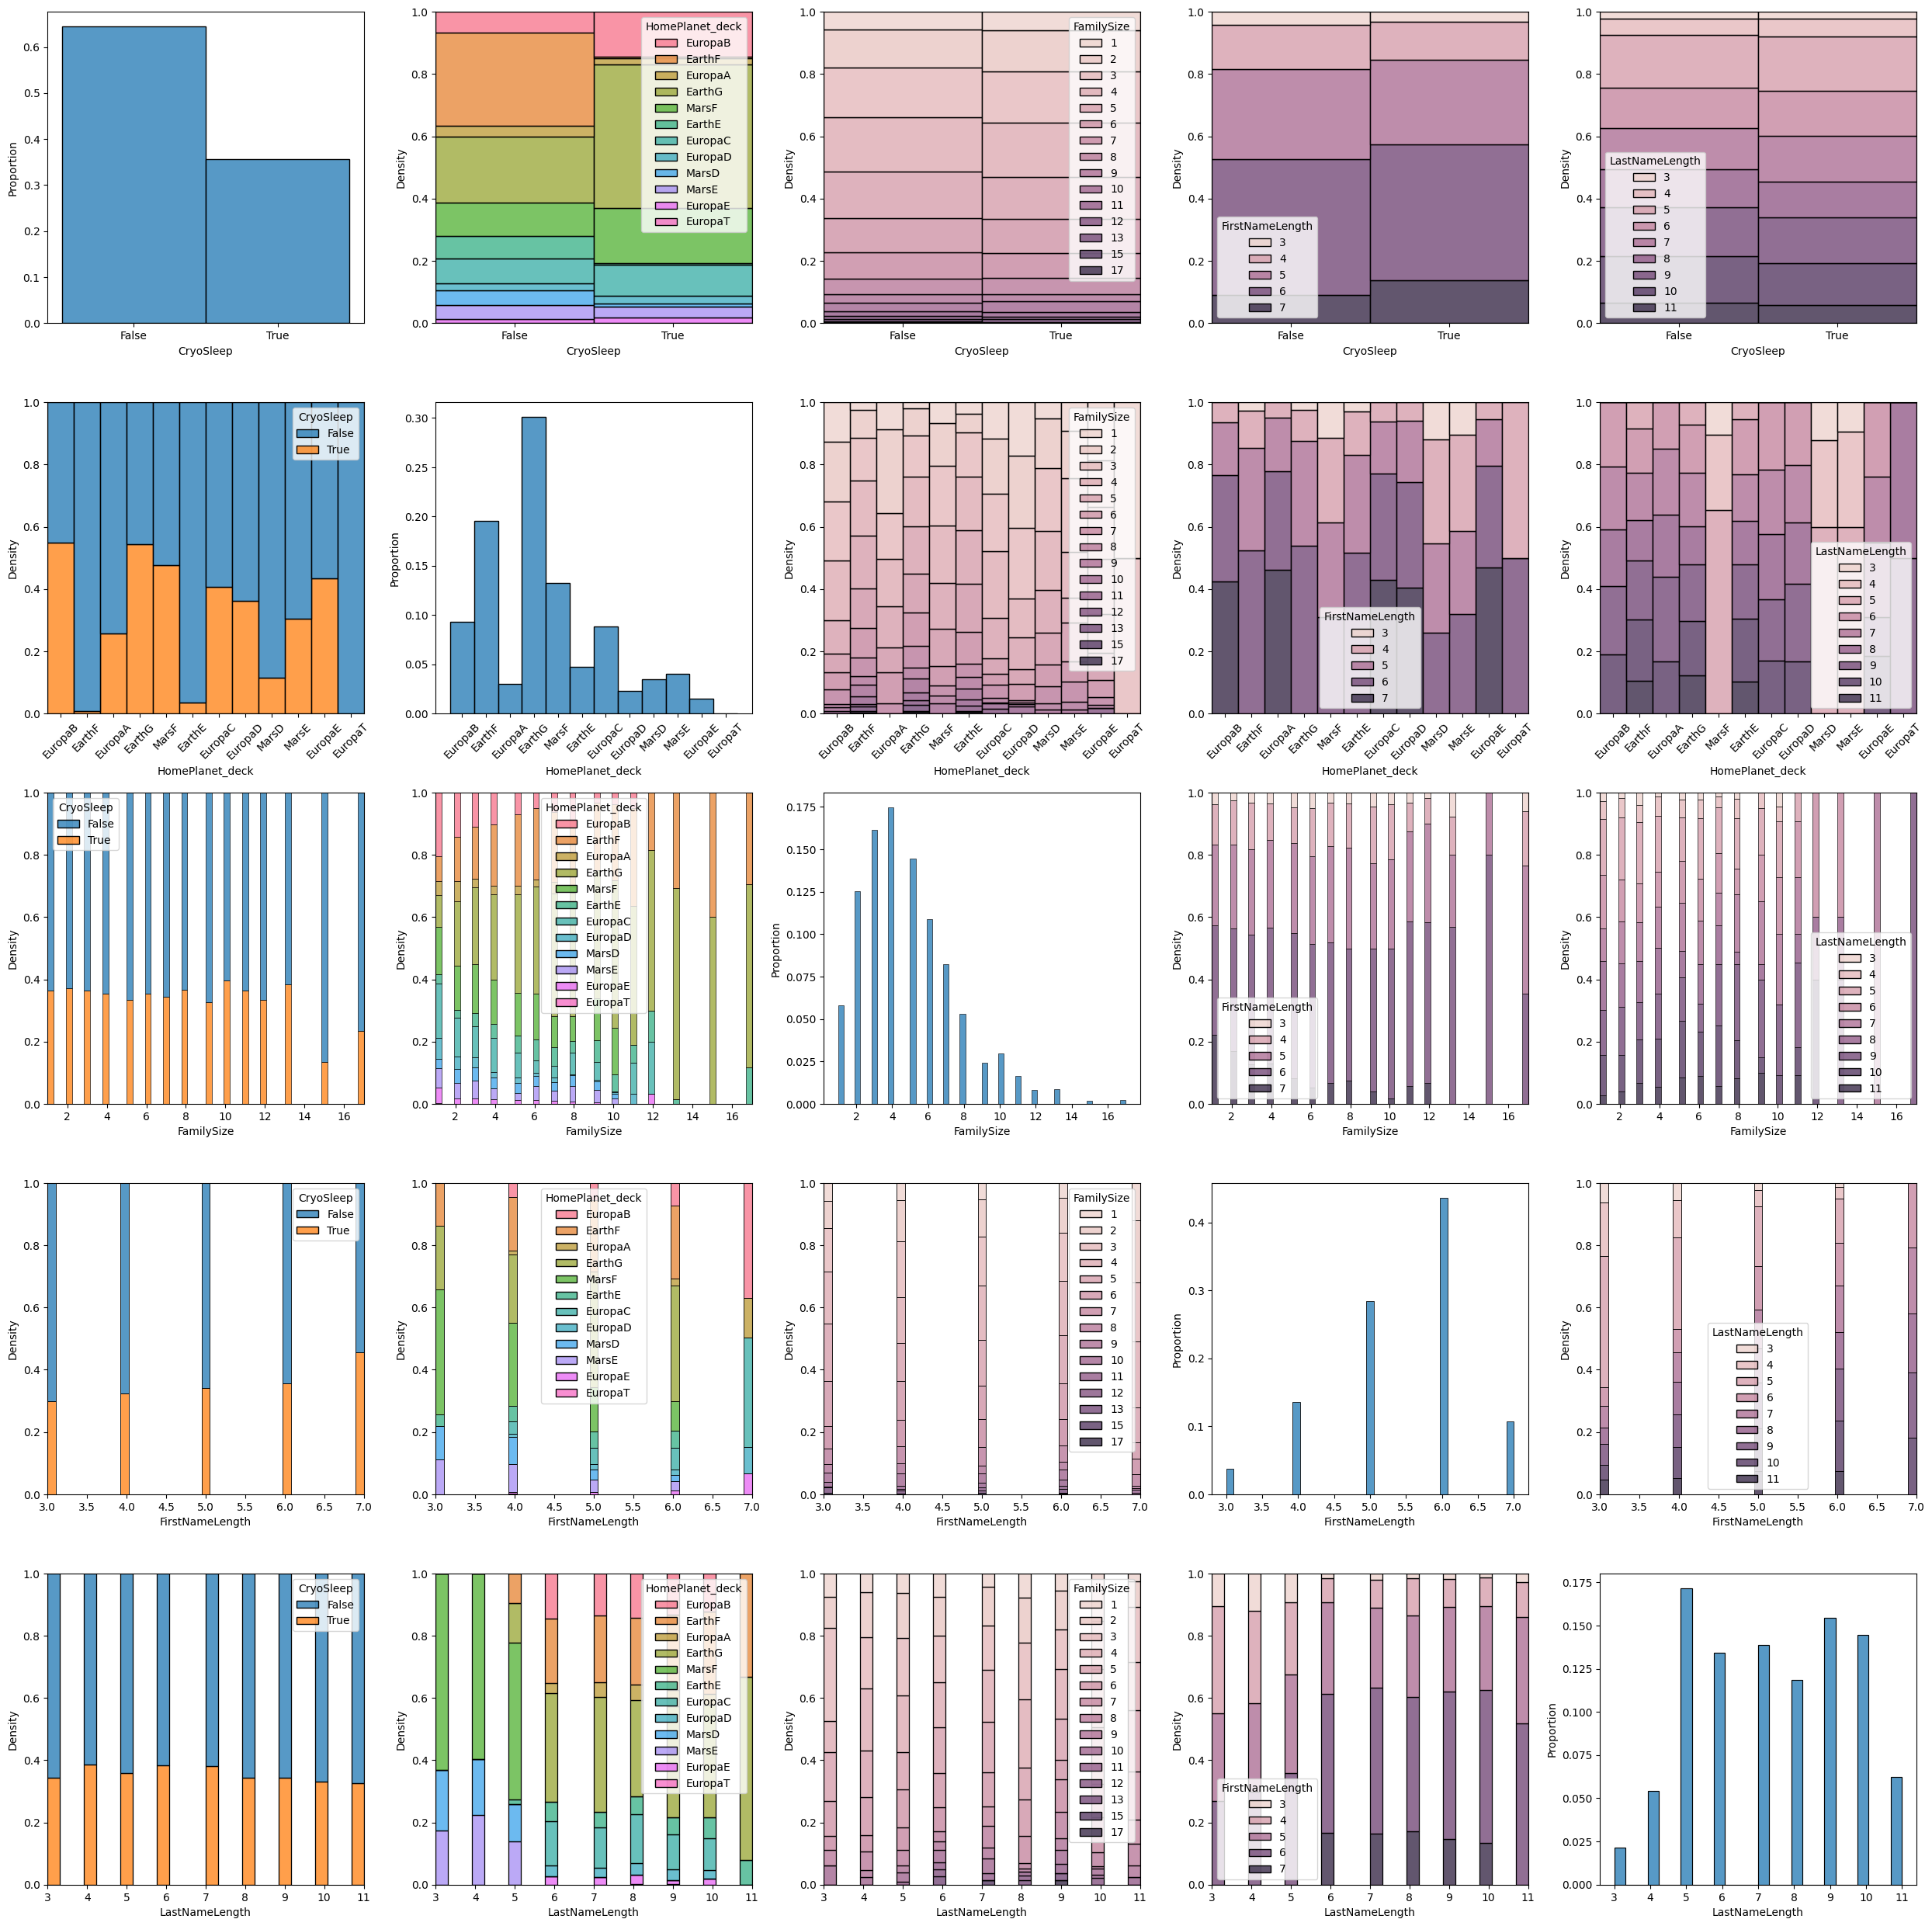

In [77]:
Gridplot_Hists(df5, ['CryoSleep', 'HomePlanet_deck', 'FamilySize', 'FirstNameLength', 'LastNameLength'])

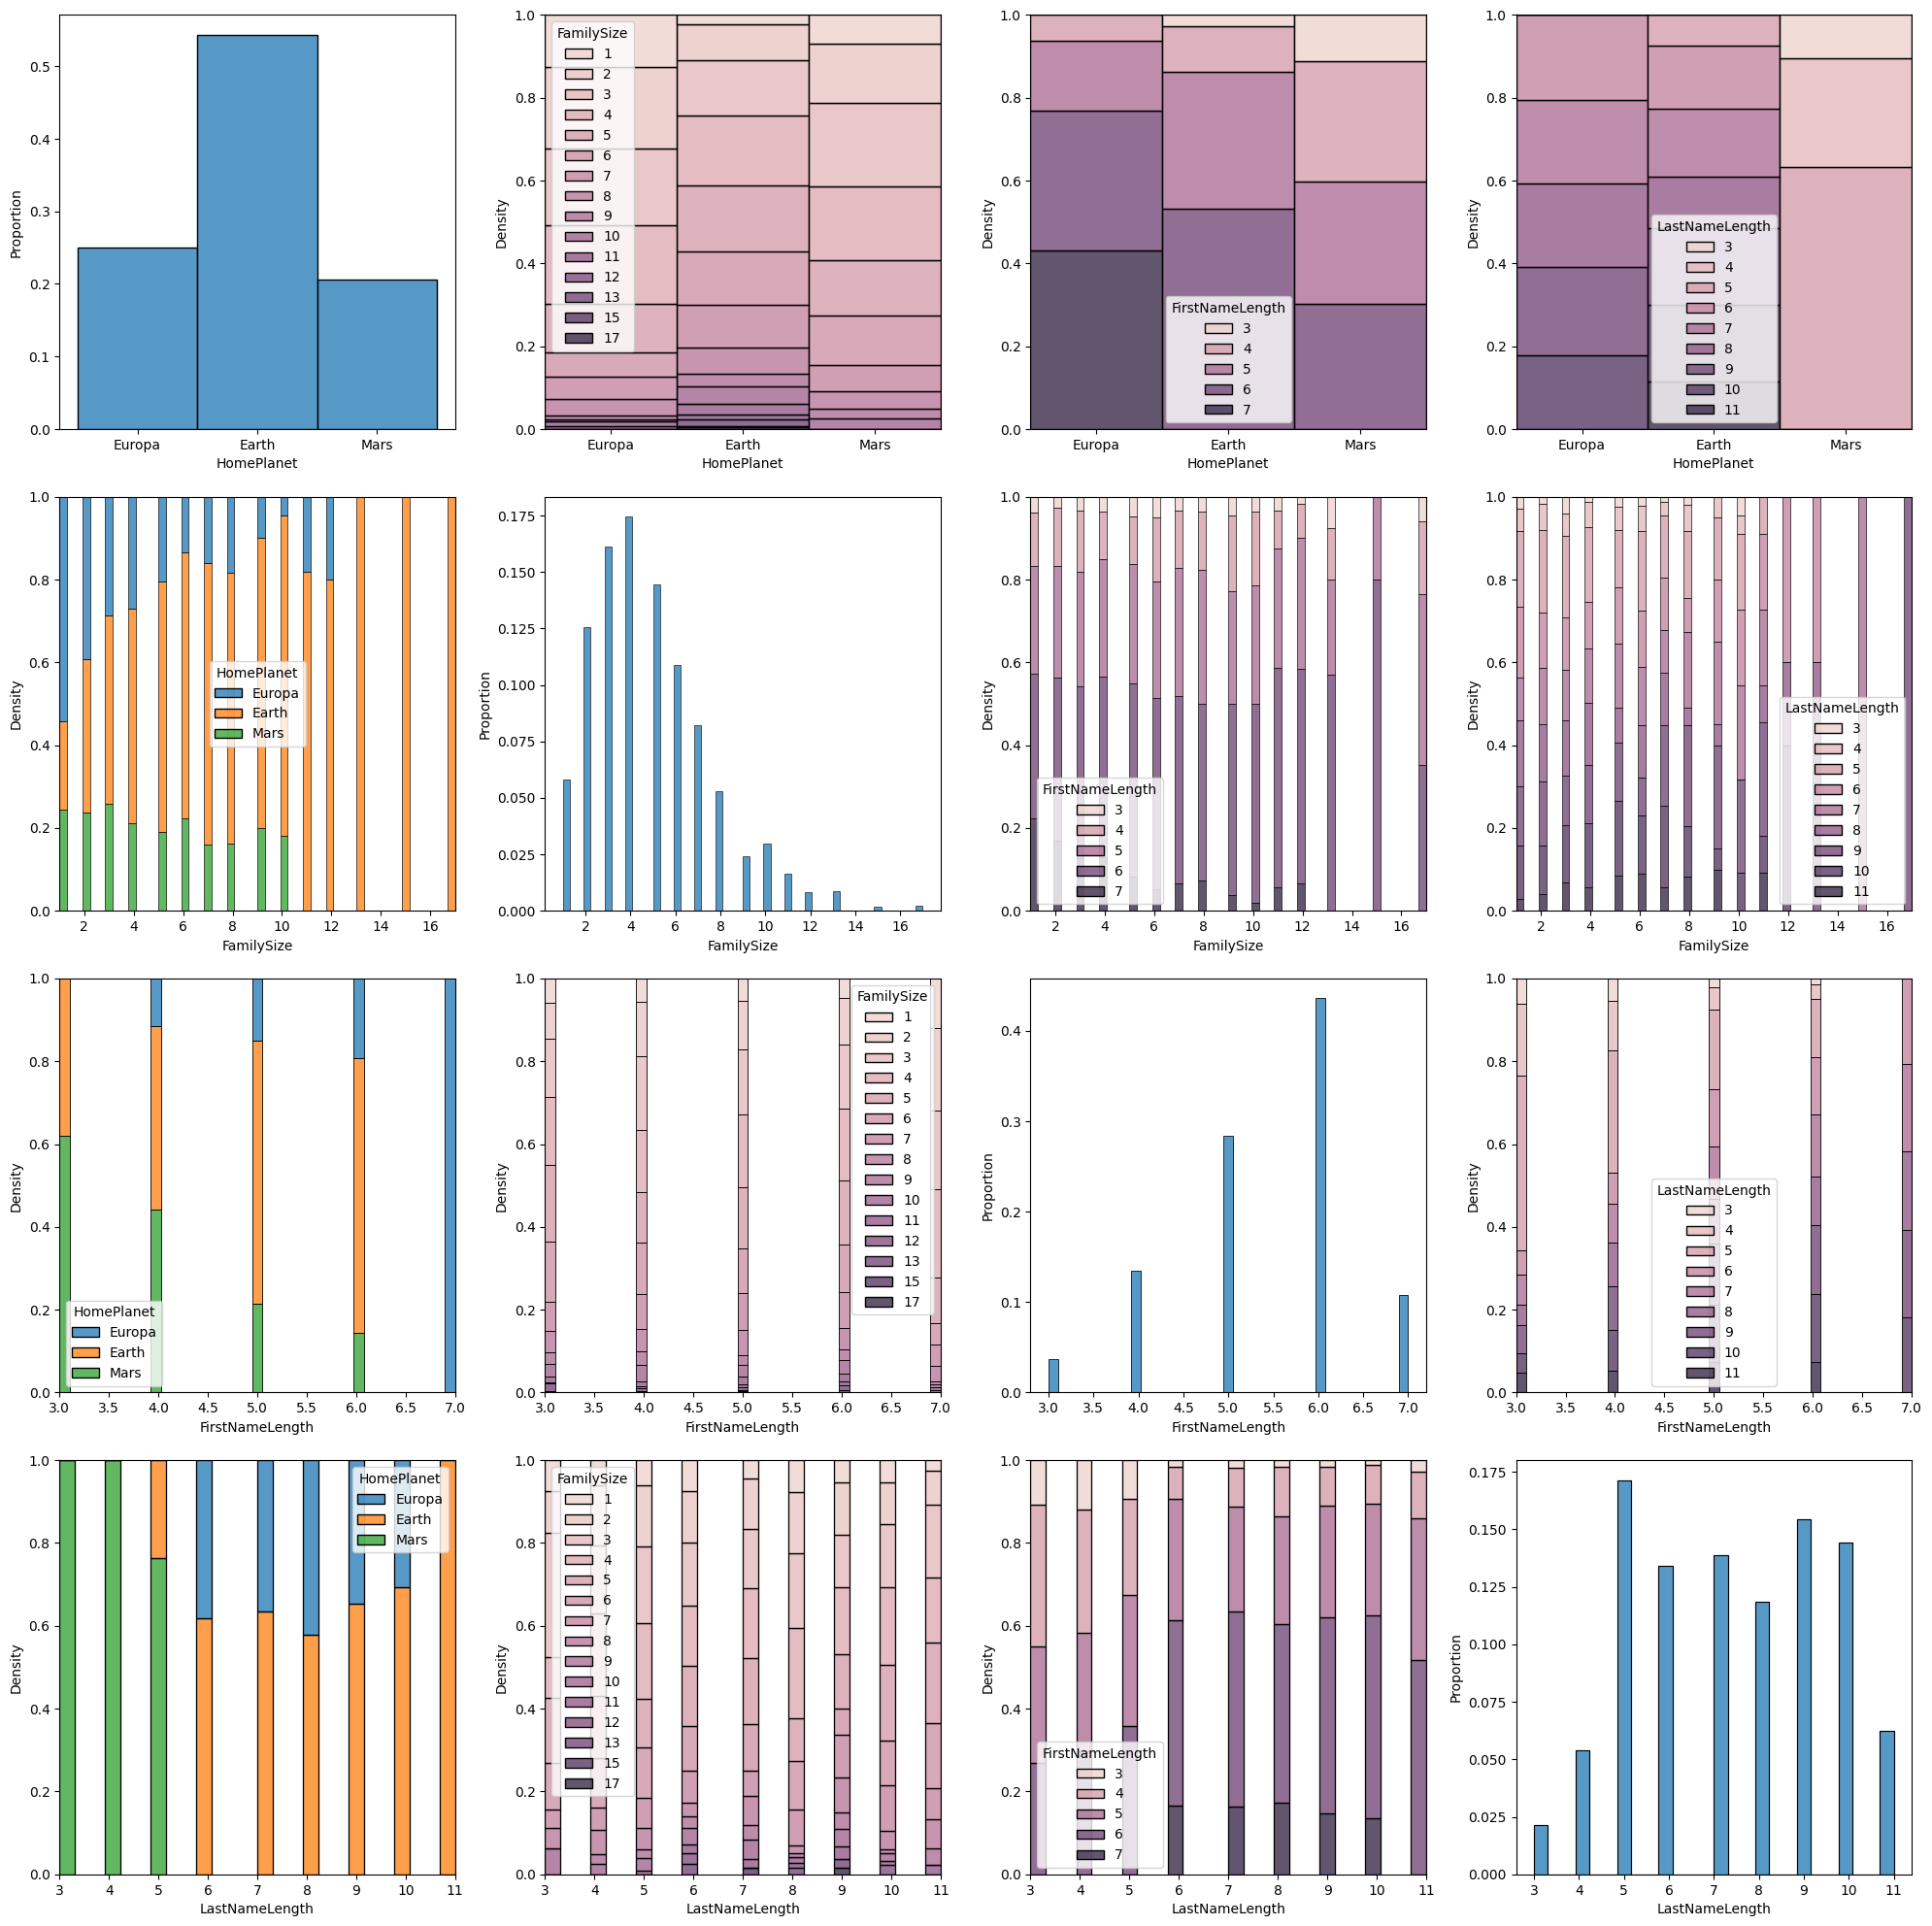

In [78]:
Gridplot_Hists(df5, ['HomePlanet', 'FamilySize', 'FirstNameLength', 'LastNameLength'])

* Passengers with FamilySize > 12 are all from Earth
* No passenger with FamilySize > 10 is from Mars
* Solo passengers are more likely to be from Europa
* Passengers from Europa tend to have longer First Names while passengers from Mars tend to have shorter ones
* Passengers with FirstNameLength > 6 are all from Europa
* No passenger with FirstNameLength < 4 is from Europa
* All passengers with LastNameLength > 10 are from Earth
* No passenger with LastNameLength < 6 or > 10 is from Europa
* All passengers with LastNameLength < 5 are from Mars

In [79]:
df5.groupby('Last Name').HomePlanet.nunique().max()

np.int64(1)

In [80]:
df5.groupby('Last Name').deck.nunique().max()

np.int64(4)

* Passengers with the same Family Name are from the same HomePlanet but not necessarily same deck

In [81]:
df6 = Extract_PassengerId_Info(df5)
df6

,PassengerId,HomePlanet,Destination,CryoSleep,VIP,Age_Bin,deck,First Name,Last Name,Transported,...,FamilySize,FirstNameLength,LastNameLength,GroupId,ppId,GroupSize,G1,G2,G3,G4
0,0001_01,Europa,TRAPPIST-1e,False,False,9,B,Maham,Ofracculy,False,...,1,5,9,0001,1,1,0,0,0,1
1,0002_01,Earth,TRAPPIST-1e,False,False,5,F,Juanna,Vines,True,...,3,6,5,0002,1,1,0,0,0,2
2,0003_01,Europa,TRAPPIST-1e,False,True,11,A,Altark,Susent,False,...,6,6,6,0003,1,2,0,0,0,3
3,0003_02,Europa,TRAPPIST-1e,False,False,8,A,Solam,Susent,False,...,6,5,6,0003,2,2,0,0,0,3
4,0004_01,Earth,TRAPPIST-1e,False,False,2,F,Willy,Santantines,True,...,6,5,11,0004,1,1,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,55 Cancri e,False,True,9,A,Gravior,Noxnuther,False,...,2,7,9,9276,1,1,9,2,7,6
8689,9278_01,Earth,PSO J318.5-22,True,False,2,G,Kurta,Mondalley,False,...,2,5,9,9278,1,1,9,2,7,8
8690,9279_01,Earth,TRAPPIST-1e,False,False,6,G,Fayey,Connon,True,...,5,5,6,9279,1,1,9,2,7,9
8691,9280_01,Europa,55 Cancri e,False,False,7,E,Celeon,Hontichre,False,...,4,6,9,9280,1,2,9,2,8,0


In [82]:
df6.groupby('GroupId').HomePlanet.nunique().max()

np.int64(1)

In [83]:
df6.groupby('GroupId').deck.nunique().max()

np.int64(3)

In [84]:
df6.groupby('GroupId')['Last Name'].nunique().max()

np.int64(3)

In [85]:
df6.groupby('GroupId').Destination.nunique().max()

np.int64(3)

* Passengers with the same GroupId are from the same HomePlanet but not necessarily on the same deck, Destination, or Last Name